# Developing and Evaluating a Price-Prediction Model — Toyota Corolla

**Course:** Data Analysis with Statistical Software · Dr. Orit Rafaeli 

**Final project** · `Toyota_Corolla_cars.xlsx` (1,436 used cars × 39 columns; target `Price` in €).· 

**Submit:** Itamar Hoshen,  Elad Maisi,  Ariel Koritcher ·   

## Framing

**The question is predictive:** out-of-sample RMSE in euros, not training R² or coefficient significance. Interpretability enters only as a pre-declared tie-breaker.

**From the midterm EDA:** right-skewed prices; near-linear price–age; curved price–mileage (a line captures 32% of the variation, a LOWESS smoother 44%); an age × mileage interaction; non-normal, heteroskedastic residuals; the ordering Age → KM → Price.

**Three rules.** (1) Metric, protocol and tie-breaker fixed in 1.8, **before any model is fitted**. (2) The holdout opens once. (3) Every diagnostic ends in an action.

**Order.** The notebook does not run in the order of the assignment. Diagnosis precedes regularisation, because a penalty belongs on the *final* design matrix — so §2.5 sits physically after §3.8, once the specification it penalises exists. Section numbers, not physical position, map to the assignment: **1.x = Part A · 2.x = Part B · 3.x = Part C · 4.x = Part D**.

**Part D.** The last section changes the question: not what price to predict, but what one vehicle characteristic *causes* the price to be — and why nothing here, including the preferred model, licenses that claim.

### Environment and helper functions

Libraries, error metrics in euros, a Holm wrapper and a table printer. One seed (`SEED = 2026`) governs the split, the folds and every bootstrap.

In [151]:
import warnings, re, hashlib, json, time, itertools
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import scipy.stats as st
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset, het_breuschpagan, lilliefors, acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence
from statsmodels.stats.multitest import multipletests
from statsmodels.regression.quantile_regression import QuantReg
from sklearn.model_selection import train_test_split, RepeatedKFold, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LassoCV, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3, "axes.titlesize": 11})
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 60); pd.set_option("display.max_rows", 120); pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

SEED = 2026
DATA_PATH = "Toyota_Corolla_cars.xlsx"

def rmse(a, b): return float(np.sqrt(np.mean((np.asarray(a, float) - np.asarray(b, float)) ** 2)))
def mae(a, b):  return float(np.mean(np.abs(np.asarray(a, float) - np.asarray(b, float))))
def mape(a, b): a = np.asarray(a, float); return float(100 * np.mean(np.abs((a - np.asarray(b, float)) / a)))
def me(a, b):   return float(np.mean(np.asarray(a, float) - np.asarray(b, float)))
def holm(pvals): return multipletests(pvals, method="holm")[1]
def add_const(X): return sm.add_constant(X, has_constant="add")
def show(df, title=None):
    if title: print(title)
    display(df)
print("numpy", np.__version__, "| pandas", pd.__version__, "| statsmodels", sm.__version__)

numpy 2.1.3 | pandas 2.2.3 | statsmodels 0.14.6


Depends only on the raw Excel file — no intermediate files, so the notebook re-runs end to end. `has_constant="add"`: inside a fold a rare dummy can become all-zero, and statsmodels would otherwise skip the intercept.

## Part A — Data preparation, split and pre-registration

This stage produces the three things every later stage consumes: **one** design matrix,
**one** train/holdout split, and a decision log. The evaluation protocol is locked at the
end of the stage, before any model is fitted.

### 1.1 Loading and quality audit

Four checks are run before anything is changed — missing values, duplicate records, columns
with no variation, and one suspected identity among the date columns:

$$\text{Age\_08\_04} = 12\,(2004 - \text{Mfg\_Year}) + (9 - \text{Mfg\_Month})$$

If that identity holds exactly, the three columns are linearly dependent, and keeping all of
them would leave the design matrix rank-deficient.

In [152]:
raw = pd.read_excel(DATA_PATH)
raw.columns = [c.strip() for c in raw.columns]
print("shape:", raw.shape, "| missing cells:", int(raw.isna().sum().sum()), "| duplicate rows:", int(raw.duplicated().sum()), "| duplicate Id:", int(raw.Id.duplicated().sum()))
# degenerate columns: share of the most frequent value
dom = raw.drop(columns=["Id", "Model"]).apply(lambda s: s.value_counts(normalize=True).iloc[0])
show(dom[dom > 0.97].sort_values(ascending=False).to_frame("share of dominant value"), "Columns dominated by a single value (>97%):")
# exact identity between Age and manufacturing date
age_calc = 12 * (2004 - raw.Mfg_Year) + (9 - raw.Mfg_Month)
aux = sm.OLS(raw.Age_08_04, add_const(raw[["Mfg_Year", "Mfg_Month"]])).fit()
print(f"Age identity 12*(2004-Year)+(9-Month): exact matches = {(age_calc == raw.Age_08_04).mean():.1%} | auxiliary regression R² = {aux.rsquared:.6f}")
show(raw[["Price", "Age_08_04", "KM", "HP", "CC", "Weight", "Quarterly_Tax"]].describe().T.round(1), "Key numeric columns:")
print("Fuel_Type:", raw.Fuel_Type.value_counts().to_dict()); print("Color:", raw.Color.value_counts().to_dict())

shape: (1436, 39) | missing cells: 0 | duplicate rows: 0 | duplicate Id: 0
Columns dominated by a single value (>97%):


,share of dominant value
Cylinders,1.000
Parking_Assistant,0.997
Power_Steering,0.978
Airbag_1,0.971


Age identity 12*(2004-Year)+(9-Month): exact matches = 100.0% | auxiliary regression R² = 1.000000
Key numeric columns:


,count,mean,std,min,25%,50%,75%,max
Price,"1,436.000","10,730.800","3,627.000","4,350.000","8,450.000","9,900.000","11,950.000","32,500.000"
Age_08_04,"1,436.000",55.900,18.600,1.000,44.000,61.000,70.000,80.000
KM,"1,436.000","68,533.300","37,506.400",1.000,"43,000.000","63,389.500","87,020.800","243,000.000"
HP,"1,436.000",101.500,15.000,69.000,90.000,110.000,110.000,192.000
CC,"1,436.000","1,576.900",424.400,"1,300.000","1,400.000","1,600.000","1,600.000","16,000.000"
Weight,"1,436.000","1,072.500",52.600,"1,000.000","1,040.000","1,070.000","1,085.000","1,615.000"
Quarterly_Tax,"1,436.000",87.100,41.100,19.000,69.000,85.000,85.000,283.000


Fuel_Type: {'Petrol': 1264, 'Diesel': 155, 'CNG': 17}
Color: {'Grey': 301, 'Blue': 283, 'Red': 278, 'Green': 220, 'Black': 191, 'Silver': 122, 'White': 31, 'Violet': 4, 'Yellow': 3, 'Beige': 3}


**Finding.** The file is clean: no missing cells, no duplicate rows, no duplicate `Id`. The age
identity holds on 100% of rows (auxiliary R² = 1.000000). Two columns carry no usable variation —
`Cylinders` is 4 for every car, and `Parking_Assistant` is 1 for only 4 cars out of 1,436.
`Airbag_1` and `Power_Steering` are close to constant but remain estimable.

The audit also surfaces four issues handled further on: `CC` = 16,000 and `Weight` = 1,615 kg are
data-entry errors (§1.2, §1.3), while `Fuel_Type` has a 17-car CNG group and `Color` three colours
with 3–4 cars each (§1.5).

**Action.** `Mfg_Year` and `Mfg_Month` are dropped for exact linear dependence, `Cylinders` and
`Parking_Assistant` for lack of variation. `Airbag_1` and `Power_Steering` stay.

### 1.2 Decisions carried over from the midterm

Four decisions were taken in the EDA assignment and are applied here unchanged.

- **Verso (5 rows) — excluded.** A 7-seat MPV on the Corolla platform: 2.0 D4D, 1,320–1,480 kg
  against a Corolla median of 1,067 kg, prices up to 32,500 €. This is a *population definition*,
  not outlier removal: five cars cannot support their own depreciation curve, and pooling them
  distorts the `Weight` coefficient for the other 1,431. A copy is kept for the sensitivity
  check in §3.14.
- **`CC` = 16,000 (Id 81) → 1,600.** The `Model` string reads "1.6", so the correct value is
  recoverable from the record itself.
- **`KM` ≤ 1 on cars older than 24 months (2 rows) — flagged, not deleted.** Implausible, but
  nothing in the record proves it wrong.
- **Prices above the IQR fence — kept.** Statistically extreme, economically ordinary.

In [153]:
df = raw.copy()
df["Model"] = df.Model.astype(str)
is_verso = df.Model.str.upper().str.contains("VERSO")
verso = df[is_verso].copy()
show(verso[["Id", "Model", "Price", "Age_08_04", "KM", "Weight", "CC", "HP", "Quarterly_Tax"]], "Verso rows (excluded as a different vehicle type):")
df = df[~is_verso].copy()
show(df.loc[df.CC == 16000, ["Id", "Model", "CC", "HP", "Quarterly_Tax"]], "CC typo:")
df.loc[df.CC == 16000, "CC"] = 1600
df["km_suspect"] = ((df.KM <= 1) & (df.Age_08_04 > 24)).astype(int)
show(df.loc[df.km_suspect == 1, ["Id", "Model", "Age_08_04", "KM", "Price"]], "KM ≤ 1 on cars older than 24 months (flagged, kept):")
q1, q3 = df.Price.quantile([0.25, 0.75]); fence = q3 + 1.5 * (q3 - q1)
hi = df[df.Price > fence]
print(f"High-price cars above the IQR fence ({fence:,.0f} €): n = {len(hi)} ({len(hi)/len(df):.1%}); their median age = {hi.Age_08_04.median():.0f} months vs {df.Age_08_04.median():.0f} overall; median KM = {hi.KM.median():,.0f} vs {df.KM.median():,.0f}. Kept.")
print("Rows after 1.2:", len(df))

Verso rows (excluded as a different vehicle type):


,Id,Model,Price,Age_08_04,KM,Weight,CC,HP,Quarterly_Tax
109,111,TOYOTA Corolla VERSO 2.0 D4D SOL (7) BNS MPV,32500,4,1,1480,2000,116,283
110,112,TOYOTA Corolla VERSO 2.0 D4D SOL (7) MPV,31000,4,4000,1480,2000,116,283
111,113,TOYOTA Corolla VERSO 2.0 D4D SOL (7) MPV,31275,4,1500,1480,2000,116,283
112,114,TOYOTA Corolla VERSO 2.0 D4D LINEA SOL MPV,24950,8,13253,1320,2000,116,234
113,115,TOYOTA Corolla VERSO 2.0 D4D LINEA SOL MPV,24950,8,13253,1320,2000,116,234


CC typo:


,Id,Model,CC,HP,Quarterly_Tax
80,81,TOYOTA Corolla 1.6 5drs 1 4/5-Doors,16000,110,100


KM ≤ 1 on cars older than 24 months (flagged, kept):


,Id,Model,Age_08_04,KM,Price
601,605,TOYOTA Corolla 2.0 d HB Diesel 2/3-Doors,50,1,7500
1435,1442,TOYOTA Corolla 1.6 LB LINEA TERRA 4/5-Doors,76,1,6950


High-price cars above the IQR fence (17,175 €): n = 106 (7.4%); their median age = 17 months vs 61 overall; median KM = 19,994 vs 63,500. Kept.
Rows after 1.2: 1431


**Finding.** 1,431 cars remain. Two report KM ≤ 1 at ages of 50 and 76 months (Ids 605, 1442).
The 106 cars above the price fence (7.4%) are young and low-mileage: median age 17 months against
61 overall, median 20,000 km against 63,500.

**Action.** The two KM records are flagged and kept. The high-price cars stay as well — they are
exactly the profile a price model must get right, and removing them would bias predictions where
it matters most. The same record-level logic is now applied to `Weight`.

### 1.3 Record audit of `Weight`

Across the remaining 1,431 cars `Weight` averages 1,071 kg with an SD of 48 kg, yet one record
reports 1,615 kg. Comparing a car against the whole fleet would be misleading — a wagon is
legitimately heavier than a hatchback — so the audit runs *within specification*.

**Rule, fixed before the result was inspected:** among cars sharing
(`HP`, `CC`, `Fuel_Type`, `Doors`, `Automatic`), a weight more than **5 SD** from the sub-group
mean is treated as a suspected entry error.

Two limits of the rule are worth stating. The z-score uses the sub-group's own mean and SD, so a
genuine error inflates that SD and shrinks its own score — the rule is conservative and cannot
manufacture suspects. And 16 cars sit in specification groups of one, where no SD exists; they are
unauditable here and are kept.

Unlike the `CC` typo there is no value to correct *to*, so suspects are excluded rather than
repaired, and re-introduced as a ensitivity check in §3.14.

In [154]:
keys = ["HP", "CC", "Fuel_Type", "Doors", "Automatic"]
g = df.groupby(keys).Weight
df["weight_z"] = (df.Weight - g.transform("mean")) / g.transform("std")
aud = df.assign(group_n=g.transform("size"), group_mean=g.transform("mean").round(0), group_sd=g.transform("std").round(1))
show(aud.sort_values("weight_z", ascending=False).head(6)[["Id", "Model", "Weight", "weight_z", "group_n", "group_mean", "group_sd", "HP", "CC", "Quarterly_Tax", "Price"]].round(2), "Largest within-specification weight deviations:")
df["weight_suspect"] = (df.weight_z > 5).astype(int)
weight_suspects = df[df.weight_suspect == 1].copy()
print("Rows flagged by the >5 SD rule:", weight_suspects.Id.tolist())
df = df[df.weight_suspect == 0].drop(columns=["weight_z"]).copy()
print("Rows after 1.3:", len(df))

Largest within-specification weight deviations:


,Id,Model,Weight,weight_z,group_n,group_mean,group_sd,HP,CC,Quarterly_Tax,Price
221,223,TOYOTA Corolla 1.6 HB LINEA SOL 4/5-Doors,1615,16.750,406,"1,082.000",31.800,110,1600,163,12450
960,964,TOYOTA Corolla,1480,11.510,137,"1,020.000",40.000,86,1300,19,9390
944,948,TOYOTA Corolla 2/3-Doors,1135,4.480,281,"1,056.000",17.600,110,1600,19,10250
1044,1049,TOYOTA Corolla 2.0 DSL WAGON LINEA TERRA COMM ...,1172,4.150,31,"1,139.000",8.000,72,2000,40,5900
94,95,TOYOTA Corolla 1.6 16v VVT-i Linea Sol 2/3-Doors,1120,3.630,281,"1,056.000",17.600,110,1600,85,18900
100,101,TOYOTA Corolla 1.6 16V VVT I 3DR SOL 2/3-Doors,1120,3.630,281,"1,056.000",17.600,110,1600,85,18990


Rows flagged by the >5 SD rule: [223, 964]
Rows after 1.3: 1429


**Finding.** Exactly two records break the rule, both by a wide margin.

- **Id 223** — 1,615 kg for a 1.6 hatchback whose 406-car specification group averages
  1,082 ± 32 kg (z = 16.8).
- **Id 964** — 1,480 kg for a 1.3 / 86 hp car in the lowest tax band (z = 11.5). 1,480 kg is
  exactly the Verso weight, which suggests the value was copied from a neighbouring row.

The next-largest deviation is 4.5 SD, so no third record comes near the threshold: the cut does
not depend on where between 5 and 10 SD it is placed.

**Action.** Both records are set aside; n = 1,429.

### 1.4 Extracting trim level and body type from `Model`

`Model` is a free-text string, unusable as a predictor in its raw form, but most entries carry two
tokens worth recovering: a trim level (`TERRA`, `LUNA`, `SOL`, sometimes preceded by `LINEA`) and a
body type written in several spellings. Extracting them is the domain-knowledge step Part A calls for.

**Rules.** `Trim` is the trim token found in the string; `LINEA` is a marketing prefix, not a level,
and is ignored. `Body` maps the body token through an alias table (`HB`, `HATCHB`, `HATCHBACK` all
become Hatchback). Where no token is present, the level is `Unknown` — an explicit category, not a
missing value.

Both new variables are then checked against the equipment rates and prices they are supposed to
track, before either is allowed into the model.

In [155]:
def clean_model(s): return re.sub(r"[^A-Z0-9 .\-]", " ", str(s).upper())
tokens = pd.Series([t for s in df.Model.map(clean_model) for t in s.split() if t])
tc = tokens.value_counts()
print("Trim-related tokens:", {k: int(tc.get(k, 0)) for k in ["TERRA", "LUNA", "SOL", "LINEA"]})
print("Body-related tokens:", {k: int(tc.get(k, 0)) for k in ["HATCHB", "HATCHBACK", "HB", "LIFTB", "LIFTBACK", "LB", "SEDAN", "SDN", "WAGON", "WGN", "STATIONWAGEN"]})
print("Other frequent tokens:", {k: int(tc.get(k, 0)) for k in ["VVT", "VVTI", "VVT-I", "G6", "COMFORT", "D4D", "AUT3", "AUT4", "16V", "5DR", "3DR"]})
TRIM_RE = re.compile(r"\b(TERRA|LUNA|SOL)\b")
BODY_MAP = {"HATCHB": "Hatchback", "HATCHBACK": "Hatchback", "HB": "Hatchback", "LIFTB": "Liftback", "LIFTBACK": "Liftback", "LB": "Liftback",
            "SEDAN": "Sedan", "SDN": "Sedan", "WAGON": "Wagon", "WGN": "Wagon", "STATIONWAGEN": "Wagon"}
BODY_RE = re.compile(r"\b(" + "|".join(BODY_MAP) + r")\b")
def extract_trim(s):
    m = TRIM_RE.findall(clean_model(s)); return m[-1] if m else "Unknown"
def extract_body(s):
    m = BODY_RE.findall(clean_model(s)); return BODY_MAP[m[0]] if m else "Unknown"
n_multi = df.Model.map(lambda s: len(TRIM_RE.findall(clean_model(s)))).gt(1).sum()
df["Trim"] = df.Model.map(extract_trim); df["Body"] = df.Model.map(extract_body)
print("records with more than one trim token:", int(n_multi))
print("Trim counts:", df.Trim.value_counts().to_dict()); print("Body counts:", df.Body.value_counts().to_dict())
val = df.groupby("Trim").agg(n=("Price", "size"), median_price=("Price", "median"), airco_rate=("Airco", "mean"), auto_airco_rate=("Automatic_airco", "mean"), median_age=("Age_08_04", "median")).loc[["TERRA", "LUNA", "SOL", "Unknown"]]
show(val.round(2), "Validity check of the trim hierarchy:")
show(df.groupby("Body").agg(n=("Price", "size"), median_price=("Price", "median"), median_age=("Age_08_04", "median"), median_doors=("Doors", "median")).round(1), "Body levels:")
show(pd.crosstab(df.Trim, df.Body), "Trim × Body:")
# tokens that duplicate existing variables (documented, not used)
for tok, var in [("D4D", "Fuel_Type"), ("AUT4", "Automatic"), ("AUT3", "Automatic")]:
    m = df.Model.map(clean_model).str.contains(r"\b" + tok + r"\b")
    print(f"token {tok}: n={int(m.sum())}, {var} distribution among them: {df.loc[m, var].value_counts().to_dict()}  -> duplicates {var}, not used")

Trim-related tokens: {'TERRA': 893, 'LUNA': 218, 'SOL': 142, 'LINEA': 791}
Body-related tokens: {'HATCHB': 479, 'HATCHBACK': 7, 'HB': 42, 'LIFTB': 381, 'LIFTBACK': 38, 'LB': 35, 'SEDAN': 118, 'SDN': 10, 'WAGON': 72, 'WGN': 4, 'STATIONWAGEN': 82}
Other frequent tokens: {'VVT': 409, 'VVTI': 25, 'VVT-I': 23, 'G6': 73, 'COMFORT': 69, 'D4D': 33, 'AUT3': 19, 'AUT4': 44, '16V': 1083, '5DR': 88, '3DR': 49}
records with more than one trim token: 0
Trim counts: {'TERRA': 896, 'LUNA': 218, 'Unknown': 172, 'SOL': 143}
Body counts: {'Hatchback': 528, 'Liftback': 450, 'Unknown': 240, 'Sedan': 128, 'Wagon': 83}
Validity check of the trim hierarchy:


,n,median_price,airco_rate,auto_airco_rate,median_age
Trim,,,,,
TERRA,896,"9,000.000",0.320,0.000,63.000
LUNA,218,"9,900.000",0.830,0.020,63.000
SOL,143,"13,500.000",1.000,0.380,40.000
Unknown,172,"10,350.000",0.640,0.090,58.000


Body levels:


,n,median_price,median_age,median_doors
Body,,,,
Hatchback,528,"8,950.000",64.000,3.000
Liftback,450,"9,950.000",60.000,5.000
Sedan,128,"8,950.000",65.000,4.000
Unknown,240,"16,450.000",26.500,5.000
Wagon,83,"9,895.000",64.000,5.000


Trim × Body:


Body,Hatchback,Liftback,Sedan,Unknown,Wagon
Trim,,,,,
LUNA,43,147,4,15,9
SOL,27,48,10,56,2
TERRA,356,238,111,126,65
Unknown,102,17,3,43,7


token D4D: n=33, Fuel_Type distribution among them: {'Diesel': 33}  -> duplicates Fuel_Type, not used
token AUT4: n=44, Automatic distribution among them: {1: 44}  -> duplicates Automatic, not used
token AUT3: n=19, Automatic distribution among them: {1: 19}  -> duplicates Automatic, not used


**Finding.** No record carries two trim tokens, so the extraction is unambiguous. The assumed
ordering TERRA < LUNA < SOL is not an assumption — it is visible in three independent variables:

| Trim | n | Air-conditioning | Automatic a/c | Median price |
|---|---|---|---|---|
| TERRA | 896 | 32% | 0.2% | 9,000 € |
| LUNA | 218 | 84% | 1.8% | 9,900 € |
| SOL | 143 | 100% | 38.5% | 13,500 € |
| Unknown | 172 | 64% | 8.7% | 10,350 € |

`LINEA` appears alongside all three levels, confirming it is a prefix rather than a trim of its own.

**Action.** Both variables enter the model with `Unknown` retained as a level. Keeping it is
deliberate: the 172 unlabelled cars (older G6/S/GTSi models) sit between LUNA and SOL on every
column above, so they are a real segment, not a residual bin. The same holds for the 240 cars with
`Unknown` body — the newer 5DR/3DR VVT-i generation, whose model strings simply omit the token.

Three tokens are documented but **not** used: `D4D` reproduces `Fuel_Type` exactly, and
`AUT3` / `AUT4` reproduce `Automatic`. Adding them would duplicate information already in the matrix.

### 1.5 Categorical variables and the redundant `Radio` pair

Three encoding decisions, each with its own logic.

- **`Fuel_Type` — base level Petrol** (the most frequent level, which gives the most stable
  contrasts). CNG has only 17 cars. Whether to merge it with Diesel is *not* decided here: a
  marginal `Price ~ Fuel_Type` test would confound fuel with weight, tax and engine size, so the
  question is settled later by an F-test nested inside the full model.
- **`Color` — Violet, Yellow and Beige (3–4 cars each) merged into `Other`.** White is kept
  separate despite having only 31 cars. The criterion is estimability, not similarity of medians:
  31 observations support a coefficient, 4 do not. Base level = Grey.
- **`Radio` and `Radio_cassette`** correlate at roughly 0.99 — the same equipment recorded twice.

In [156]:
show(pd.crosstab(df.Radio, df.Radio_cassette, margins=True), "Radio × Radio_cassette:")
print(f"r(Radio, Radio_cassette) = {df.Radio.corr(df.Radio_cassette):.3f}; disagreeing rows = {int((df.Radio != df.Radio_cassette).sum())} of {len(df)}")
df["Color"] = df.Color.replace({"Violet": "Other", "Yellow": "Other", "Beige": "Other"})
print("Color levels:", df.Color.value_counts().to_dict())
print("Fuel levels:", df.Fuel_Type.value_counts().to_dict())
# Two kinds of columns are never predictors:
#  (1) bookkeeping columns that exist only to identify rows, hold the target, or record data-prep / split decisions;
#  (2) predictors dropped for statistical reasons (constant, identity with Age, duplicate of another column).
NON_FEATURE = ["Id", "Model", "Price", "split", "km_suspect", "weight_suspect"]      # incl. the train/holdout indicator created in 1.6
DROP_PRED   = ["Cylinders", "Parking_Assistant", "Mfg_Year", "Mfg_Month", "Radio"]
DROP = NON_FEATURE + DROP_PRED
CAT_BASE = {"Fuel_Type": "Petrol", "Color": "Grey", "Trim": "TERRA", "Body": "Hatchback"}
def design(d):
    """Base design matrix: all retained predictors, one-hot with an explicit base level (drop_first).
    Only genuine features may reach get_dummies: bookkeeping and dropped columns are removed first, and any
    remaining non-numeric column that is not a declared categorical raises a clear error instead of leaking."""
    X = d.drop(columns=[c for c in DROP if c in d.columns])
    stray = [c for c in X.columns if c not in CAT_BASE and not pd.api.types.is_numeric_dtype(X[c])]
    if stray: raise ValueError(f"non-feature column(s) reached design(): {stray} - add them to NON_FEATURE or DROP_PRED")
    for c, base in CAT_BASE.items():
        X[c] = pd.Categorical(X[c], categories=[base] + sorted(v for v in d[c].unique() if v != base))
    return pd.get_dummies(X, columns=list(CAT_BASE), drop_first=True, dtype=float).astype(float)
print("Predictors dropped before modelling:", DROP_PRED)
print("Bookkeeping columns never used as predictors:", NON_FEATURE)

Radio × Radio_cassette:


Radio_cassette,0,1,All
Radio,,,
0,1218,1,1219
1,2,208,210
All,1220,209,1429


r(Radio, Radio_cassette) = 0.992; disagreeing rows = 3 of 1429
Color levels: {'Grey': 296, 'Blue': 283, 'Red': 278, 'Green': 219, 'Black': 190, 'Silver': 122, 'White': 31, 'Other': 10}
Fuel levels: {'Petrol': 1262, 'Diesel': 150, 'CNG': 17}
Predictors dropped before modelling: ['Cylinders', 'Parking_Assistant', 'Mfg_Year', 'Mfg_Month', 'Radio']
Bookkeeping columns never used as predictors: ['Id', 'Model', 'Price', 'split', 'km_suspect', 'weight_suspect']


**Finding.** The two radio columns disagree on just 3 of 1,429 rows (r = 0.992). After merging,
`Color` has 8 levels (`Other` = 10 cars) and `Fuel_Type` has 3.

**Action.** `Radio` is dropped and `Radio_cassette` kept; retaining both would introduce near-perfect
collinearity for no added information. The `design()` function fixes the encoding once, with declared
base levels — Petrol, Grey, TERRA, Hatchback — so every dummy coefficient reads as "the difference
from that base level, other things equal", and every later stage inherits the identical matrix.

### 1.6 Train / holdout split and its verification

The data is split **60 / 40, stratified by price decile**, using the global seed. Stratification
matters here because price is skewed: a simple random split can leave the two sets with visibly
different price profiles, and the holdout would then measure the split rather than the model.

The 40% holdout (≈570 cars) is large enough to estimate holdout RMSE with useful precision; the 60%
training set (≈860 cars) leaves roughly 18 observations per parameter, comfortably above the level
at which OLS becomes unstable.

The split is then verified rather than assumed: Kolmogorov–Smirnov tests on Price, Age and KM, a
minimum count of training cars per categorical level, and a hash of the split so that no later cell
can silently re-draw it.

In [157]:
strata = pd.qcut(df.Price, 10, labels=False)
tr_idx, ho_idx = train_test_split(df.index, test_size=0.40, random_state=SEED, stratify=strata)
df["split"] = "train"; df.loc[ho_idx, "split"] = "holdout"
df = df.sort_values("Id").reset_index(drop=True)
tr = (df.split == "train").values
split_hash = hashlib.sha256(",".join(map(str, df.loc[tr, "Id"])).encode()).hexdigest()[:16]
print("train n =", int(tr.sum()), "| holdout n =", int((~tr).sum()), "| split hash:", split_hash)
for c in ["Price", "Age_08_04", "KM"]:
    k = st.ks_2samp(df.loc[tr, c], df.loc[~tr, c]); print(f"KS {c}: D = {k.statistic:.3f}, p = {k.pvalue:.3f}")
for c in ["Trim", "Body", "Fuel_Type", "Color"]:
    print(f"{c} training counts:", df.loc[tr, c].value_counts().to_dict())

train n = 857 | holdout n = 572 | split hash: 680b27dd4dae1f00
KS Price: D = 0.028, p = 0.948
KS Age_08_04: D = 0.021, p = 0.996
KS KM: D = 0.024, p = 0.985
Trim training counts: {'TERRA': 531, 'LUNA': 129, 'Unknown': 108, 'SOL': 89}
Body training counts: {'Hatchback': 316, 'Liftback': 271, 'Unknown': 142, 'Sedan': 74, 'Wagon': 54}
Fuel_Type training counts: {'Petrol': 759, 'Diesel': 89, 'CNG': 9}
Color training counts: {'Grey': 178, 'Red': 172, 'Blue': 158, 'Green': 126, 'Black': 118, 'Silver': 79, 'White': 22, 'Other': 4}


**Finding.** 857 training and 572 holdout cars. The two sets are statistically indistinguishable on
price, age and mileage (KS p = 0.95, 1.00, 0.99). Every trim and body level has at least 54 training
cars, so no category needs merging for the split's sake. Two levels remain thin: CNG (9 training
cars) and `Color_Other` (4).

**Action.** The split is accepted and frozen. The two thin levels are kept but reported as a
limitation — their coefficients will be imprecise, and no conclusion in this notebook rests on them.

**From here on, every modelling decision — centring constants, scalers, λ, variable selection —
uses training rows only.**

### 1.7 The base design matrix

The matrix is built **once** and consumed unchanged by every later stage: bookkeeping and rejected
columns removed, the four categoricals one-hot encoded against their declared base levels, and full
rank verified on the training rows.

`Age²`, `log(KM+1)` and `Age × KM` are deliberately **absent** here. They are specification
hypotheses, tested in §3.4, and they require centring constants computed from the training set —
so creating them now would either pre-empt the diagnosis or leak holdout information into the
matrix. A `KM / Age` ratio was considered and rejected in advance: it overlaps with the Age × KM
interaction and has no clean derivative interpretation.

**No standardisation happens here, deliberately.** Ordinary least squares is invariant to the
scale of its columns, so rescaling would change nothing for the baseline. The penalised fits in
Part B do need it — a penalty applied to raw coefficients bites `KM` (tens of thousands) and
`Automatic` (0/1) on entirely different terms — but standardising the matrix now would compute
means and standard deviations over rows that later serve as validation folds. Scaling therefore
lives inside the cross-validation pipeline, refitted per fold; see the opening of Part B.

In [158]:
X = design(df)
BASE = list(X.columns)
y = df.Price.astype(float)
Xtr, ytr, Xho, yho = X[tr], y[tr], X[~tr], y[~tr]
n_dum = sum(c.startswith(tuple(k + "_" for k in CAT_BASE)) for c in BASE)
print(f"base design matrix: {len(BASE)} predictors ({len(BASE) - n_dum} numeric/binary + {n_dum} dummies); "
      f"rank = {np.linalg.matrix_rank(X[tr].values)}; n_train/p = {tr.sum() / len(BASE):.1f}")
print(f"train {Xtr.shape} | holdout {Xho.shape}")
print(BASE)

base design matrix: 45 predictors (29 numeric/binary + 16 dummies); rank = 45; n_train/p = 19.0
train (857, 45) | holdout (572, 45)
['Age_08_04', 'KM', 'HP', 'Met_Color', 'Automatic', 'CC', 'Doors', 'Gears', 'Quarterly_Tax', 'Weight', 'Mfr_Guarantee', 'BOVAG_Guarantee', 'Guarantee_Period', 'ABS', 'Airbag_1', 'Airbag_2', 'Airco', 'Automatic_airco', 'Boardcomputer', 'CD_Player', 'Central_Lock', 'Powered_Windows', 'Power_Steering', 'Mistlamps', 'Sport_Model', 'Backseat_Divider', 'Metallic_Rim', 'Radio_cassette', 'Tow_Bar', 'Fuel_Type_CNG', 'Fuel_Type_Diesel', 'Color_Black', 'Color_Blue', 'Color_Green', 'Color_Other', 'Color_Red', 'Color_Silver', 'Color_White', 'Trim_LUNA', 'Trim_SOL', 'Trim_Unknown', 'Body_Liftback', 'Body_Sedan', 'Body_Unknown', 'Body_Wagon']


**Finding.** 45 predictors — 29 numeric or binary and 16 dummies — full rank, with about 19 training
observations per parameter.

**So what.** That ratio puts the model in a regime where OLS is well determined and shrinkage has
little variance to remove, so regularisation would be expected to buy very little.

**Action.** Expected, but not assumed: §2.5 tests it directly rather than taking it on faith.

### 1.8 Pre-registration of the evaluation protocol

Everything below is fixed now, before a single model is fitted. The purpose is to remove the
degrees of freedom that let a analyst choose, after the fact, the metric under which their
preferred model happens to win.

**How performance is measured**
1. **Primary metric — RMSE in euros**, on data not used for fitting. MAE, MAPE, mean error and
   holdout R² are reported alongside it but never decide.
2. **Common protocol** — every candidate is evaluated on the *same* repeated 10-fold CV
   (3 repeats, seed 2026), paired on identical observations. Models fitted on log(Price) are
   converted back to euros with Duan's smearing factor before any comparison.
3. **Paired tests** — Wilcoxon signed-rank on per-observation absolute errors, Holm-corrected.
   Deliberately not at fold level: repeated folds reuse observations, so fold-level tests would
   treat correlated results as independent.

**How the model is chosen**
4. **The one-SE rule** — the lowest CV RMSE wins *unless* a simpler candidate lies within one
   standard error of it. "Simpler" is defined in advance: fewer parameters first, then no target
   transformation, then no regularisation.
5. **The working specification** for §2.5 is chosen by the same rule..
6. **Locking** — the candidate list is hashed and the preferred model named *before* the holdout
   is opened. A model that happens to win on the holdout is **not** re-crowned afterwards.

**How results are reported**
7. Every assumption test is reported with a p-value **and** an effect size, since with n ≈ 860
   a trivially small departure will still reach significance.
8. Every sensitivity check must actually change something, and must report n before and after.
9. Coefficients are described as "associated with", "holding the other predictors fixed" — never
   as an "effect". Part D returns to why that wording is not merely cautious.

### 1.9 Decision log

Every Part A decision, with the evidence behind it, the rows or columns affected, and the
alternative that was considered and rejected.

In [159]:
decision_log = pd.DataFrame([
 ("Cylinders, Parking_Assistant dropped", "constant / 99.7% one level", "2 columns", "keep (no information to estimate)"),
 ("Mfg_Year, Mfg_Month dropped", "exact identity with Age (R²=1.000000)", "2 columns", "keep (rank deficiency)"),
 ("Verso excluded", "MPV, different vehicle; Weight 1,320–1,480, Price up to 32,500", "5 rows (copy kept)", "keep with a dummy (n=5, not estimable)"),
 ("CC 16000 -> 1600 (Id 81)", "Model string '1.6'", "1 row", "drop the row"),
 ("km_suspect flag", "KM<=1 with Age>24 (Ids 605, 1442)", "2 rows flagged", "delete (loses information; sensitivity instead)"),
 ("High prices kept", "young, low-KM cars; economically ordinary", "0 rows", "winsorise (would bias predictions for exactly the cars a dealer prices)"),
 ("Weight suspects excluded (Ids 223, 964)", ">5 SD within (HP,CC,Fuel,Doors,Automatic); z=16.8 and 11.5; next 4.5", "2 rows (copy kept)", "correct to guessed value (no reliable source)"),
 ("Trim extracted from Model", "TERRA/LUNA/SOL tokens; hierarchy visible in Airco rate and median price", "4 levels", "drop Model entirely"),
 ("Body extracted from Model", "alias table; Unknown kept as explicit level", "5 levels", "drop Model entirely"),
 ("D4D, AUT3/AUT4 tokens not used", "duplicate Fuel_Type / Automatic exactly", "0 columns", "add as extra dummies"),
 ("Fuel_Type 3 levels, base Petrol", "merge decision deferred to nested F-test (2.3)", "2 dummies", "merge CNG into Diesel on a marginal test"),
 ("Color Violet/Yellow/Beige -> Other", "n=3-4 each; not estimable", "10 rows relabelled", "merge White (n=31) too"),
 ("Radio dropped", "identical to Radio_cassette in 1,426/1,429 rows", "1 column", "keep both (VIF>100)"),
 ("60/40 stratified split, seed 2026", "KS p>=0.94 on Price/Age/KM; all levels >=30 in training", "857 / 572", "80/20 (noisier holdout)"),
 ("ge_sq, log_KM, Age_x_KM deferred to 3.4", "midterm: curved KM, Age x KM interaction; unused by Part A and by the baseline", "0 columns here", "create them now (model specification inside data preparation)"),
], columns=["decision", "evidence", "affected", "alternative considered"])
show(decision_log, "Part A decision log:")
manifest = {"n_rows_after_prep": int(len(df)), "n_train": int(tr.sum()), "n_holdout": int((~tr).sum()), "split_hash": split_hash, "base_predictors": len(BASE), "seed": SEED}
print(json.dumps(manifest, indent=1))

Part A decision log:


,decision,evidence,affected,alternative considered
0,"Cylinders, Parking_Assistant dropped",constant / 99.7% one level,2 columns,keep (no information to estimate)
1,"Mfg_Year, Mfg_Month dropped",exact identity with Age (R²=1.000000),2 columns,keep (rank deficiency)
2,Verso excluded,"MPV, different vehicle; Weight 1,320–1,480, Pr...",5 rows (copy kept),"keep with a dummy (n=5, not estimable)"
3,CC 16000 -> 1600 (Id 81),Model string '1.6',1 row,drop the row
4,km_suspect flag,"KM<=1 with Age>24 (Ids 605, 1442)",2 rows flagged,delete (loses information; sensitivity instead)
5,High prices kept,"young, low-KM cars; economically ordinary",0 rows,winsorise (would bias predictions for exactly ...
6,"Weight suspects excluded (Ids 223, 964)",">5 SD within (HP,CC,Fuel,Doors,Automatic); z=1...",2 rows (copy kept),correct to guessed value (no reliable source)
7,Trim extracted from Model,TERRA/LUNA/SOL tokens; hierarchy visible in Ai...,4 levels,drop Model entirely
8,Body extracted from Model,alias table; Unknown kept as explicit level,5 levels,drop Model entirely
9,"D4D, AUT3/AUT4 tokens not used",duplicate Fuel_Type / Automatic exactly,0 columns,add as extra dummies


{
 "n_rows_after_prep": 1429,
 "n_train": 857,
 "n_holdout": 572,
 "split_hash": "680b27dd4dae1f00",
 "base_predictors": 45,
 "seed": 2026
}


**Fifteen documented decisions.** This table is the Part A deliverable in compact form: what was
decided, on what evidence, and what was given up. The resulting manifest — 1,429 cars, an 857 / 572
split, 45 base predictors — is what every later stage consumes.

## Part B — Model development: OLS, Ridge and LASSO

Three models are fitted on the same 45 predictors, the same 857 training rows and the **same folds**,
so any difference between them is attributable to the method and not to the split. The evaluation
protocol is the one fixed in §1.8 — repeated 10-fold cross-validation, 3 repeats, seed 2026 — and the
holdout stays closed until §3.13.

**Why these three.** OLS is the reference point: no penalty, coefficients directly in euros. Ridge
penalises the sum of *squared* coefficients, shrinking them toward zero without ever reaching it, so
all 45 predictors survive and a collinear cluster is *stabilised* rather than resolved. LASSO
penalises the sum of *absolute* coefficients, which drives some to exactly zero, so it selects and
estimates in a single step.

**Why the columns are standardised first.** Both penalties are applied to the coefficients
themselves, so their bite depends on each column's scale: unstandardised, `KM` (tens of thousands)
and `Automatic` (0/1) would be penalised on entirely different terms. Every penalised fit therefore
runs inside a pipeline that standardises using training-fold statistics only. Ridge and LASSO
coefficients are consequently reported in **euros per standard deviation**.

In [160]:
# ============================================================
# OLS, Ridge, LASSO the same folds: OLS, Ridge, LASSO
# ============================================================

from sklearn.base import clone

# One fold set shared by every odel, so comparisons are paired rather than accidental
FOLDS = list(RepeatedKFold(n_splits=10, n_repeats=3, random_state=SEED).split(Xtr))


def cv_score(model, X=None, y=None):
    "RMSE, its SE across folds, and MAE - all in euros, on the fixed folds."
    X = Xtr if X is None else X
    y = ytr if y is None else y
    err = np.zeros((3, len(y)))
    for k, (a, b) in enumerate(FOLDS):
        m = clone(model).fit(X.iloc[a], y.iloc[a])
        err[k // 10, b] = y.iloc[b].values - m.predict(X.iloc[b])
    fold = np.array([np.sqrt(np.mean(err[k // 10, b] ** 2)) for k, (a, b) in enumerate(FOLDS)])
    return (float(np.sqrt(np.mean(err ** 2))),
            float(fold.std(ddof=1) / np.sqrt(len(FOLDS))),
            float(np.mean(np.abs(err))))


def pipe(est):
    """Standardise, then fit - as one object, so the scaler is refitted inside every fold.

    Standardising matters for Ridge and LASSO and not at all for OLS. The penalty is applied to
    the coefficients, and a coefficient's size depends on the units of its column: KM is in the
    tens of thousands while Airco is 0 or 1, so on raw columns the penalty would fall almost
    entirely on the small-scale variables for no reason but their units. Fitting the scaler inside
    the pipeline also keeps the fold being scored out of the mean and standard deviation.
    """
    return Pipeline([("scale", StandardScaler()), ("model", est)])


def alpha_curve(make_est, alphas, X=None, y=None):
    "CV RMSE and the number of surviving coefficients across the penalty grid."
    X = Xtr if X is None else X
    y = ytr if y is None else y
    rows = []
    for a in alphas:
        r, se, _ = cv_score(pipe(make_est(a)), X, y)
        fitted = pipe(make_est(a)).fit(X, y)
        coef = fitted.named_steps["model"].coef_
        rows.append((a, r, se, int((np.abs(coef) > 1e-8).sum())))
    return pd.DataFrame(rows, columns=["alpha", "RMSE CV", "SE", "non-zero coefficients"])


def coef_of(model, X=None, y=None):
    "Coefficients on the standardised scale, so the three models can be put side by side."
    X = Xtr if X is None else X
    y = ytr if y is None else y
    f = pipe(model).fit(X, y)
    return pd.Series(f.named_steps["model"].coef_, index=X.columns)


# def run_sklearn(est, cols=None, name=None, X=None, y=None, verbose=True):
#     """Score a Ridge or LASSO fit on the same folds and put it in the same assumption log.

#     Five of the six checks transfer unchanged, because they are properties of the residuals or of
#     the design matrix rather than of how the coefficients were estimated: Durbin-Watson, Breusch-
#     Pagan, Shapiro-Wilk and the VIFs all apply as they stand. Linearity is tested the way the
#     original notebook tests any non-OLS fit - an auxiliary regression of the residuals on the
#     squared and cubed fitted values - since `linear_reset` needs a statsmodels model.

#     Cook's distance is the exception and is reported as `n/a`. It is defined through the OLS hat
#     matrix, which a penalised fit does not have, so there is no honest value to print.
#     """
#     X = Xtr if X is None else X
#     y = ytr if y is None else y
#     cols = list(BASE) if cols is None else list(cols)
#     Xd = X[cols]
#     fitted_pipe = pipe(est).fit(Xd, y)
#     pred = pd.Series(fitted_pipe.predict(Xd), index=y.index)
#     res = y - pred
#     cv_rmse, cv_se, cv_mae = cv_score(pipe(est), Xd, y)

#     aux = sm.OLS(res, add_const(pd.DataFrame({"f2": pred ** 2, "f3": pred ** 3}))).fit()
#     Xc = add_const(Xd)
#     lm, lm_p, _, _ = het_breuschpagan(res, Xc)
#     vif = pd.Series({c: variance_inflation_factor(Xc.values, i)
#                      for i, c in enumerate(Xc.columns) if c != "const"}).sort_values(ascending=False)
#     order_key = df.loc[Xd.index, "Id"].values
#     a = {"DW": float(durbin_watson(res.values[np.argsort(order_key)])),
#          "RESET F": float(aux.fvalue), "RESET p": float(aux.f_pvalue),
#          "BP LM": float(lm), "BP p": float(lm_p),
#          "Shapiro p": float(st.shapiro(res)[1]),
#          "skew": float(st.skew(res)), "exkurt": float(st.kurtosis(res)),
#          "max VIF": float(vif.max()), "VIF>=5": int((vif >= 5).sum()), "VIF>=10": int((vif >= 10).sum()),
#          "Cook share": np.nan, "max Cook": np.nan}
#     v = _verdicts(a, len(cols))

#     rec = {"run": name or type(est).__name__, "k": len(cols), "n": len(y),
#            "RMSE in-sample": rmse(y, pred), "RMSE CV": cv_rmse, "SE": cv_se, "MAE CV": cv_mae,
#            "R2": 1 - float(np.sum(res ** 2) / np.sum((y - y.mean()) ** 2)), "adj R2": np.nan,
#            **a, **v, "_cols": cols, "_model": fitted_pipe, "_Xd": Xd, "_y": y,
#            "_vif": vif, "_cook": np.array([np.nan]), "_top_id": np.nan}
#     for i, e in enumerate(EXPERIMENTS):
#         if e["run"] == rec["run"]:
#             EXPERIMENTS[i] = rec
#             break
#     else:
#         EXPERIMENTS.append(rec)

#     if verbose:
#         print(f"=== {rec['run']} ===")
#         print(f"features {len(cols)} | RMSE CV {cv_rmse:,.1f} +/- {cv_se:.1f} EUR")
#         show(pd.DataFrame({"verdict": [v[k] for k in ASSUMPTIONS],
#                            "evidence": [f"DW = {a['DW']:.3f}",
#                                         f"F = {a['RESET F']:.1f}, p = {a['RESET p']:.2e}",
#                                         f"LM = {a['BP LM']:.1f}, p = {a['BP p']:.2e}",
#                                         f"p = {a['Shapiro p']:.2e}, skew {a['skew']:+.2f}, exkurt {a['exkurt']:+.2f}",
#                                         f"max {a['max VIF']:.1f} ({vif.index[0]}); {a['VIF>=10']} at 10+",
#                                         "Cook's D needs the OLS hat matrix"]},
#                           index=ASSUMPTIONS), "assumption checks:")
#     return rec

### 2.1 Choosing the penalty λ

λ sets how hard coefficients are pulled toward zero: at λ = 0 the fit is ordinary OLS, and at a large
enough λ every coefficient collapses to zero. It cannot be read off the data, so it is chosen the way
every other tuning decision is made here — a grid of candidates, each scored by cross-validated RMSE
**on the identical folds** used by every other model, lowest error winning.

Ridge is searched over 30 log-spaced values from 0.1 to 10,000 and LASSO over 30 from 0.1 to 1,000;
log spacing is used because only the order of magnitude matters. The third panel plots the number of
surviving coefficients against λ, which is the mechanism the assignment asks about: it shows the
penalty translating directly into variable selection.

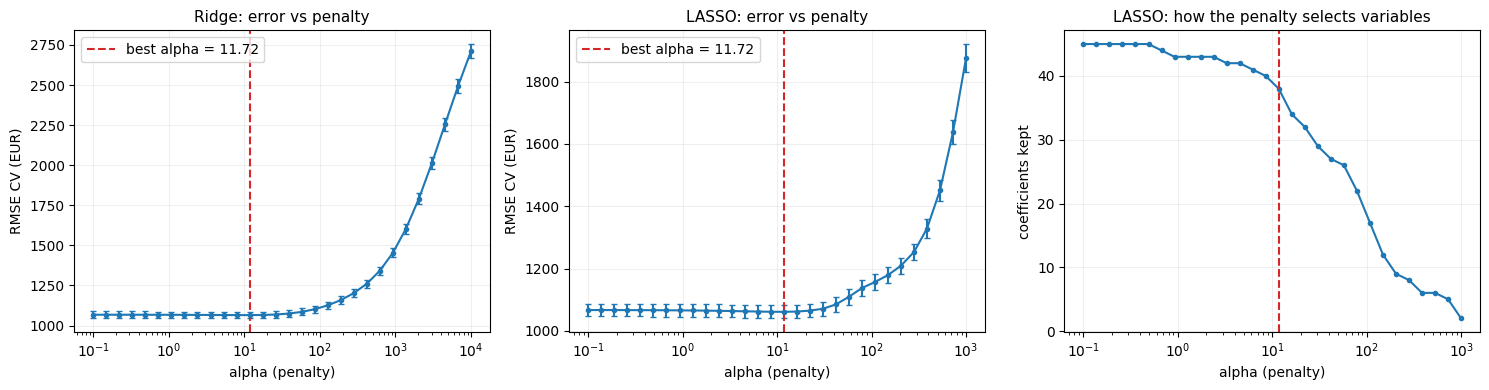

Ridge: best alpha = 11.72
LASSO: best alpha = 11.72, keeping 38 of 45 predictors


In [112]:
ridge_grid = alpha_curve(lambda a: Ridge(alpha=a), np.logspace(-1, 4, 30))
lasso_grid = alpha_curve(lambda a: Lasso(alpha=a, max_iter=50000), np.logspace(-1, 3, 30))
best_ridge = float(ridge_grid.loc[ridge_grid["RMSE CV"].idxmin(), "alpha"])
best_lasso = float(lasso_grid.loc[lasso_grid["RMSE CV"].idxmin(), "alpha"])

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, grid, nm, best in [(ax[0], ridge_grid, "Ridge", best_ridge), (ax[1], lasso_grid, "LASSO", best_lasso)]:
    a.errorbar(grid.alpha, grid["RMSE CV"], yerr=grid.SE, marker="o", ms=3, capsize=2)
    a.axvline(best, color="tab:red", ls="--", label=f"best alpha = {best:,.2f}")
    a.set(xscale="log", xlabel="alpha (penalty)", ylabel="RMSE CV (EUR)", title=f"{nm}: error vs penalty")
    a.legend(); a.grid(alpha=0.2)
ax[2].plot(lasso_grid.alpha, lasso_grid["non-zero coefficients"], marker="o", ms=3)
ax[2].axvline(best_lasso, color="tab:red", ls="--")
ax[2].set(xscale="log", xlabel="alpha (penalty)", ylabel="coefficients kept",
          title="LASSO: how the penalty selects variables")
ax[2].grid(alpha=0.2)
plt.tight_layout(); plt.show()

print(f"Ridge: best alpha = {best_ridge:,.2f}")
print(f"LASSO: best alpha = {best_lasso:,.2f}, keeping "
      f"{int(lasso_grid.loc[lasso_grid.alpha == best_lasso, 'non-zero coefficients'].iloc[0])} of {len(BASE)} predictors")

**Finding.** Both grids select λ ≈ 11.7, and at that value LASSO retains 38 of the 45 predictors.

**So what.** The error curves are flat across the lower half of each grid — in that region λ changes
*which variables survive* far more than it changes prediction error. Only past roughly λ = 100 does
error start to climb, and by λ = 10,000 Ridge has degraded to about 2,700 €. The penalty choice is
therefore not delicate; what is at stake is parsimony, not accuracy.

**Action.** These two values are fixed and carried into B.2.

### 2.2 The three models compared

All three are scored on the same folds, and their coefficients are then placed side by side on the
standardised scale so that shrinkage can be read variable by variable rather than in aggregate.

In [113]:
MODELS = {"OLS": LinearRegression(),
          "Ridge": Ridge(alpha=best_ridge),
          "LASSO": Lasso(alpha=best_lasso, max_iter=50000)}

rows = []
COEFS = {}
for nm, est in MODELS.items():
    r, se, mae_cv = cv_score(pipe(est))
    c = coef_of(est)
    COEFS[nm] = c
    rows.append({"model": nm, "RMSE CV": r, "SE": se, "MAE CV": mae_cv,
                 "predictors kept": int((c.abs() > 1e-8).sum()),
                 "largest |coef| (std. scale)": c.abs().max()})
show(pd.DataFrame(rows).set_index("model").round(1), "Part B: the three models on identical folds")

Part B: the three models on identical folds


,RMSE CV,SE,MAE CV,predictors kept,largest |coef| (std. scale)
model,,,,,
OLS,"1,067.300",20.300,794.700,45,"1,907.900"
Ridge,"1,064.900",20.600,791.700,45,"1,804.300"
LASSO,"1,061.400",21.100,788.900,38,"1,875.000"


In [114]:
C = pd.DataFrame(COEFS)
C["dropped by LASSO"] = np.where(C.LASSO.abs() < 1e-8, "yes", "")
show(C.reindex(C.OLS.abs().sort_values(ascending=False).index).head(12).round(1),
     "Coefficients on the standardised scale - the 12 largest under OLS:")
print(f"LASSO sets {int((C.LASSO.abs() < 1e-8).sum())} of {len(BASE)} coefficients to exactly zero.")
print(f"Ridge sets {int((C.Ridge.abs() < 1e-8).sum())} to zero - by construction it never does.")
cluster = ["Fuel_Type_Diesel", "CC", "HP", "Weight", "Quarterly_Tax"]
show(C.loc[cluster].round(1), "The engine and fuel cluster, under each model:")

Coefficients on the standardised scale - the 12 largest under OLS:


,OLS,Ridge,LASSO,dropped by LASSO
Age_08_04,"-1,907.900","-1,804.300","-1,875.000",
Weight,909.000,871.700,873.600,
CC,-689.500,-577.100,-568.300,
HP,603.900,535.400,535.500,
Quarterly_Tax,522.200,485.800,432.500,
KM,-514.800,-539.200,-521.700,
Body_Liftback,-316.100,-283.600,-231.900,
Automatic_airco,294.200,305.200,307.400,
Fuel_Type_CNG,-287.100,-273.900,-248.800,
Doors,214.600,205.100,144.000,


LASSO sets 7 of 45 coefficients to exactly zero.
Ridge sets 0 to zero - by construction it never does.
The engine and fuel cluster, under each model:


,OLS,Ridge,LASSO,dropped by LASSO
Fuel_Type_Diesel,24.700,-27.500,-0.000,yes
CC,-689.500,-577.100,-568.300,
HP,603.900,535.400,535.500,
Weight,909.000,871.700,873.600,
Quarterly_Tax,522.200,485.800,432.500,


### 2.3 Variable selection by statistical criteria

Regularisation is one route to a smaller predictor set; the classical alternative is stepwise
testing. Forward selection starts from an empty model and adds, at each step, the predictor with the
smallest p-value. Backward elimination starts from all 45 and removes the least significant one at a
time. Both use **HC3 robust p-values**, because the iagnosis in §3.2 rejects constant variance,
and ordinary standard errors are then wrong — here by up to a factor of two.

**These runs exist to be compared, not recommended.** Every step tests a hypothesis chosen after
looking at the data, so the p-values do not carry their nominal meaning, and the cross-validated
error that follows is optimistic: the variables were selected on the very folds the error is measured
on. The question being asked is narrower and more useful — whether two defensible procedures,
applied to the same data, even agree with each other.

In [115]:
# ============================================================
# Variable selection on statistical criteria: forward selection and backward elimination
# ============================================================

def _pvals(cols, X, y, robust):
    m = sm.OLS(y, add_const(X[cols])).fit()
    p = pd.Series(m.get_robustcov_results("HC3").pvalues if robust else m.pvalues,
                  index=["const"] + list(cols))
    return p.drop("const"), m


def forward_selection(candidates=None, p_in=0.05, X=None, y=None, robust=True, verbose=True):
    """Start from nothing and add, at each step, the predictor with the smallest p-value.

    Stops when no remaining predictor would enter at p < `p_in`. `robust=True` uses HC3 p-values,
    which is the defensible choice here because the diagnosis rejects constant variance and
    ordinary standard errors are then wrong by up to a factor of two.
    """
    X = Xtr if X is None else X
    y = ytr if y is None else y
    pool = list(BASE) if candidates is None else list(candidates)
    chosen = []
    while pool:
        best = None
        for c in pool:
            try:
                p, _ = _pvals(chosen + [c], X, y, robust)
            except Exception:
                continue
            if best is None or p[c] < best[1]:
                best = (c, float(p[c]))
        if best is None or best[1] >= p_in:
            break
        chosen.append(best[0])
        pool.remove(best[0])
        if verbose:
            print(f"  + {best[0]:22s} p = {best[1]:.2e}   ({len(chosen)} in)")
    if verbose:
        print(f"forward selection kept {len(chosen)} of {len(BASE) if candidates is None else len(candidates)}")
    return chosen


def backward_elimination(cols=None, p_out=0.05, X=None, y=None, robust=True, verbose=True):
    """Start from every predictor and drop, at each step, the least significant one.

    Stops when every remaining predictor has p < `p_out`. Unlike forward selection this begins
    from the full model, so a predictor whose contribution only shows once the others are present
    is never missed - the two can therefore end on different sets, which is itself worth reporting.
    """
    X = Xtr if X is None else X
    y = ytr if y is None else y
    keep = list(BASE) if cols is None else list(cols)
    while len(keep) > 1:
        p, _ = _pvals(keep, X, y, robust)
        worst, pv = p.idxmax(), float(p.max())
        if pv < p_out:
            break
        keep.remove(worst)
        if verbose:
            print(f"  - {worst:22s} p = {pv:.3f}   ({len(keep)} left)")
    if verbose:
        print(f"backward elimination kept {len(keep)} of {len(BASE) if cols is None else len(cols)}")
    return keep

In [116]:
fwd = forward_selection()

  + Age_08_04              p = 4.86e-220   (1 in)
  + Automatic_airco        p = 3.71e-25   (2 in)
  + KM                     p = 5.29e-15   (3 in)
  + Central_Lock           p = 1.14e-18   (4 in)
  + Weight                 p = 4.05e-11   (5 in)
  + Fuel_Type_Diesel       p = 1.32e-08   (6 in)
  + Body_Liftback          p = 5.83e-07   (7 in)
  + Fuel_Type_CNG          p = 2.48e-07   (8 in)
  + Mfr_Guarantee          p = 2.27e-05   (9 in)
  + Guarantee_Period       p = 6.30e-03   (10 in)
  + BOVAG_Guarantee        p = 1.25e-03   (11 in)
  + Quarterly_Tax          p = 7.18e-03   (12 in)
  + CC                     p = 5.51e-03   (13 in)
  + Body_Sedan             p = 6.69e-03   (14 in)
  + HP                     p = 1.70e-02   (15 in)
  + Airco                  p = 1.57e-02   (16 in)
  + Color_Green            p = 1.97e-02   (17 in)
  + ABS                    p = 3.02e-02   (18 in)
forward selection kept 18 of 45


In [117]:
bwd = backward_elimination()

  - Color_Silver           p = 0.955   (44 left)
  - Fuel_Type_Diesel       p = 0.943   (43 left)
  - Color_Other            p = 0.939   (42 left)
  - Gears                  p = 0.765   (41 left)
  - Sport_Model            p = 0.730   (40 left)
  - Radio_cassette         p = 0.733   (39 left)
  - Central_Lock           p = 0.667   (38 left)
  - Metallic_Rim           p = 0.644   (37 left)
  - Body_Wagon             p = 0.614   (36 left)
  - Power_Steering         p = 0.553   (35 left)
  - Airbag_1               p = 0.544   (34 left)
  - Backseat_Divider       p = 0.474   (33 left)
  - Airbag_2               p = 0.644   (32 left)
  - Trim_LUNA              p = 0.356   (31 left)
  - Mistlamps              p = 0.412   (30 left)
  - Trim_Unknown           p = 0.392   (29 left)
  - Color_Red              p = 0.333   (28 left)
  - Color_Blue             p = 0.343   (27 left)
  - Body_Sedan             p = 0.238   (26 left)
  - Met_Color              p = 0.180   (25 left)
  - Body_Unknown    

In [118]:
lasso_kept = [c for c in BASE if abs(COEFS["LASSO"][c]) > 1e-8]
sets = {"OLS (all)": list(BASE), "LASSO": lasso_kept, "forward": fwd, "backward": bwd}

rows = []
for nm, cols in sets.items():
    r, se, mae_cv = cv_score(pipe(LinearRegression()), Xtr[cols], ytr)
    rows.append({"selection": nm, "k": len(cols), "RMSE CV": r, "SE": se, "MAE CV": mae_cv})
show(pd.DataFrame(rows).set_index("selection").round(1),
     "OLS refitted on each selected set, same folds:")

agree = pd.DataFrame({nm: [c in cols for c in BASE] for nm, cols in sets.items()}, index=BASE)
agree["methods keeping it"] = agree[["LASSO", "forward", "backward"]].sum(axis=1)
show(agree[agree["methods keeping it"] < 3].drop(columns="OLS (all)").replace({True: "keep", False: ""}),
     "Predictors the three selection methods disagree about:")
print(f"kept by all three: {int((agree['methods keeping it'] == 3).sum())} of {len(BASE)}")

OLS refitted on each selected set, same folds:


,k,RMSE CV,SE,MAE CV
selection,,,,
OLS (all),45,"1,067.300",20.300,794.700
LASSO,38,"1,054.200",20.000,789.000
forward,18,"1,057.900",21.700,781.900
backward,21,"1,044.000",20.100,781.000


Predictors the three selection methods disagree about:


,LASSO,forward,backward,methods keeping it
Met_Color,keep,,,1
Automatic,keep,,,1
Doors,keep,,keep,2
Gears,keep,,,1
Airbag_1,keep,,,1
Airbag_2,,,,0
Boardcomputer,keep,,keep,2
CD_Player,keep,,keep,2
Central_Lock,keep,keep,,2
Powered_Windows,keep,,keep,2


kept by all three: 15 of 45


**Finding — the two procedures do not agree.** Forward stops at 18 predictors, backward at 21, and
the sets are not nested. Counting LASSO as a third method, only **15 of 45 predictors are kept by all
three**.

`Fuel_Type_Diesel` is the clearest case. Forward adds it at step 6 with p = 1.3e-08; backward deletes
it second with p = 0.943; LASSO zeroes it. The collinear engine cluster explains the contradiction —
early in forward selection, before HP, CC, Weight and Quarterly_Tax have entered, `Diesel` stands in
for all of them; once they are present it carries nothing of its own. `Central_Lock` repeats the
pattern: entered fourth at p = 1.1e-18, deleted at p = 0.667, correlation 0.88 with `Powered_Windows`.

**So what.** On cross-validated error the four sets span 23 € — backward (21) 1,044 €, LASSO's set
(38) 1,054 €, forward (18) 1,058 €, all 45 predictors 1,067 € — against standard errors near 20 €.
That spread sits inside the noise, and three of the four sets were chosen on these same folds, so
their error is optimistic in a way the 45-predictor baseline's is not. Backward is the more defensible
of the two stepwise procedures, because it judges each predictor with all the others present rather
than in isolation, but no winner can be declared from this table.

**Action.** What the table does establish is carried forward instead: roughly half the predictors
hold no independent information, and *which* half is discarded depends on the procedure. No stepwise
set becomes the working specification — that decision is made in §3.12 under the pre-registered
one-SE rule.

### 2.4 What the comparison says

**On prediction the three are indistinguishable.** OLS 1,067 €, Ridge 1,065 €, LASSO 1,061 € — a 6 €
spread against a standard error of about 20 €. With 857 training rows against 45 predictors the
estimates are already stable, leaving little variance for shrinkage to remove. This is what §1.7
predicted; it is now confirmed rather than assumed.

**What LASSO buys is interpretation, not accuracy.** It sets 7 of the 45 coefficients to exactly
zero, `Fuel_Type_Diesel` among them — the worst collinearity offender in the notebook (VIF 23.5;
R² = 0.957 when regressed on HP, CC, Weight and Quarterly_Tax). Its behaviour across the three fits
is the diagnosis in miniature: OLS puts it at **+25**, Ridge at **−28**, LASSO at exactly **0**. A
coefficient whose *sign* depends on which estimator is used is not measuring anything about diesel
engines. Ridge stabilises the cluster by spreading weight across its members; only LASSO resolves it
by removing the redundant one.

**The strong signals are untouched by either penalty.** Age, Weight, CC, HP and KM keep their signs
and nearly their magnitudes across all three fits — Age moves −1,908 → −1,804 → −1,875 € per standard
deviation. Shrinkage is acting on collinear noise, not on structure.

**Conclusion for Part B.** With prediction tied, the choice cannot rest on RMSE and is deferred to
the the pre-registered one-SE rule in §3.12, which prefers the simpler candidate when the difference
is within one standard error. Part C may change the specification first, and §2.5 then re-runs
regularisation on whatever specification survives the diagnosis.

## Part C — Diagnostics, remediation and model improvement

Part B produced three models that predict equally well. This stage asks a different question:
whether the model that produces those numbers is **entitled** to them, and if not, what to do
about it.

The structure is a diagnosis followed by three remedies, each aimed at a specific failure rather
than applied in hope:

| | | Targets |
|---|---|---|
| §3.2–3.3 | Diagnosis: which assumptions fail, and which variable is responsible | — |
| §3.4 | **Remedy 1 — the specification**: squares and interactions between predictors | A2 |
| §3.5 | **Remedy 2 — the response**: log(Price), and HC3 standard errors for inference | A3, A4 |
| §3.6 | **Remedy 3 — the loss function**: Huber, and quantile regression across the price distribution | A4, A6 |
| §3.7–3.8 | Every run in one table, and what the whole diagnosis implies | — |

**Why diagnosis comes before regularisation.** A penalty belongs on the design matrix the model
will actually use. Section 2.5 therefore runs after this stage, on whatever specification survives it.

### 3.1 The experiment engine and the verdict rules

Every specification in this stage goes through one function: fit, score out of sample on the fixed
folds, test the six assumptions, log the result. One path for every estimator means that any
difference between two rows of the log is the specification and never the procedure.

**The six checks, and what each one can actually detect.**

| | Test | What it detects | Why this test |
|---|---|---|---|
| **A1** | Durbin–Watson | Correlation between neighbouring residuals; 2 means none | The standard test for serial dependence. Weak evidence here, and reported as such: the rows are ordered by `Id`, not by time, so there is no ordering for dependence to follow. A1 is close to satisfied by construction. |
| **A2** | Ramsey RESET | Misspecified functional form anywhere in the model — powers of the fitted values are added as regressors and F-tested | It does not require guessing *which* predictor is wrong; it asks whether the fitted surface is the wrong shape at all |
| **A3** | Breusch–Pagan | Residual variance that moves with the predictors: $LM = n R^2$ from regressing squared residuals on the design | White's test adds every square and cross-product; with 45 predictors that auxiliary regression is larger than the model itself and loses power |
| **A4** | Shapiro–Wilk, with skew and excess kurtosis | Non-normal errors, and *how* they are non-normal | The most powerful general normality test at this sample size. The two moments separate a skew problem, which a target transformation fixes, from a heavy-tail problem, which calls for a robust loss |
| **A5** | VIF, $1/(1-R_j^2)$ | How far collinearity inflates each coefficient's variance | It reads directly as a variance multiplier: VIF 25 means a standard error five times what an orthogonal design would give |
| **A6** | Cook's distance | Observations whose removal would move every fitted value | Combines leverage and residual size in one number. $4/n$ is a screening threshold; $D > 1$ is the level that matters |

**Failing them does not cost the same.** A2 and A5 attack the estimates themselves — a wrong
functional form biases every coefficient, and collinearity makes them unstable. A3 and A4 leave OLS
unbiased and consistent and damage the *standard errors* instead. At $n = 857$ the central limit
theorem already covers much of A4, which is why its verdict never drives a decision on its own here.

**Each rule pairs a test with an effect size,** because at this sample size the formal tests reject
departures far too small to act on. RESET must show both $p < 0.05$ *and* $F \geq 10$ before A2 is
recorded as failed; anything between the PASS and FAIL conditions is MARGINAL.

In [119]:
# ============================================================
# Part C - experiment engine
# One fit -> one score -> one set of verdicts -> one log entry.
# ============================================================

# ---- Verdict rules, fixed here before any model runs -------------------------
RULES = pd.DataFrame([
    ("A1 independence",         "Durbin-Watson, Id order",       "1.5 < DW < 2.5",            "DW <= 1.4 or DW >= 2.6"),
    ("A2 linearity",            "Ramsey RESET (y^2, y^3)",       "p >= 0.05",                 "p < 0.05 and F >= 10"),
    ("A3 homoscedasticity",     "Breusch-Pagan, all predictors", "p >= 0.05",                 "p < 0.05 and LM >= 2k"),
    ("A4 normality",            "Shapiro-Wilk + skew/kurtosis",  "p >= 0.05",                 "p < 0.05 and (|skew| > 0.5 or exkurt > 1)"),
    ("A5 no multicollinearity", "max VIF over the predictors",   "max VIF < 5",               "max VIF >= 10"),
    ("A6 no influence",         "Cook D share over 4/n, max D",  "share <= 5% and max D < 1", "share > 10% or max D >= 1"),
], columns=["assumption", "measure", "PASS if", "FAIL if"]).set_index("assumption")

ASSUMPTIONS = list(RULES.index)
MARK = {"PASS": "OK", "MARGINAL": "~", "FAIL": "X", "n/a": "-"}
EXPERIMENTS = []

# Which assumptions each estimator is *graded* on. An assumption an estimator does not
# require is scored "n/a": the measure is still computed and reported as a description,
# but it cannot pass or fail, because failing it would not be evidence of anything.
# Declared here, before any alternative estimator runs, so it is a rule and not an excuse.
SCORED = {
    "ols":       set(ASSUMPTIONS),
    "log":       set(ASSUMPTIONS),                        # still OLS, on a transformed target
    "penalised": set(ASSUMPTIONS) - {"A6 no influence"},  # no OLS hat matrix
    "robust":    set(ASSUMPTIONS) - {"A3 homoscedasticity", "A4 normality", "A6 no influence"},
    "quantile":  set(ASSUMPTIONS) - {"A3 homoscedasticity", "A4 normality", "A6 no influence"},
}


# ---- Which columns may carry curvature ---------------------------------------
def _continuous(Xd):
    "Columns that can show curvature at all: a binary dummy cannot."
    return [c for c in Xd.columns if Xd[c].nunique() > 2]


def _measured(Xd, threshold=20):
    """Columns that measure a quantity, as opposed to labelling a class.

    `Gears` takes 3 distinct values, `Doors` 4, `Quarterly_Tax` 10, `CC` and `HP` 11 each.
    These name an engine or equipment class; their squares and products are close to linearly
    dependent on the original column and add collinearity without adding shape. Anything above
    `threshold` distinct values is treated as genuinely measured. One rule, one definition,
    used by every section that builds a power or an interaction.
    """
    return [c for c in Xd.columns if Xd[c].nunique() > threshold]


# ---- Fitters: every estimator behind one interface ---------------------------
# Each exposes .predict(X) in EUROS, plus .resid / .fittedvalues on the scale the
# equation was actually estimated on, which is the scale the assumption tests belong on.

class _OLSFit:
    family, reads = "ols", "EUR per unit"

    def __init__(self, X, y):
        self.m = sm.OLS(y, add_const(X)).fit()
        self.resid, self.fittedvalues, self.params = self.m.resid, self.m.fittedvalues, self.m.params

    def predict(self, X):
        return pd.Series(np.asarray(self.m.predict(add_const(X)), float), index=X.index)


class _LogOLSFit:
    """OLS on log(Price), returning predictions in euros through Duan's smearing estimate.

    If log Y = Xb + e, then E[Y|X] = exp(Xb) * E[exp(e)], and by Jensen E[exp(e)] > 1: the naive
    exp(Xb) estimates the conditional *median* and under-predicts the mean systematically. Duan's
    estimate of that factor is the sample mean of exp(residual), which assumes nothing about the
    shape of the error distribution - unlike the parametric exp(sigma^2/2), which assumes normal
    errors that A4 rejects in every specification here.

    The factor is estimated from data, so it is computed inside __init__ from the rows this fit
    was given. Cross-validation calls fit once per fold, so each fold gets a factor computed on
    its own training rows only, exactly like a scaler or a centring constant.
    """
    family, reads = "log", "approx. % per unit"

    def __init__(self, X, y):
        self.m = sm.OLS(np.log(y), add_const(X)).fit()
        self.resid, self.fittedvalues, self.params = self.m.resid, self.m.fittedvalues, self.m.params
        self.duan = float(np.mean(np.exp(self.m.resid)))

    def predict(self, X):
        return pd.Series(np.exp(np.asarray(self.m.predict(add_const(X)), float)) * self.duan, index=X.index)


class _HuberFit:
    """Huber M-estimator: squared loss for small residuals, linear beyond a threshold.

    Wrapped so predict() takes the design matrix without a constant column, the way every other
    estimator here does; statsmodels' RLM expects the caller to supply the constant, which
    silently breaks a cross-validation loop handed a raw fold.
    """
    family, reads = "robust", "EUR per unit"

    def __init__(self, X, y):
        self.m = sm.RLM(y, add_const(X), M=sm.robust.norms.HuberT()).fit()
        self.resid, self.fittedvalues, self.params = self.m.resid, self.m.fittedvalues, self.m.params
        self.weights = self.m.weights

    def predict(self, X):
        return pd.Series(np.asarray(self.m.predict(add_const(X)), float), index=X.index)


class _QuantFit:
    "Quantile regression at tau: estimates the conditional tau-quantile of price, not its mean."
    family, reads = "quantile", "EUR per unit, at this quantile"

    def __init__(self, X, y, q=0.5, max_iter=20000):
        self.q = q
        self.m = QuantReg(y, add_const(X)).fit(q=q, max_iter=max_iter)
        self.resid, self.fittedvalues, self.params = self.m.resid, self.m.fittedvalues, self.m.params

    def predict(self, X):
        return pd.Series(np.asarray(self.m.predict(add_const(X)), float), index=X.index)


FITTERS = {"ols": _OLSFit, "log": _LogOLSFit, "huber": _HuberFit, "quantile": _QuantFit}


def _make_fitter(how, **kw):
    "Return a callable (X, y) -> fitted object, so CV and the full fit use the same recipe."
    cls = FITTERS[how]
    return lambda X, y: cls(X, y, **kw)


# ---- Out-of-sample scoring ---------------------------------------------------
def _cv(Xd, yv, fitter, seed=SEED, n_splits=10, n_repeats=3):
    """Repeated k-fold CV on the fixed folds; RMSE, its SE across folds, and MAE, all in euros.

    Every candidate is refitted from scratch inside each fold, so anything the fitter estimates -
    a Duan factor, a robust scale - is estimated on training rows only.
    """
    folds = list(RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=seed).split(Xd))
    err = np.zeros((n_repeats, len(yv)))
    for k, (a, b) in enumerate(folds):
        f = fitter(Xd.iloc[a], yv.iloc[a])
        err[k // n_splits, b] = yv.iloc[b].values - f.predict(Xd.iloc[b]).values
    fr = np.array([np.sqrt(np.mean(err[k // n_splits, b] ** 2)) for k, (a, b) in enumerate(folds)])
    return (float(np.sqrt(np.mean(err ** 2))),
            float(fr.std(ddof=1) / np.sqrt(len(folds))),
            float(np.mean(np.abs(err))))


# ---- The six measures --------------------------------------------------------
def _assumptions(fit, Xd, order_key):
    """The six diagnostic measures, computed on the scale the equation was estimated on.

    For a log-target model that means the log residuals: the log equation is the one that was
    fitted, and testing residuals converted back to euros would test a model nobody estimated.
    RESET uses statsmodels' implementation where the fit is an OLS, and an auxiliary regression of
    the residuals on the squared and cubed fitted values otherwise - the same test, by hand.
    """
    res, fitted = fit.resid, fit.fittedvalues
    Xc = add_const(Xd)
    if isinstance(fit, (_OLSFit, _LogOLSFit)):
        r = linear_reset(fit.m, power=3, test_type="fitted", use_f=True)
        reset_f, reset_p = float(r.statistic), float(r.pvalue)
        cook = OLSInfluence(fit.m).cooks_distance[0]
    else:
        aux = sm.OLS(res, add_const(pd.DataFrame({"f2": fitted ** 2, "f3": fitted ** 3},
                                                 index=Xd.index))).fit()
        reset_f, reset_p = float(aux.fvalue), float(aux.f_pvalue)
        cook = np.array([np.nan])
    lm, lm_p, _, _ = het_breuschpagan(res, Xc)
    vif = pd.Series({c: variance_inflation_factor(Xc.values, i)
                     for i, c in enumerate(Xc.columns) if c != "const"}).sort_values(ascending=False)
    stats = {
        "DW": float(durbin_watson(np.asarray(res)[np.argsort(order_key)])),
        "RESET F": reset_f, "RESET p": reset_p,
        "BP LM": float(lm), "BP p": float(lm_p),
        "Shapiro p": float(st.shapiro(res)[1]),
        "skew": float(st.skew(res)), "exkurt": float(st.kurtosis(res)),
        "max VIF": float(vif.max()), "VIF>=5": int((vif >= 5).sum()), "VIF>=10": int((vif >= 10).sum()),
        "Cook share": float((cook > 4 / len(res)).mean()) if np.isfinite(cook).all() else np.nan,
        "max Cook": float(np.max(cook)) if np.isfinite(cook).all() else np.nan,
    }
    return stats, vif, cook


def _grade(pass_cond, fail_cond):
    return "PASS" if pass_cond else ("FAIL" if fail_cond else "MARGINAL")


def _verdicts(a, k, family="ols"):
    "Grade only the assumptions this estimator actually requires; the rest are n/a."
    scored = SCORED.get(family, set(ASSUMPTIONS))
    raw = {
        "A1 independence":         _grade(1.5 < a["DW"] < 2.5, a["DW"] <= 1.4 or a["DW"] >= 2.6),
        "A2 linearity":            _grade(a["RESET p"] >= 0.05, a["RESET p"] < 0.05 and a["RESET F"] >= 10),
        "A3 homoscedasticity":     _grade(a["BP p"] >= 0.05, a["BP p"] < 0.05 and a["BP LM"] >= 2 * k),
        "A4 normality":            _grade(a["Shapiro p"] >= 0.05,
                                          a["Shapiro p"] < 0.05 and (abs(a["skew"]) > 0.5 or a["exkurt"] > 1)),
        "A5 no multicollinearity": _grade(a["max VIF"] < 5, a["max VIF"] >= 10),
        "A6 no influence":         ("n/a" if not np.isfinite(a.get("max Cook", np.nan)) else
                                    _grade(a["Cook share"] <= 0.05 and a["max Cook"] < 1,
                                           a["Cook share"] > 0.10 or a["max Cook"] >= 1)),
    }
    return {k2: (raw[k2] if k2 in scored else "n/a") for k2 in ASSUMPTIONS}


# ---- The one entry point -----------------------------------------------------
def run_experiment(cols=None, name=None, X=None, y=None, how="ols", verbose=True,
                   replace=True, **fit_kw):
    """Fit, score out of sample, test the assumptions, log the run.

    cols : predictor names (default BASE)
    how  : "ols" | "log" | "huber" | "quantile"  (quantile takes q=)
    Errors are always in euros, so every run in the log is directly comparable.
    """
    X = Xtr if X is None else X
    y = ytr if y is None else y
    cols = list(BASE) if cols is None else list(cols)
    missing = [c for c in cols if c not in X.columns]
    if missing:
        raise KeyError(f"not in the design matrix: {missing}")
    name = name or f"run {len(EXPERIMENTS) + 1} ({len(cols)} features)"

    Xd = X[cols]
    fitter = _make_fitter(how, **fit_kw)
    fit = fitter(Xd, y)
    pred = fit.predict(Xd)
    cv_rmse, cv_se, cv_mae = _cv(Xd, y, fitter)
    order_key = df.loc[X.index, "Id"].values if "Id" in df.columns else np.arange(len(X))
    a, vif, cook = _assumptions(fit, Xd, order_key)
    v = _verdicts(a, len(cols), fit.family)

    # R2 is always recomputed on the euro scale. For a log model the reported R2 of the fit is
    # the R2 of the log equation, which is not comparable with any other run in this table.
    ss_res = float(np.sum((y - pred) ** 2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))

    rec = {"run": name, "k": len(cols), "n": len(y), "family": fit.family,
           "RMSE in-sample": rmse(y, pred), "RMSE CV": cv_rmse, "SE": cv_se, "MAE CV": cv_mae,
           "R2": 1 - ss_res / ss_tot,
           "adj R2": 1 - (1 - ss_res / ss_tot) * (len(y) - 1) / (len(y) - len(cols) - 1),
           **a, **v,
           "_cols": cols, "_fit": fit, "_model": fit.m, "_Xd": Xd, "_y": y,
           "_vif": vif, "_cook": cook, "_pred": pred,
           "_top_id": (int(df.loc[Xd.index, "Id"].values[int(np.argmax(cook))])
                       if np.isfinite(cook).all() else np.nan)}
    for i, e in enumerate(EXPERIMENTS):
        if replace and e["run"] == name:
            EXPERIMENTS[i] = rec
            break
    else:
        EXPERIMENTS.append(rec)

    if verbose:
        print(f"=== {name} ===")
        print(f"features {len(cols)} | n {len(y)} | {len(y) / (len(cols) + 1):.1f} obs per parameter"
              + (f" | estimator: {how}" if how != "ols" else ""))
        print(f"RMSE in-sample {rec['RMSE in-sample']:>9,.1f} EUR    R2 {rec['R2']:.4f}")
        print(f"RMSE CV        {cv_rmse:>9,.1f} +/- {cv_se:.1f} EUR    MAE CV {cv_mae:,.1f} EUR")
        cook_txt = ("not defined for this estimator" if not np.isfinite(cook).all() else
                    f"{a['Cook share']:.1%} over 4/n, max D = {a['max Cook']:.3f} (Id {rec['_top_id']})")
        det = pd.DataFrame({
            "verdict": [v[k] for k in ASSUMPTIONS],
            "evidence": [f"DW = {a['DW']:.3f}",
                         f"F = {a['RESET F']:.1f}, p = {a['RESET p']:.2e}",
                         f"LM = {a['BP LM']:.1f}, p = {a['BP p']:.2e}",
                         f"p = {a['Shapiro p']:.2e}, skew {a['skew']:+.2f}, exkurt {a['exkurt']:+.2f}",
                         f"max {a['max VIF']:.1f} ({vif.index[0]}); {a['VIF>=10']} at 10+, {a['VIF>=5']} at 5+",
                         cook_txt]}, index=ASSUMPTIONS)
        det.index.name = "assumption"
        show(det, "assumption checks:")
    return rec


# ---- The log ------------------------------------------------------------------
def _get(run=None):
    "Resolve a run: None = the last one, a string = by name, or a record straight through."
    if run is None:
        if not EXPERIMENTS:
            raise ValueError("no runs logged yet")
        return EXPERIMENTS[-1]
    if isinstance(run, dict):
        return run
    for e in EXPERIMENTS:
        if e["run"] == run:
            return e
    raise KeyError(f"no run named {run!r}; logged: {[e['run'] for e in EXPERIMENTS]}")


def assumption_table():
    "One row per run, one column per assumption. '-' = the estimator does not require it."
    if not EXPERIMENTS:
        return pd.DataFrame()
    t = pd.DataFrame([{"run": e["run"], "k": e["k"], "RMSE CV": round(e["RMSE CV"], 1),
                       **{k.split()[0]: MARK[e[k]] for k in ASSUMPTIONS}} for e in EXPERIMENTS])
    t["passed"] = [sum(e[k] == "PASS" for k in ASSUMPTIONS) for e in EXPERIMENTS]
    t["failed"] = [sum(e[k] == "FAIL" for k in ASSUMPTIONS) for e in EXPERIMENTS]
    t["n/a"] = [sum(e[k] == "n/a" for k in ASSUMPTIONS) for e in EXPERIMENTS]
    return t.set_index("run")


def experiment_table():
    "Performance and the raw diagnostic numbers for every logged run."
    if not EXPERIMENTS:
        return pd.DataFrame()
    keep = ["k", "n", "family", "RMSE in-sample", "RMSE CV", "SE", "MAE CV", "R2", "adj R2",
            "DW", "RESET F", "RESET p", "BP LM", "BP p", "Shapiro p", "skew", "exkurt",
            "max VIF", "VIF>=5", "VIF>=10", "Cook share", "max Cook"]
    return pd.DataFrame([{"run": e["run"], **{k: e[k] for k in keep}} for e in EXPERIMENTS]).set_index("run")


show(RULES, "Verdict rules, fixed before any run (anything between PASS and FAIL is MARGINAL):")
print("Graded per estimator family:", {f: len(s) for f, s in SCORED.items()}, "of 6 assumptions")

Verdict rules, fixed before any run (anything between PASS and FAIL is MARGINAL):


,measure,PASS if,FAIL if
assumption,,,
A1 independence,"Durbin-Watson, Id order",1.5 < DW < 2.5,DW <= 1.4 or DW >= 2.6
A2 linearity,"Ramsey RESET (y^2, y^3)",p >= 0.05,p < 0.05 and F >= 10
A3 homoscedasticity,"Breusch-Pagan, all predictors",p >= 0.05,p < 0.05 and LM >= 2k
A4 normality,Shapiro-Wilk + skew/kurtosis,p >= 0.05,p < 0.05 and (|skew| > 0.5 or exkurt > 1)
A5 no multicollinearity,max VIF over the predictors,max VIF < 5,max VIF >= 10
A6 no influence,"Cook D share over 4/n, max D",share <= 5% and max D < 1,share > 10% or max D >= 1


Graded per estimator family: {'ols': 6, 'log': 6, 'penalised': 5, 'robust': 3, 'quantile': 3} of 6 assumptions


**Four verdicts, not three.** Alongside PASS, MARGINAL and FAIL there is **`n/a`**, and which
assumptions each estimator is graded on is declared in `SCORED` above — before any alternative
estimator has been fitted.

The reason is that the six assumptions are not requirements of "regression"; they are requirements
of **OLS**. Huber uses a loss that is deliberately insensitive to heavy tails, and quantile
regression is distribution-free and consistent under heteroscedasticity. Recording A4 as FAIL for
Huber would be a category error: the estimator was chosen *because* the residuals are not normal,
so non-normal residuals are the intended condition, not a defect. The same holds for
Breusch–Pagan under quantile regression.

What does **not** change is A2. Both estimators are still linear in the predictors, so a wrong
functional form damages them exactly as it damages OLS. Linearity is not an OLS-only assumption
and stays graded for every estimator. A5 likewise: collinearity is a property of the design matrix,
not of the loss function.

The measures themselves are still computed and printed for every run. An `n/a` verdict means the
number is reported as a **description** and cannot pass or fail — not that the number is hidden.

**One rule for what counts as measured.** `_measured()` fixes at 20 distinct values the line
between a variable that measures a quantity and one that labels a class. On the training set it
returns exactly `Age_08_04`, `KM` and `Weight`. `Gears` has 3 levels, `Doors` 4, `Quarterly_Tax` 10,
`CC` and `HP` 11 — these name an engine or equipment class, and their squares and products add
collinearity without adding shape. Every section that builds a power or an interaction uses this
one definition, so the notebook cannot contradict itself about which variables are continuous.

**The display layer.** A verdict is only half the job. `max VIF` does not name the collinear
feature and `Cook share` does not name the cars, so the engine is paired with a display layer whose
whole purpose is to name the culprit.

Two charts and one panel earn their place; everything else is a table, because a table is exact and
a chart of the same numbers is not.

- `diagnostic_plots` — residuals vs fitted, which shows curvature and a widening funnel in the same
  picture, and the Q–Q plot, which separates a skew problem from a tails problem.
- `plot_residuals_by_feature` — residuals against each continuous predictor, to see what the model
  did not absorb.
- `ccpr_plots` — **partial-residual plots**, the panel that decides whether a variable needs
  transforming. See the note in §3.4 for why the ordinary scatter of price against a predictor
  cannot answer that question.
- `vif_report`, `influential_rows`, `median_residual_by_level` — tables that name the feature, the
  car, and the level.

In [120]:
# ============================================================
# Part C - diagnostic display layer
# Two plots, one partial-residual panel, the rest tables: a table names the culprit.
# ============================================================

def diagnostic_plots(run=None):
    """The two pictures a statistic cannot replace.

    Residuals vs fitted: RESET reports that the model is misspecified but not how, and this panel
    shows curvature and a widening funnel at once - which is what decides the remedy.
    Q-Q: separates a skew problem, which a target transformation fixes, from a tails problem,
    which calls for a robust loss.
    """
    rec = _get(run)
    fit, name = rec["_fit"], rec["run"]
    res, fitted = fit.resid, fit.fittedvalues
    unit = "log EUR" if rec["family"] == "log" else "EUR"
    lowess = sm.nonparametric.lowess
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

    ax[0].scatter(fitted, res, s=10, alpha=0.45)
    lw = lowess(res, fitted, frac=0.3)
    ax[0].plot(lw[:, 0], lw[:, 1], "r-", lw=2, label="LOWESS")
    ax[0].axhline(0, color="k", ls="--", lw=1.2)
    ax[0].set(title="Residuals vs fitted (A2 curvature, A3 funnel)",
              xlabel=f"fitted ({unit})", ylabel=f"residual ({unit})")
    ax[0].legend()

    sm.qqplot(np.asarray(res), line="45", fit=True, ax=ax[1])
    ax[1].set_title(f"Q-Q plot of residuals (A4): skew {st.skew(res):+.2f}, "
                    f"excess kurtosis {st.kurtosis(res):+.2f}")
    fig.suptitle(f"Diagnostics: {name}", y=1.0)
    plt.tight_layout()
    plt.show()


def plot_residuals_by_feature(run=None, features=None, ncol=3, max_levels=15):
    """Residuals against each continuous predictor: is anything left that the model did not catch?

    The plot type follows the feature. Many distinct values get a scatter with a LOWESS smoother;
    few get a boxplot of the residuals at each level with the number of cars underneath. That is
    not cosmetic: `Gears` takes three values and one holds a single car, so a smoother swings by
    thousands of euros on that one point and reads as strong curvature, while `Age_08_04`, which
    really is curved, looks flat because its deviation spreads over 72 values.

    Binary dummies are excluded throughout. OLS residuals are orthogonal to every column in the
    model, so the mean residual is exactly zero in both levels of a dummy and the panel is flat
    whatever the truth is.
    """
    rec = _get(run)
    Xd, res = rec["_Xd"], rec["_fit"].resid
    unit = "log EUR" if rec["family"] == "log" else "EUR"
    feats = list(features) if features is not None else _continuous(Xd)
    if not feats:
        print("no continuous predictors in this specification")
        return
    lowess = sm.nonparametric.lowess
    ncol = min(ncol, len(feats))
    nrow = int(np.ceil(len(feats) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5.2 * ncol, 3.8 * nrow), squeeze=False)
    for a, f in zip(axes.ravel(), feats):
        x = Xd[f]
        if x.nunique() <= max_levels:
            levels = sorted(x.unique())
            groups = [np.asarray(res)[(x == lv).values] for lv in levels]
            a.boxplot(groups, positions=range(len(levels)), widths=0.6)
            a.set_xticks(range(len(levels)))
            a.set_xticklabels([f"{lv:g}\nn={len(gp)}" for lv, gp in zip(levels, groups)], fontsize=7)
            a.set_title(f"{f}  ({x.nunique()} levels)", fontsize=10)
        else:
            a.scatter(x, res, s=10, alpha=0.4)
            lw = lowess(res, x, frac=0.4)
            a.plot(lw[:, 0], lw[:, 1], "r-", lw=1.8, label="LOWESS")
            a.set_title(f"{f}  ({x.nunique()} distinct values)", fontsize=10)
            a.legend(fontsize=8)
        a.axhline(0, color="k", ls="--", lw=1.2)
        a.set(xlabel=f, ylabel=f"residual ({unit})")
        a.grid(alpha=0.2)
    for a in axes.ravel()[len(feats):]:
        a.axis("off")
    fig.suptitle(f"Residuals vs each continuous feature: {rec['run']}", y=1.0)
    plt.tight_layout()
    plt.show()


def ccpr_plots(run=None, features=None, ncol=3):
    """Component-plus-residual (partial-residual) plots: one predictor's shape, others held fixed.

    A scatter of price against KM answers the wrong question. It shows the *marginal* relationship,
    in which old cars and high-mileage cars are largely the same cars, so age's curvature appears
    as KM's. The partial-residual plot draws b_j * x_j + residual against x_j, which is what the
    model still sees for that predictor after the other 44 have taken what is theirs. A straight
    cloud means no transformation of that variable is called for; a bend means one is.

    This is the panel that decides a transformation. The marginal scatter cannot.
    """
    rec = _get(run)
    fit, Xd = rec["_fit"], rec["_Xd"]
    if not isinstance(fit, (_OLSFit, _LogOLSFit)):
        raise TypeError("partial-residual plots need an OLS-family fit")
    feats = list(features) if features is not None else _measured(Xd)
    lowess = sm.nonparametric.lowess
    ncol = min(ncol, len(feats))
    nrow = int(np.ceil(len(feats) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5.2 * ncol, 3.9 * nrow), squeeze=False)
    out = {}
    for a, f in zip(axes.ravel(), feats):
        x = Xd[f]
        comp = fit.params[f] * x + fit.resid          # component + residual
        a.scatter(x, comp, s=10, alpha=0.4)
        a.plot(x, fit.params[f] * x, "k--", lw=1.4, label="linear fit")
        lw = lowess(comp, x, frac=0.5)
        a.plot(lw[:, 0], lw[:, 1], "r-", lw=1.8, label="LOWESS")
        # how far the smoother departs from the straight line, in euros
        gap = float(np.max(np.abs(lw[:, 1] - fit.params[f] * lw[:, 0])))
        out[f] = gap
        a.set(title=f"{f}: max gap {gap:,.0f}", xlabel=f, ylabel="component + residual")
        a.legend(fontsize=8)
        a.grid(alpha=0.2)
    for a in axes.ravel()[len(feats):]:
        a.axis("off")
    fig.suptitle(f"Partial-residual plots (others held fixed): {rec['run']}", y=1.0)
    plt.tight_layout()
    plt.show()
    return pd.Series(out, name="max |LOWESS - line|").to_frame()


def vif_report(run=None):
    "Which feature causes the multicollinearity, and what explains it. A table, not a bar chart."
    rec = _get(run)
    vif = rec["_vif"]
    tab = vif.to_frame("VIF")
    tab["Status"] = np.select([tab.VIF >= 10, tab.VIF >= 5], ["PROBLEM", "WARNING"], default="OK")
    bad = tab[tab.Status != "OK"]
    if not len(bad):
        print(f"every feature is below VIF 5; max is {vif.max():.2f} ({vif.index[0]})")
        return tab
    show(bad.round(2), f"Features above the VIF thresholds ({len(bad)} of {len(vif)}):")
    worst = vif.index[0]
    aux = sm.OLS(rec["_Xd"][worst], add_const(rec["_Xd"].drop(columns=worst))).fit()
    t = aux.tvalues.drop("const").abs().sort_values(ascending=False).head(4)
    print(f"{worst} (VIF {vif.iloc[0]:.1f}) is explained by the other predictors with auxiliary "
          f"R2 = {aux.rsquared:.3f}; strongest: "
          + ", ".join(f"{k} (|t| = {x:.0f})" for k, x in t.items()))
    return tab


def drop_by_vif(cols=None, threshold=5.0, X=None, y=None, name=None, min_features=2, verbose=True):
    """Remove predictors one at a time, worst VIF first, until every VIF is below `threshold`.

    One at a time and not all at once, because VIF is a joint property: `Fuel_Type_Diesel`, `CC`
    and `Quarterly_Tax` inflate each other, so removing the worst lowers the others with no further
    action. Dropping every flagged feature in one pass would discard predictors that were never
    collinear on their own.

    The threshold is 5 because that is the notebook's own PASS rule for A5, fixed in RULES before
    any model was fitted. The survivors are handed to `run_experiment`, so the trade lands in the
    same log as everything else: what it bought in the A5 verdict, and what it cost in euros.
    """
    X = Xtr if X is None else X
    y = ytr if y is None else y
    cols = list(BASE) if cols is None else list(cols)
    start, steps = len(cols), []

    def _vif_of(cs):
        Xc = add_const(X[cs])
        return pd.Series({c: variance_inflation_factor(Xc.values, i)
                          for i, c in enumerate(Xc.columns) if c != "const"}).sort_values(ascending=False)

    while len(cols) > min_features:
        vif = _vif_of(cols)
        if steps:
            steps[-1]["max VIF after"] = round(float(vif.iloc[0]), 2)
        if vif.iloc[0] < threshold:
            break
        steps.append({"step": len(steps) + 1, "dropped": vif.index[0],
                      "its VIF": round(float(vif.iloc[0]), 2), "features left": len(cols) - 1,
                      "max VIF after": np.nan})
        cols = [c for c in cols if c != vif.index[0]]
    if steps and not np.isfinite(steps[-1]["max VIF after"]):
        steps[-1]["max VIF after"] = round(float(_vif_of(cols).iloc[0]), 2)

    dropped = [s["dropped"] for s in steps]
    if verbose:
        if steps:
            show(pd.DataFrame(steps).set_index("step"),
                 f"VIF pruning at threshold {threshold:g}: {len(dropped)} of {start} predictors removed")
        else:
            print(f"nothing to remove: every VIF is already below {threshold:g}")
    rec = run_experiment(cols, name=name or f"VIF-pruned <{threshold:g} ({len(cols)})",
                         X=X, y=y, verbose=verbose)
    rec["_vif_dropped"] = dropped
    return rec


def influential_rows(run=None, top=10, extra=("Age_08_04", "KM", "HP", "Fuel_Type", "Trim", "km_suspect")):
    "Which observations move the fit, identified by Id and specification rather than by row number."
    rec = _get(run)
    fit, cook = rec["_fit"], rec["_cook"]
    y, idx = rec["_y"], rec["_Xd"].index
    if not np.isfinite(cook).all():
        print("Cook's distance is not defined for this estimator")
        return None
    thr = 4 / len(cook)
    t = pd.DataFrame({
        "Id": df.loc[idx, "Id"].values,
        "Cook_D": cook,
        "leverage": OLSInfluence(fit.m).hat_matrix_diag,
        "actual": y.values,
        "fitted": np.asarray(rec["_pred"]),
        "residual": y.values - np.asarray(rec["_pred"]),
    }).nlargest(top, "Cook_D")
    cols = [c for c in extra if c in df.columns]
    t = t.merge(df[["Id"] + cols], on="Id")
    print(f"{int((cook > thr).sum())} observations above 4/n = {thr:.4f} "
          f"({(cook > thr).mean():.1%}); max Cook D = {cook.max():.3f} "
          f"({'no single point dominates' if cook.max() < 1 else 'one point dominates the fit'})")
    show(t.round(2), f"Top {top} influential observations: {rec['run']}")
    return t


def median_residual_by_level(run=None, features=("CC", "HP"), min_n=50):
    """The numbers behind the boxplot panels: a box cannot be read to the nearest euro.

    For each level of a class-like variable, the median residual and how many cars stand behind it.
    A large deviation resting on two cars is not evidence of anything, and only this table shows
    which is which.
    """
    rec = _get(run)
    Xd = rec["_Xd"]
    res = pd.Series(np.asarray(rec["_fit"].resid), index=Xd.index)
    out = {}
    for f in features:
        if f not in Xd.columns:
            continue
        t = (pd.DataFrame({f: Xd[f].astype(int), "residual": res})
               .groupby(f).residual.agg(n="size", median="median").round(0))
        big = t[t.n >= min_n]
        show(t, f"Median residual per {f} level - {len(big)} levels hold "
                f"{int(big.n.sum())} of {len(Xd)} cars; the rest are a handful each:")
        out[f] = t
    return out


def inspect(run=None):
    """The whole diagnosis for one run: the two overall panels, the per-feature panels, the VIFs.

    `influential_rows()` is deliberately not called here. The A6 verdict already carries the figure
    that decides anything - max Cook D, which says whether one point dominates - and it names the
    top observation. The full list is an audit of the data, worth running once rather than on every
    change of the feature set.
    """
    rec = _get(run)
    diagnostic_plots(rec)
    plot_residuals_by_feature(rec)
    vif_report(rec)

### 3.2 Baseline: all 45 predictors, no transformations

The reference every later specification is measured against. No derived terms, no transformation of
the target, no penalty — the same 45 predictors Part B used, so a difference in any later row of the
log is the remedy and not the data.

In [121]:
base_run = run_experiment(name="baseline: all 45")

=== baseline: all 45 ===
features 45 | n 857 | 18.6 obs per parameter
RMSE in-sample     987.1 EUR    R2 0.9175
RMSE CV          1,067.3 +/- 20.3 EUR    MAE CV 794.7 EUR
assumption checks:


,verdict,evidence
assumption,,
A1 independence,PASS,DW = 1.846
A2 linearity,FAIL,"F = 40.5, p = 1.69e-17"
A3 homoscedasticity,FAIL,"LM = 234.2, p = 2.10e-27"
A4 normality,FAIL,"p = 9.55e-10, skew +0.04, exkurt +2.40"
A5 no multicollinearity,FAIL,"max 23.5 (Fuel_Type_Diesel); 1 at 10+, 10 at 5+"
A6 no influence,MARGINAL,"7.4% over 4/n, max D = 0.144 (Id 605)"


**Finding — five of six assumptions do not hold.**

| | Verdict | Evidence |
|---|---|---|
| A1 independence | **PASS** | DW = 1.846 |
| A2 linearity | **FAIL** | F = 40.5, p = 1.7e-17 |
| A3 homoscedasticity | **FAIL** | LM = 234.2, p = 2.1e-27 |
| A4 normality | **FAIL** | p = 9.6e-10, skew +0.04, excess kurtosis +2.40 |
| A5 no multicollinearity | **FAIL** | max VIF 23.5; 10 features at 5+, 1 at 10+ |
| A6 no influence | MARGINAL | 7.4% above 4/n, max Cook's D = 0.144 |

Prediction is unaffected by any of this: RMSE CV = 1,067.3 ± 20.3 €, MAE = 794.7 €, R² = 0.918,
and the in-sample RMSE of 987 € against 1,067 € out of sample shows the gap between fitting and
predicting is modest.

**So what.** The model predicts well and satisfies almost none of the conditions under which its
standard errors, t-statistics and confidence intervals mean what they claim. That distinction is
the whole of Part C: **the point estimates are usable, the inference around them is not.** A2 and
A5 are the serious pair — a wrong functional form biases every coefficient, and collinearity makes
them unstable — while A3 and A4 leave the estimates unbiased and damage only their standard errors.

Two details worth reading before the remedies. A4 fails purely through the **tails**: skew is +0.04,
which is essentially symmetric, against excess kurtosis of +2.40. So the residual distribution is
not lopsided, it has too many extreme values — which points at a robust loss rather than a target
transformation. And A6 is reassuring: 7.4% of cars cross the 4/n screening threshold, but the
largest Cook's distance is 0.144, far below the value of 1 at which one observation would dominate
the fit.

**Now what.** §3.3 identifies which variable is responsible for each failure, because "A5 fails" is
not something anyone can act on. Only after that do the remedies begin.

### 3.3 Diagnosis: which variable is responsible

"A5 fails" is not something anyone can act on. This section converts each verdict into a name — a
feature, a level, or a car — because a remedy has to be aimed at something.

Three pieces of evidence, in order:

1. `inspect()` — the residual and Q–Q panels, the residuals against every continuous predictor,
   and the VIF table with the auxiliary regression that explains the worst offender.
2. `ccpr_plots()` — **partial-residual plots** for the three genuinely measured predictors. This is
   the panel that decides whether a variable needs transforming, and it is worth being explicit
   about why the obvious alternative does not. A scatter of price against KM shows the *marginal*
   relationship, in which old cars and high-mileage cars are largely the same cars, so age's
   curvature shows up as KM's. The partial-residual plot draws $\hat{\beta}_j x_j + \hat{e}$ against
   $x_j$ — what the model still sees for that predictor once the other 44 have taken what is theirs.
   A straight cloud means no transformation is called for. The marginal scatter cannot distinguish
   the two cases and would send us to transform the wrong variable.
3. The tables behind the boxplots. A box cannot be read to the nearest euro, and a dramatic-looking
   level may rest on two cars.

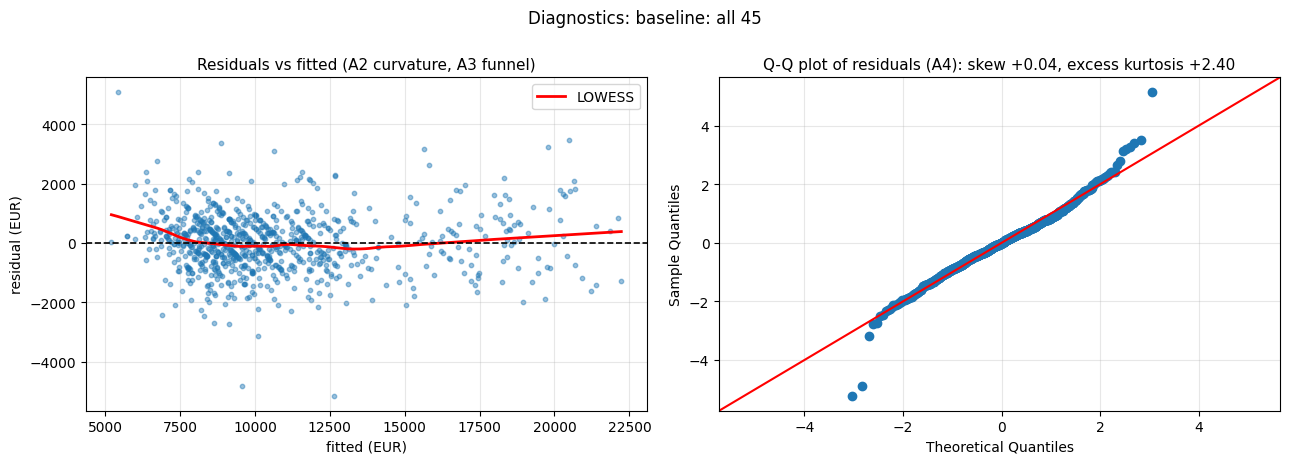

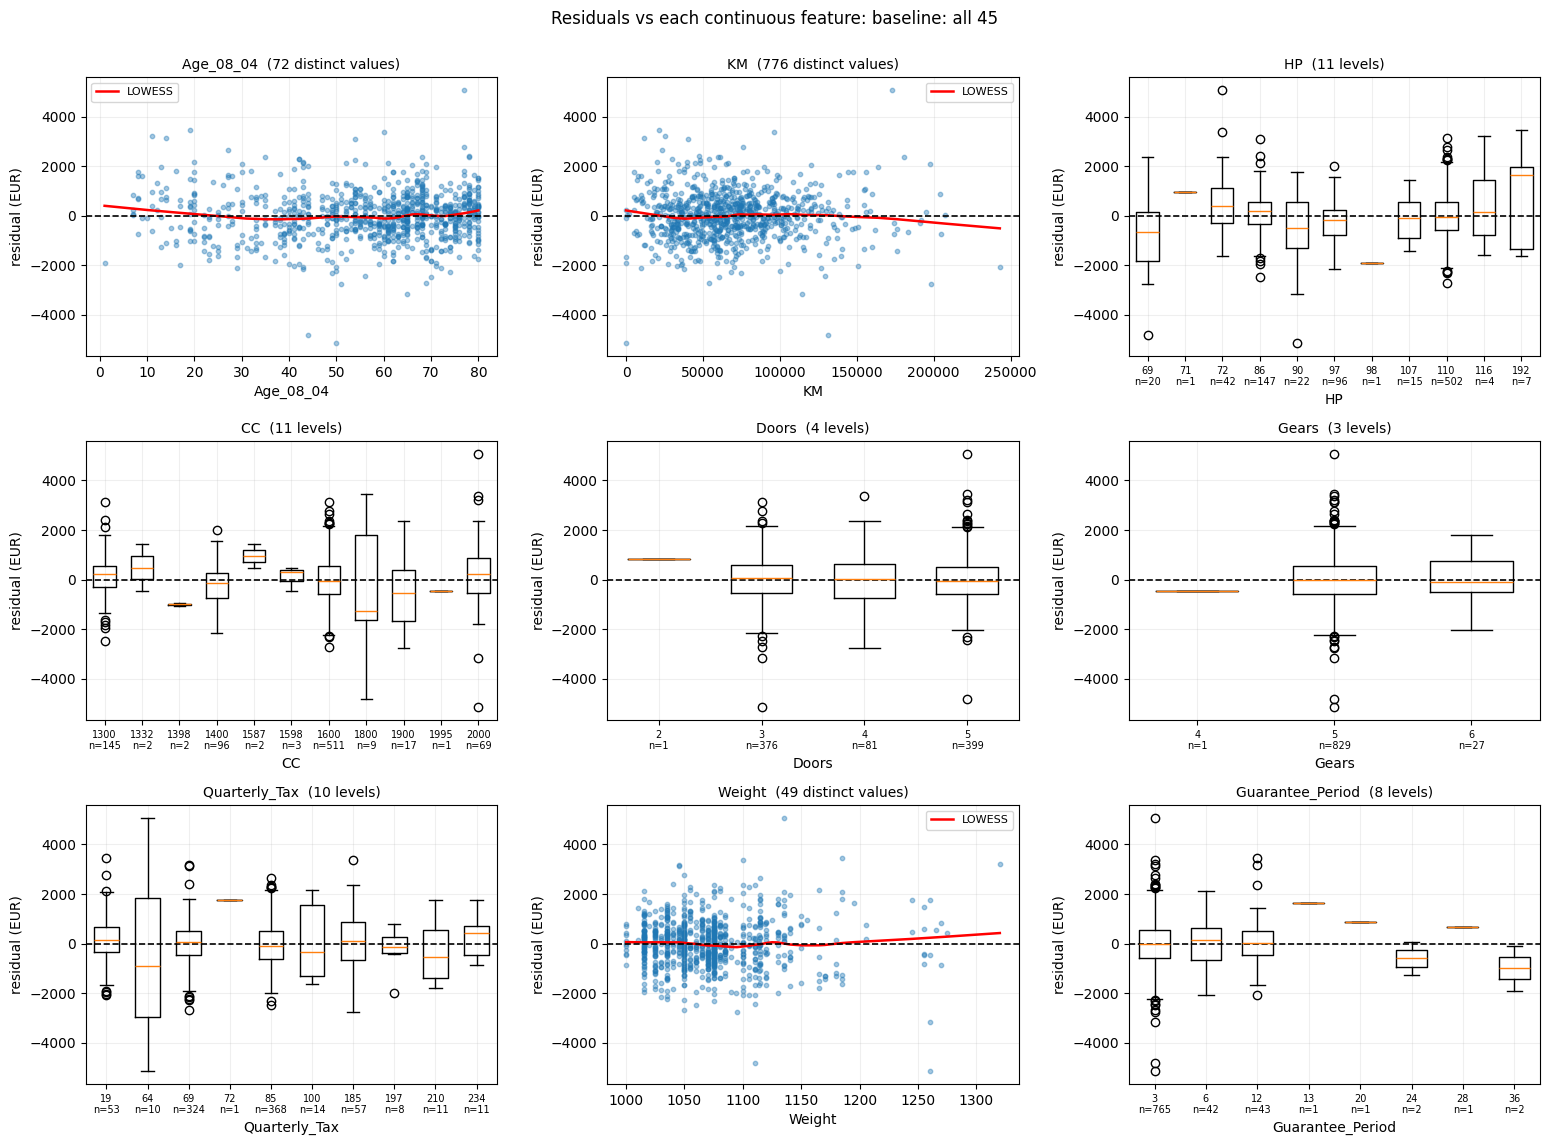

Features above the VIF thresholds (10 of 45):


,VIF,Status
Fuel_Type_Diesel,23.500,PROBLEM
CC,9.710,WARNING
Weight,9.160,WARNING
HP,7.940,WARNING
Body_Liftback,6.640,WARNING
Quarterly_Tax,5.720,WARNING
Central_Lock,5.650,WARNING
Doors,5.600,WARNING
Powered_Windows,5.540,WARNING
Age_08_04,5.520,WARNING


Fuel_Type_Diesel (VIF 23.5) is explained by the other predictors with auxiliary R2 = 0.957; strongest: HP (|t| = 45), CC (|t| = 28), Weight (|t| = 16), Quarterly_Tax (|t| = 11)


In [122]:
inspect("baseline: all 45")

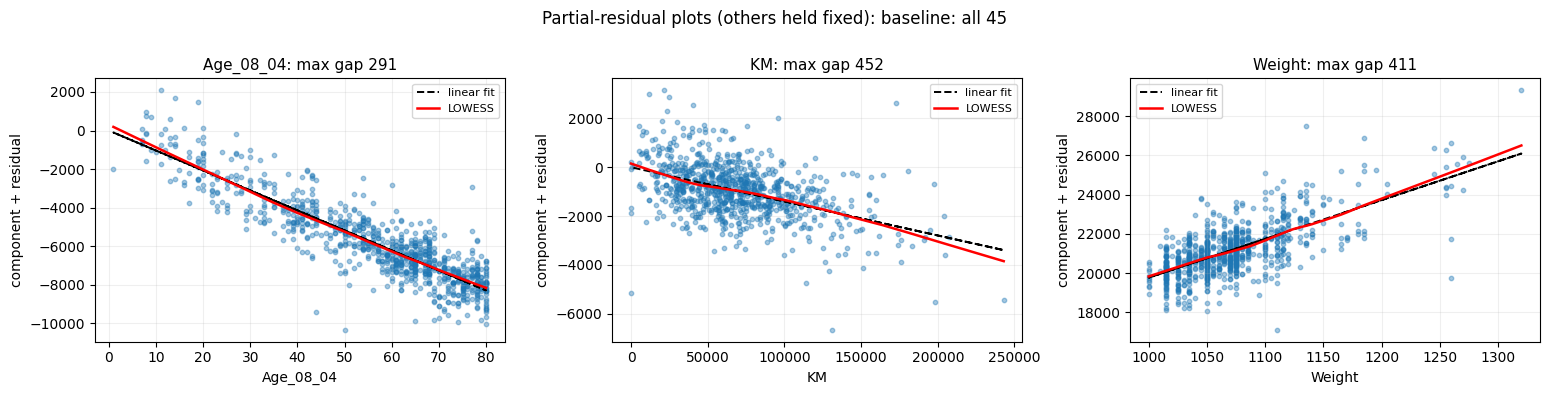

Partial-residual curvature: how far the smoother departs from the straight line (EUR)


,max |LOWESS - line|
Age_08_04,291.000
KM,452.000
Weight,411.000


63 observations above 4/n = 0.0047 (7.4%); max Cook D = 0.144 (no single point dominates)
Top 10 influential observations: baseline: all 45


,Id,Cook_D,leverage,actual,fitted,residual,Age_08_04,KM,HP,Fuel_Type,Trim,km_suspect
0,605,0.140,0.170,"7,500.000","12,648.450","-5,148.450",50,1,90,Diesel,Unknown,1
1,194,0.070,0.110,"4,750.000","9,579.140","-4,829.140",44,131273,69,Diesel,Unknown,0
2,658,0.070,0.210,"6,950.000","10,104.580","-3,154.580",65,114383,90,Diesel,TERRA,0
3,143,0.070,0.180,"23,950.000","20,489.910","3,460.090",19,21684,192,Petrol,Unknown,0
4,1063,0.060,0.090,"10,500.000","5,431.390","5,068.610",77,172980,72,Diesel,TERRA,0
5,140,0.060,0.180,"23,000.000","19,776.110","3,223.890",11,25000,116,Diesel,LUNA,0
6,622,0.030,0.260,"8,450.000","6,676.660","1,773.340",64,144000,110,CNG,Unknown,0
7,186,0.030,0.210,"17,795.000","19,690.940","-1,895.940",1,1,98,Petrol,TERRA,0
8,396,0.020,0.140,"4,450.000","6,898.440","-2,448.440",56,129155,69,Diesel,Unknown,0
9,332,0.020,0.180,"11,000.000","13,031.560","-2,031.560",41,33000,110,Petrol,SOL,0


Median residual per CC level - 4 levels hold 821 of 857 cars; the rest are a handful each:


...

Median residual per HP level - 3 levels hold 745 of 857 cars; the rest are a handful each:


,n,median
HP,,
69,20,-646.000
71,1,954.000
72,42,381.000
86,147,209.000
90,22,-477.000
97,96,-182.000
98,1,"-1,896.000"
107,15,-100.000
110,502,-33.000


The 10 records whose CC does not match the standard displacement:


Model,1.3,1.4,1.6,2.0,none
CC,,,,,
1332,1,0,0,0,1
1398,0,2,0,0,0
1587,0,0,2,0,0
1598,0,0,3,0,0
1995,0,0,0,1,0


CC takes 11 distinct values and HP 11 over 857 cars.


In [123]:
# ============================================================
# The numeric evidence behind the panels: which cars, which levels, and what CC really measures
# ============================================================
gaps = ccpr_plots("baseline: all 45")
show(gaps.round(0), "Partial-residual curvature: how far the smoother departs from the straight line (EUR)")

influential_rows("baseline: all 45")
median_residual_by_level("baseline: all 45", features=("CC", "HP"))

# Is CC a displacement, or a label for an engine class? Cross-check against the litre token
# printed in the Model string - a 1.6 car recorded as 1587 and another as 1598 is the same engine.
litre = (df.loc[Xtr.index, "Model"].astype(str)
           .str.extract(r"(\d\.\d)", expand=False).fillna("none"))
odd = Xtr.CC.astype(int).isin([1332, 1398, 1587, 1598, 1995])
show(pd.crosstab(Xtr.CC.astype(int)[odd], litre[odd]),
     f"The {int(odd.sum())} records whose CC does not match the standard displacement:")
print(f"CC takes {Xtr.CC.nunique()} distinct values and HP {Xtr.HP.nunique()} over {len(Xtr)} cars.")

**A5 has a name: `Fuel_Type_Diesel`.** Its VIF is 23.5, and an auxiliary regression of that column
on the other 44 returns R² = 0.957, driven by HP (|t| = 45), CC (28), Weight (16) and
Quarterly_Tax (11). Ten features sit above VIF 5, but this is **one cluster, not ten problems**:
diesel Corollas *are* the heavy, large-engine, high-tax cars, so the columns are near-duplicates of
each other by construction. It also explains the negative sign on `CC` — with weight and horsepower
already in the model, what is left of displacement is not engine size but the diesel/petrol split.

**A2 is not inside any single variable.** The partial-residual panels put the largest departure from
a straight line at 452 € for KM, 411 € for Weight and 291 € for Age — against a mean price of
10,658 €, so between 3% and 4%. RESET rejects at F = 40.5 while no individual predictor bends
appreciably once the others are held fixed. The misspecification is therefore **between** the
variables rather than within them, which is exactly what an interaction term addresses and what a
transformation of one column cannot. §3.4 acts on that.

**This contradicts the midterm's headline on KM, and both are right.** The marginal relationship
between mileage and price is clearly curved; the partial one is nearly straight. Old cars are the
high-mileage cars, so the curvature the midterm scatter showed belongs to age. A `log(KM)` term
taken from that picture would have transformed the wrong variable — §3.4 tests exactly that and
confirms it.

**`CC` and `HP` are class labels, not measurements.** Each takes 11 distinct values across 857 cars,
and the median residual per level zigzags rather than trending: CC runs +209 € at 1300, −153 at
1400, −43 at 1600 and +232 at 2000 across the four populated levels (821 of 857 cars), while HP
runs −646 at 69, +381 at 72, +209 at 86, −477 at 90 and −33 at 110. The dramatic-looking boxes rest
on almost nothing — −1,280 € at CC 1800 stands on nine cars, −995 € at 1398 on two.

A data fact confirms it: `1332`, `1398`, `1587`, `1598` and `1995` are not separate displacements.
Cross-checked against the litre token in the `Model` string they are 1.3, 1.4, 1.6, 1.6 and 2.0 cars
recorded at a different precision — ten records in total. **`CC` is six engine classes written as a
number.** This is the evidence behind the rule fixed in `_measured()`: squaring a class label adds
collinearity and no shape.

**A6 is reassuring and points back at A5.** 63 cars (7.4%) cross the 4/n screening threshold, but
the largest Cook's distance is 0.144, far below 1 — no single observation dominates the fit. The car
named is **Id 605**, the `km_suspect` record flagged in §1.2: 50 months old, KM recorded as 1, priced
at 7,500 € where the model says 12,648 €. Of the ten most influential cars, seven are diesel or CNG —
the A5 cluster again, showing up as leverage.

**Now what.** Three remedies follow, each aimed at a named failure rather than applied in hope:
§3.4 attacks A2 through the specification, §3.5 attacks A3 and A4 through the response variable, and
§3.6 attacks A4 and A6 through the loss function. §3.7 puts every run in one table.

### 3.4 Remedy 1 — the specification

The diagnosis found the misspecification **between** the variables rather than inside them: RESET
rejects at F = 40.5 while no single predictor bends by more than 4% of the mean price once the
others are held fixed. The remedy that matches that finding is a richer design — squares and
products — not a transformation of one column.

Derived terms are always built **beside** the original predictor, never in place of it. Replacing
`Age` by `Age²` asserts the relationship is purely quadratic; adding `Age²` next to `Age` lets the
data decide how much bend it wants. And every square and product is built on **centred** variables,
which keeps the main effect interpretable at the sample mean and removes the collinearity between
$x$ and $x^2$ that is an artefact of the units rather than a property of the data.

In [124]:
# ============================================================
# Part C - derived terms: built beside the originals, never in place of them
# ============================================================

def make_term(spec, X=None, ref=None):
    """Build one derived column from a short text spec, returning (name, values).

    Accepted:  log(f)   sqrt(f)   f^2, f^3, f^k   1/f   a*b

    Squares and interactions are built on *centred* variables. Centring leaves the main effect
    interpretable at the sample mean and removes the collinearity between x and x^2 that is an
    artefact of the scale rather than a property of the data - on raw KM, x and x^2 correlate at
    almost 1 for no reason but the units.

    `ref` supplies the centring constants and defaults to `X` itself, which is what every use
    inside the training set wants. Scoring a different set of rows is where it matters: centring
    the holdout on its own mean would build a differently-scaled column and the training
    coefficients would no longer apply to it. The final evaluation therefore passes ref=Xtr.
    """
    X = Xtr if X is None else X
    ref = X if ref is None else ref
    s = spec.replace(" ", "")
    if s.startswith("log(") and s.endswith(")"):
        f = s[4:-1]
        return f"log_{f}", np.log(X[f].astype(float))
    if s.startswith("sqrt(") and s.endswith(")"):
        f = s[5:-1]
        return f"sqrt_{f}", np.sqrt(X[f].astype(float))
    if s.startswith("1/"):
        f = s[2:]
        return f"inv_{f}", 1.0 / X[f].astype(float)
    if "^" in s:
        f, k = s.split("^")
        k = int(k)
        v = X[f].astype(float)
        return (f"{f}_sq" if k == 2 else f"{f}_p{k}"), (v - ref[f].astype(float).mean()) ** k
    if "*" in s:
        a, b = s.split("*")
        va, vb = X[a].astype(float), X[b].astype(float)
        return f"{a}_x_{b}", (va - ref[a].astype(float).mean()) * (vb - ref[b].astype(float).mean())
    raise ValueError(f"cannot parse term {spec!r}; use log(f), sqrt(f), f^k, 1/f or a*b")


def build_terms(specs, X=None, ref=None):
    "Turn a list of specs into a dict of new columns, checking each one is finite."
    X = Xtr if X is None else X
    out = {}
    for s in specs:
        name, v = make_term(s, X, ref)
        v = pd.Series(np.asarray(v, float), index=X.index, name=name)
        if not np.isfinite(v).all():
            raise ValueError(f"{s} is undefined for {int((~np.isfinite(v)).sum())} rows")
        out[name] = v
    return out


def add_terms(specs, cols=None, name=None, X=None, y=None, **kw):
    """Add derived terms *alongside* the original predictors and rerun the whole experiment.

    The difference from replacing a column matters: swapping `Age` for `Age^2` asserts the
    relationship is purely quadratic, while adding `Age^2` next to `Age` lets the data decide how
    much bend it wants. Everything else - the other predictors, the folds, the seed, the verdict
    rules - is held fixed.
    """
    X = Xtr if X is None else X
    y = ytr if y is None else y
    cols = list(BASE) if cols is None else list(cols)
    new = build_terms(specs, X)
    X2 = X.assign(**new)
    return run_experiment(cols + list(new), name=name or "+ " + " + ".join(new), X=X2, y=y, **kw)


def run_with_transform(feature, how, cols=None, name=None, X=None, y=None, **kw):
    """Replace one predictor by a transformation of itself and rerun everything unchanged.

    Applying the transformation before cross-validation leaks nothing: these are fixed functions of
    the column, and every fold would compute the same value. Anything *estimated* from the data - a
    centring constant, a scaler, a Box-Cox lambda - belongs inside the folds instead.
    """
    TRANSFORMS = {"log": (np.log, "log_{}"), "log1p": (np.log1p, "log1p_{}"),
                  "sqrt": (np.sqrt, "sqrt_{}"), "square": (lambda v: v ** 2, "{}_sq"),
                  "reciprocal": (lambda v: 1.0 / v, "inv_{}")}
    if how not in TRANSFORMS:
        raise KeyError(f"unknown transformation {how!r}; available: {list(TRANSFORMS)}")
    X = Xtr if X is None else X
    y = ytr if y is None else y
    cols = list(BASE) if cols is None else list(cols)
    fn, pattern = TRANSFORMS[how]
    new = pattern.format(feature)
    v = pd.Series(np.asarray(fn(X[feature].astype(float)), float), index=X.index, name=new)
    if not np.isfinite(v).all():
        raise ValueError(f"{how}({feature}) is undefined for {int((~np.isfinite(v)).sum())} rows")
    X2 = X.assign(**{new: v})
    return run_experiment([c for c in cols if c != feature] + [new],
                          name=name or f"{how}({feature})", X=X2, y=y, **kw)


def scan_terms(specs, cols=None, X=None, y=None):
    "One term at a time: what does each candidate buy in cross-validated euros, added on its own?"
    X = Xtr if X is None else X
    y = ytr if y is None else y
    cols = list(BASE) if cols is None else list(cols)
    ols = _make_fitter("ols")
    base, _, _ = _cv(X[cols], y, ols)
    rows = []
    for s in specs:
        try:
            new = build_terms([s], X)
        except (ValueError, KeyError) as e:
            rows.append((s, np.nan, str(e)[:40]))
            continue
        r, _, _ = _cv(X.assign(**new)[cols + list(new)], y, ols)
        rows.append((s, base - r, ""))
    t = (pd.DataFrame(rows, columns=["term", "RMSE gain (EUR)", "note"])
         .set_index("term").sort_values("RMSE gain (EUR)", ascending=False))
    print(f"reference: {base:,.1f} EUR with {len(cols)} predictors. "
          f"Positive gain = the term lowers cross-validated error when added on its own.")
    return t


def forward_terms(specs, cols=None, X=None, y=None, min_gain=1.0, verbose=True):
    """Add candidate terms greedily, keeping whichever lowers cross-validated error most.

    Necessary because the individual gains do not add up: each term explains part of the same
    signal as the others, so a term worth 34 euros alone can be worth nothing once a related term
    is in, and one worth almost nothing alone can become valuable later. Selection stops when the
    best remaining candidate buys less than `min_gain` euros.

    The selection uses the same folds the models are scored on, so the resulting RMSE is optimistic:
    it was chosen to look good on those folds. Treat it as a shortlist to confirm on the holdout,
    not as an unbiased estimate.
    """
    X = Xtr if X is None else X
    y = ytr if y is None else y
    cols = list(BASE) if cols is None else list(cols)
    ols = _make_fitter("ols")
    pool = {s: build_terms([s], X) for s in specs}
    chosen, chosen_cols, cur = [], {}, _cv(X[cols], y, ols)[0]
    if verbose:
        print(f"start: {cur:,.1f} EUR")
    while True:
        best = None
        for s, new in pool.items():
            if s in chosen:
                continue
            trial = {**chosen_cols, **new}
            r = _cv(X.assign(**trial)[cols + list(trial)], y, ols)[0]
            if best is None or r < best[1]:
                best = (s, r, new)
        if best is None or cur - best[1] < min_gain:
            if verbose and best is not None:
                print(f"stop: the best remaining term buys only {cur - best[1]:.1f} EUR")
            break
        chosen.append(best[0])
        chosen_cols.update(best[2])
        if verbose:
            print(f"  + {best[0]:18s} -> {best[1]:9,.1f} EUR   (gain {cur - best[1]:5.1f})")
        cur = best[1]
    return chosen

#### 3.4.1 Squares and interactions, then the VIF-pruning trap

Four steps in order: build the squares and pairwise products of the three genuinely measured
predictors, score the design, read its VIF, then remove the collinear columns and score it again.

`_measured()` supplies the three: **`Age_08_04`, `KM`, `Weight`** — 3 squares and 3 interactions.
`CC`, `HP`, `Gears`, `Doors` and `Quarterly_Tax` are excluded by the rule fixed in §3.1, and §3.3
showed why: they are class labels written as numbers, whose squares add collinearity and no shape.

The point of the section is the trade the two scores make visible.

In [125]:
# ============================================================
# Steps 1-2: squares and interactions on the measured predictors, then read the VIF
# ============================================================
CONT_TRUE = _measured(Xtr)
POLY_INT = ([f"{f}^2" for f in CONT_TRUE] +
            [f"{a}*{b}" for a, b in itertools.combinations(CONT_TRUE, 2)])
print(f"measured predictors: {CONT_TRUE}")
print(f"terms ({len(POLY_INT)}): {POLY_INT}")

pi_new  = build_terms(POLY_INT, Xtr)          # centred on training means, as everywhere else
pi_X    = Xtr.assign(**pi_new)
pi_cols = list(BASE) + list(pi_new)
PI_NAME = f"poly+interactions, measured ({len(pi_cols)})"

pi_run = run_experiment(pi_cols, name=PI_NAME, X=pi_X, verbose=False)
print(f"\nRMSE CV = {pi_run['RMSE CV']:,.1f} +/- {pi_run['SE']:.1f} EUR "
      f"(baseline {base_run['RMSE CV']:,.1f}), RESET F = {pi_run['RESET F']:.1f} "
      f"(baseline {base_run['RESET F']:.1f}), max VIF = {pi_run['max VIF']:.1f}")

measured predictors: ['Age_08_04', 'KM', 'Weight']
terms (6): ['Age_08_04^2', 'KM^2', 'Weight^2', 'Age_08_04*KM', 'Age_08_04*Weight', 'KM*Weight']

RMSE CV = 1,026.8 +/- 19.2 EUR (baseline 1,067.3), RESET F = 11.3 (baseline 40.5), max VIF = 27.5


In [126]:
# ============================================================
# Steps 3-4: remove the collinear columns, and score the same design again
# ============================================================
pi_pruned = drop_by_vif(pi_cols, X=pi_X, name="poly+interactions, VIF-pruned")

show(experiment_table().loc[["baseline: all 45", PI_NAME, "poly+interactions, VIF-pruned"],
                            ["k", "RMSE CV", "SE", "RESET F", "BP LM", "max VIF"]].round(2),
     "What each step bought, and what it cost:")

VIF pruning at threshold 5: 7 of 51 predictors removed


,dropped,its VIF,features left,max VIF after
step,,,,
1,Fuel_Type_Diesel,27.500,50,15.060
2,Weight,15.060,49,9.700
3,Age_08_04_x_Weight,9.700,48,6.810
4,Body_Liftback,6.810,47,5.840
5,Age_08_04,5.840,46,5.660
6,Central_Lock,5.660,45,5.010
7,Quarterly_Tax,5.010,44,4.310


=== poly+interactions, VIF-pruned ===
features 44 | n 857 | 19.0 obs per parameter
RMSE in-sample   1,289.7 EUR    R2 0.8591
RMSE CV          1,402.1 +/- 27.9 EUR    MAE CV 1,050.4 EUR
assumption checks:


,verdict,evidence
assumption,,
A1 independence,PASS,DW = 1.671
A2 linearity,FAIL,"F = 48.9, p = 8.87e-21"
A3 homoscedasticity,FAIL,"LM = 158.7, p = 7.22e-15"
A4 normality,FAIL,"p = 9.48e-08, skew -0.00, exkurt +1.88"
A5 no multicollinearity,PASS,"max 4.3 (Age_08_04_sq); 0 at 10+, 0 at 5+"
A6 no influence,MARGINAL,"7.4% over 4/n, max D = 0.316 (Id 605)"


What each step bought, and what it cost:


,k,RMSE CV,SE,RESET F,BP LM,max VIF
run,,,,,,
baseline: all 45,45,"1,067.290",20.330,40.520,234.230,23.500
"poly+interactions, measured (51)",51,"1,026.830",19.180,11.270,184.950,27.500
"poly+interactions, VIF-pruned",44,"1,402.090",27.900,48.900,158.660,4.310


**Finding — the interactions help; removing the collinearity destroys the model.**

| | k | RMSE CV | RESET F (A2) | max VIF (A5) |
|---|---|---|---|---|
| baseline | 45 | 1,067.3 ± 20.3 | 40.5 **FAIL** | 23.5 **FAIL** |
| + 3 squares + 3 interactions | 51 | **1,026.8 ± 19.2** | **11.3** | 27.5 **FAIL** |
| pruned to VIF < 5 | 44 | **1,402.1 ± 27.9** | 48.9 **FAIL** | **4.31 PASS** |

Six terms buy 40 € and cut RESET from 40.5 to 11.3 — two standard errors of improvement, and the
first specification in the notebook to come close to satisfying A2. Excess kurtosis also halves,
from 2.40 to 1.23: part of what looked like heavy tails was misspecification all along.

Pruning is the **only** thing in this notebook that makes A5 pass, and it costs **375 €** — more
than a third of the baseline error.

**So what — read the removal order.** `Fuel_Type_Diesel`, then **`Weight`**, then
`Age_08_04*Weight`, `Body_Liftback`, then **`Age_08_04`**, `Central_Lock`, `Quarterly_Tax`. The rule
deletes `Age` and `Weight` themselves — two of the strongest predictors in the data — because each
is now collinear with its own square and its own interaction. A2 gets *worse* for the same reason:
the main effects that carried the curvature are gone, so RESET climbs back from 11.3 to 48.9.

**The trap is general, and worth stating as a rule:** VIF pruning must never be run on a design
that contains a variable together with its own powers and products. The collinearity there is
**structural** — it follows from how the columns were built, not from anything in the data — and a
VIF rule cannot tell the two apart. Centring reduces that structural collinearity but does not
remove it.

**Now what.** The 51-term design is kept and the pruned one is not. A5 stays failed and is handed
to §2.5, where a penalty treats the *damage* collinearity does to the coefficients without deleting
the predictors that cause it.

#### 3.4.2 Transforming a single feature: a test the midterm's recommendation fails

The midterm EDA found the price–mileage relationship clearly curved and proposed transforming `KM`.
The partial-residual panel in §3.3 says the opposite: once the other 44 predictors are held fixed,
KM departs from a straight line by at most 452 € — about 4% of the mean price.

The two claims cannot both drive the model, so this section tests the midterm's recommendation
directly. `run_with_transform` **replaces** `KM` by a transformation of itself and reruns everything
unchanged: same predictors, same folds, same seed, same verdict rules. Both shapes the marginal
scatter suggests are tried.

Applying the transformation before cross-validation leaks nothing — these are fixed functions of the
column and every fold would compute the same value.

In [127]:
km_sqrt = run_with_transform("KM", "sqrt", name="sqrt(KM)")
km_log  = run_with_transform("KM", "log",  name="log(KM)")

show(experiment_table().loc[["baseline: all 45", "sqrt(KM)", "log(KM)"],
                            ["RMSE CV", "SE", "RESET F", "BP LM", "max Cook"]].round(2),
     "Replacing KM by a transformation of itself:")

=== sqrt(KM) ===
features 45 | n 857 | 18.6 obs per parameter
RMSE in-sample     997.1 EUR    R2 0.9158
RMSE CV          1,080.3 +/- 21.1 EUR    MAE CV 800.7 EUR
assumption checks:


,verdict,evidence
assumption,,
A1 independence,PASS,DW = 1.833
A2 linearity,FAIL,"F = 28.9, p = 7.56e-13"
A3 homoscedasticity,FAIL,"LM = 250.4, p = 2.71e-30"
A4 normality,FAIL,"p = 2.92e-10, skew -0.04, exkurt +2.63"
A5 no multicollinearity,FAIL,"max 23.5 (Fuel_Type_Diesel); 1 at 10+, 10 at 5+"
A6 no influence,MARGINAL,"7.2% over 4/n, max D = 0.196 (Id 605)"


=== log(KM) ===
features 45 | n 857 | 18.6 obs per parameter
RMSE in-sample   1,044.5 EUR    R2 0.9076
RMSE CV          1,135.7 +/- 22.1 EUR    MAE CV 841.9 EUR
assumption checks:


,verdict,evidence
assumption,,
A1 independence,PASS,DW = 1.786
A2 linearity,FAIL,"F = 30.3, p = 1.97e-13"
A3 homoscedasticity,FAIL,"LM = 247.6, p = 8.40e-30"
A4 normality,FAIL,"p = 3.76e-09, skew +0.00, exkurt +2.07"
A5 no multicollinearity,FAIL,"max 23.1 (Fuel_Type_Diesel); 1 at 10+, 10 at 5+"
A6 no influence,MARGINAL,"6.8% over 4/n, max D = 0.300 (Id 605)"


Replacing KM by a transformation of itself:


,RMSE CV,SE,RESET F,BP LM,max Cook
run,,,,,
baseline: all 45,"1,067.290",20.330,40.520,234.230,0.140
sqrt(KM),"1,080.330",21.110,28.900,250.380,0.200
log(KM),"1,135.660",22.110,30.340,247.650,0.300


**Finding — the partial-residual plot was right and the marginal scatter was wrong.**

| | RMSE CV | RESET F (A2) | BP LM (A3) | max Cook (A6) |
|---|---|---|---|---|
| baseline | 1,067.3 ± 20.3 | 40.5 | 234.2 | 0.144 |
| sqrt(KM) | 1,080.3 ± 21.1 | 28.9 | 250.4 | 0.196 |
| log(KM) | 1,135.7 ± 22.1 | 30.3 | 247.7 | 0.300 |

`sqrt(KM)` is 13 € worse than doing nothing, against a standard error of 21 — indistinguishable.
`log(KM)` is 68 € worse, more than three standard errors, a clear loss.

**So what.** The curvature that makes raw mileage look non-linear is largely **age wearing a
disguise**: old cars are the high-mileage cars, so a two-variable picture attributes age's bend to
KM. Once age is in the model there is no curvature left for a KM transformation to fix. Transforming
it anyway spends a degree of freedom on nothing and distorts the fit at the low-mileage end, where
five cars are recorded at KM = 1 and `log` sends them to 0 while a typical car sits near 11 — which
is why influence rises from 0.144 to 0.300.

**Two lessons the table teaches beyond KM.** First, **an assumption can be repaired without the
model getting any better**: RESET falls from 40.5 to about 29 under both transformations while
prediction gets worse. A2 and RMSE are not the same axis, and a remedy that improves one is not
automatically progress. Second, remedies are not free elsewhere — Breusch–Pagan moves the *wrong*
way under both (234 → 250), so treating A2 here would have cost A3.

**Now what.** No single-feature transformation is carried forward. The remaining candidates in
§3.4.3 are added *beside* the original columns rather than replacing them, which is the right shape
for curvature that the data may or may not want.

#### 3.4.3 A candidate set, scored one at a time and then selected

Ten candidate terms, and a deliberate departure from the `_measured()` rule that needs stating.

Four of the ten are built on `CC` and `HP`, which §3.3 identified as class labels rather than
measurements. `_measured()` governs the **mechanical** construction of squares and products, where
a rule is needed precisely because nobody inspects each term. A hand-built candidate list is a
different matter: `log(CC)` is not a square of a label but an attempt to compress its scale, and the
diagnosis gave a positive reason to try — the median residual per CC level zigzags in a way a single
linear coefficient cannot follow. §3.4.4 then tests whether these terms are really doing what their
names suggest.

Two functions, because the individual gains do not add up. `scan_terms` scores each candidate alone;
`forward_terms` builds a set greedily, keeping whichever term lowers cross-validated error most at
each step and stopping when the best remaining candidate buys under 1 €.

In [128]:
CANDIDATES = ["log(CC)", "CC^2", "log(HP)", "HP^2", "Age_08_04^2", "log(KM)",
              "Age_08_04*HP", "Age_08_04*KM", "Age_08_04*Weight", "KM*HP"]
show(scan_terms(CANDIDATES).round(1), "What each term buys on its own:")

reference: 1,067.3 EUR with 45 predictors. Positive gain = the term lowers cross-validated error when added on its own.
What each term buys on its own:


,RMSE gain (EUR),note
term,,
log(CC),36.600,
Age_08_04*HP,34.300,
CC^2,33.700,
Age_08_04*KM,23.100,
Age_08_04*Weight,15.900,
Age_08_04^2,14.500,
log(HP),4.900,
HP^2,4.400,
log(KM),2.700,


In [129]:
chosen = forward_terms(CANDIDATES)
print("chosen:", chosen)

naive = add_terms(CANDIDATES, name="all 10 candidates (45+10)", verbose=False)
tuned = add_terms(chosen, name=f"forward-selected {len(chosen)} (45+{len(chosen)})")

start: 1,067.3 EUR
  + log(CC)            ->   1,030.7 EUR   (gain  36.6)
  + Age_08_04*Weight   ->   1,016.2 EUR   (gain  14.5)
  + Age_08_04*KM       ->     999.1 EUR   (gain  17.1)
  + log(KM)            ->     987.1 EUR   (gain  12.1)
  + log(HP)            ->     977.3 EUR   (gain   9.7)
  + HP^2               ->     976.2 EUR   (gain   1.1)
stop: the best remaining term buys only 0.2 EUR
chosen: ['log(CC)', 'Age_08_04*Weight', 'Age_08_04*KM', 'log(KM)', 'log(HP)', 'HP^2']
=== forward-selected 6 (45+6) ===
features 51 | n 857 | 16.5 obs per parameter
RMSE in-sample     894.8 EUR    R2 0.9322
RMSE CV            976.2 +/- 15.3 EUR    MAE CV 752.1 EUR
assumption checks:


,verdict,evidence
assumption,,
A1 independence,PASS,DW = 1.931
A2 linearity,FAIL,"F = 16.3, p = 1.12e-07"
A3 homoscedasticity,FAIL,"LM = 136.0, p = 1.17e-09"
A4 normality,MARGINAL,"p = 1.83e-02, skew +0.12, exkurt +0.60"
A5 no multicollinearity,FAIL,"max 16935.8 (HP); 7 at 10+, 13 at 5+"
A6 no influence,MARGINAL,"8.5% over 4/n, max D = 0.141 (Id 605)"


**Finding — the individual gains do not add up, and selection beats inclusion.**

Summed, the ten candidates promise 171 €. Adding all ten delivers **85 €**. They overlap: `log(CC)`,
`CC²`, `Age×HP` and `Age×Weight` all describe part of the same signal. Forward selection reaches a
**larger** gain of 91 € with **four fewer terms**, and the ranking shifts mid-selection — `log(KM)`
is worth 2.7 € alone but 12.1 € at the point it was chosen, while `Age×HP`, second best alone at
34.3 €, is never picked at all.

| | k | RMSE CV | RESET F (A2) | BP LM (A3) | exc. kurtosis (A4) | max VIF (A5) |
|---|---|---|---|---|---|---|
| baseline | 45 | 1,067.3 ± 20.3 | 40.5 | 234.2 | 2.40 | 23.5 |
| all 10 candidates | 55 | 982.2 ± 15.8 | **2.47, p = 0.09** | 142.9 | 0.62 | 267,969 |
| forward-selected 6 | 51 | **976.2 ± 15.3** | 16.3 | 136.0 | 0.60 | 16,936 |

**Four of the five failures have moved.** A2 is the headline: the ten-term model is the only
specification in the notebook where **RESET does not reject** (F = 2.47, p = 0.09). A4 goes from
FAIL to MARGINAL, with excess kurtosis collapsing from 2.40 to 0.60 — most of the heavy tails were
misspecification, not outliers. A3 improves substantially (234 → 136) without passing.

**A5 is the exception, and it got catastrophically worse** — max VIF 23.5 → 16,936, and 267,969 with
all ten terms, because `HP`, `log(HP)` and `HP²` are very nearly the same column three times over.
Predictor transformations fix functional form and prediction; they cannot touch collinearity, and
here they inflame it.

**Both numbers are optimistic.** The terms were selected on the same folds that score them, so the
selection has been fitted to those folds. §3.9 onward measures how much of the gain survives on
data that had no part in choosing anything.

**Now what.** The 51-column forward-selected design is the working specification. Its A5 failure is
what §2.5 regularises, and §3.4.4 asks whether the CC and HP terms inside it are really measuring
curvature.

#### 3.4.4 Is `log(CC)` a transformation, or a proxy for engine class?

`log(CC)` was the single most valuable candidate at 36.6 €, and §3.3 argued that `CC` is not a
measurement at all but six engine classes written as a number. If that reading is right, the gain
should be reproducible by encoding those classes directly — and a set of dummies is the statistically
correct treatment of a class label, where a logarithm is only an approximation to it.

The test maps each car to its nearest standard displacement, which is exactly the grouping the litre
token in `Model` confirmed in §3.3, and replaces the numeric `CC` with five dummies against a base
of 1600 cc.

In [130]:
# ============================================================
# Treat CC as what the diagnosis said it is: six engine classes, not a measured volume
# ============================================================
STD = np.array([1300, 1400, 1600, 1800, 1900, 2000])
cc_class = Xtr.CC.astype(float).map(lambda v: int(STD[np.argmin(np.abs(STD - v))]))
print("cars per engine class:", cc_class.value_counts().sort_index().to_dict())

cc_dum  = pd.get_dummies(cc_class.rename("CCcls"), prefix="CCcls", dtype=float).drop(columns="CCcls_1600")
X_cc    = Xtr.assign(**{c: cc_dum[c] for c in cc_dum})
cols_cc = [c for c in BASE if c != "CC"] + list(cc_dum.columns)

cc_run = run_experiment(cols_cc, name=f"CC as 6 engine classes ({len(cols_cc)})", X=X_cc, verbose=False)
show(experiment_table().loc[["baseline: all 45", cc_run["run"]],
                            ["k", "RMSE CV", "SE", "RESET F", "BP LM", "max VIF"]].round(2),
     "CC as a number versus CC as six classes:")

cars per engine class: {1300: 147, 1400: 98, 1600: 516, 1800: 9, 1900: 17, 2000: 70}
CC as a number versus CC as six classes:


,k,RMSE CV,SE,RESET F,BP LM,max VIF
run,,,,,,
baseline: all 45,45,"1,067.290",20.330,40.520,234.230,23.500
CC as 6 engine classes (49),49,"1,032.460",18.440,27.270,221.770,211.440


**Finding — the reading was right.**

| | k | RMSE CV | RESET F | BP LM | max VIF |
|---|---|---|---|---|---|
| baseline, CC numeric | 45 | 1,067.3 ± 20.3 | 40.5 | 234.2 | 23.5 |
| CC as 6 engine classes | 49 | **1,032.5 ± 18.4** | 27.3 | 221.8 | 211.4 |

Five dummies buy 35 € — essentially the same 37 € that `log(CC)` bought on its own — and cut RESET
from 40.5 to 27.3. The 1300, 1400, 1600 and 2000 classes hold 831 of 857 cars; 1800 has nine and
1900 has seventeen.

**So what.** `log(CC)` was never smoothing a curved relationship between displacement and price. It
was a crude one-parameter stand-in for a class structure, and encoding that structure explicitly
recovers the same gain. That settles the question §3.4.3 raised about the candidate list: those
terms are doing something real, but not what their names imply.

**Now what — the dummies are not adopted.** They cost four extra parameters for a gain the
forward-selected specification already exceeds (976 € against 1,032 €), and they push max VIF to 211,
because engine class is nearly determined by horsepower, weight and fuel type. The run is recorded as
evidence about what `CC` measures, not as a candidate model. It is kept in the log and appears in the
comparison table in §3.7.

#### 3.4.5 Two controls: is the curvature inside the variables, or between them?

The specification chosen in §3.4.3 is built on interactions. That is a claim about *where* the
misspecification lives, and a claim of that kind deserves a control that could refute it.

**Control 1 — pure powers.** Squares and cubes of every continuous predictor, added beside the
originals: the diagonal of a quadratic design with none of its cross-products. If the curvature RESET
keeps rejecting were **inside** each variable, seventeen powers would find it.

This control deliberately relaxes the `_measured()` rule and builds powers of `CC`, `HP`, `Gears`,
`Doors` and `Quarterly_Tax` as well. That is the point: giving the within-variable hypothesis the
most generous possible design makes its failure evidence rather than an artefact of a restriction we
imposed. A power still needs more than $k$ distinct values, which excludes `Gears³` — with three
levels, 1, $x$ and $x^2$ already span everything definable there.

**Control 2 — a compact specification.** The four strongest continuous predictors and nothing else,
which removes the entire engine and fuel cluster. It shows the trade the other direction: what
solving A5 by deletion costs.

In [131]:
POLY = [f"{f}^{k}" for f in _continuous(Xtr) for k in (2, 3) if Xtr[f].nunique() > k]
print(f"{len(POLY)} admissible polynomial terms over {len(_continuous(Xtr))} continuous features")
print("excluded:", [f"{f}^{k}" for f in _continuous(Xtr) for k in (2, 3) if Xtr[f].nunique() <= k])

poly_full = add_terms(POLY, name=f"pure powers (45+{len(POLY)})", verbose=False)
compact   = run_experiment(["Age_08_04", "KM", "Weight", "HP"],
                           name="compact: Age+KM+Weight+HP", verbose=False)

show(experiment_table().loc[["baseline: all 45", PI_NAME,
                             f"pure powers (45+{len(POLY)})", "compact: Age+KM+Weight+HP"],
                            ["k", "RMSE CV", "SE", "RESET F", "BP LM", "max VIF"]].round(2),
     "Two controls, against the baseline and the interaction design:")

17 admissible polynomial terms over 9 continuous features
excluded: ['Gears^3']
Two controls, against the baseline and the interaction design:


,k,RMSE CV,SE,RESET F,BP LM,max VIF
run,,,,,,
baseline: all 45,45,"1,067.290",20.330,40.520,234.230,23.500
"poly+interactions, measured (51)",51,"1,026.830",19.180,11.270,184.950,27.500
pure powers (45+17),62,"1,104.210",18.700,75.240,189.410,240.970
compact: Age+KM+Weight+HP,4,"1,258.420",22.260,111.450,73.390,1.940


**Finding — neither control rescues the within-variable story.**

| | k | RMSE CV | RESET F (A2) | max VIF (A5) |
|---|---|---|---|---|
| baseline | 45 | 1,067.3 ± 20.3 | 40.5 | 23.5 |
| 3 squares + 3 interactions | 51 | 1,026.8 ± 19.2 | **11.3** | 27.5 |
| pure powers | 62 | 1,104.2 ± 18.7 | **75.2** | 241.0 |
| compact, 4 predictors | 4 | 1,258.4 ± 22.3 | 111.5 | 1.94 |

**Seventeen powers make A2 worse, not better** — RESET climbs from 40.5 to 75.2 and prediction deteriorates by 37 €. Six terms including three cross-products cut RESET to 11.3 with eleven fewer
columns. The curvature is **between** the variables, not inside them, and only a design containing
products can reach it. The control had every opportunity to show otherwise and did not.

**The compact specification shows what solving A5 by deletion costs.** Four predictors bring max VIF
down to 1.94 — comfortably passing — but cost 191 € and drive RESET to 111.5, the worst in the
notebook. The predictors that were removed had been absorbing curvature which now lands in the
residuals. Deleting collinear variables does not remove the information problem; it relocates it.

One reading trap in that row: Breusch–Pagan drops from 234 to 73, which looks like an improvement
and is not comparable. The BP statistic's degrees of freedom fall from 45 to 4 along with the
predictor count, so the two LM values were never on the same scale. The verdict stays FAIL.

**What Remedy 1 established.**

- **A2 is treatable, and the treatment is interactions.** The forward-selected specification cuts
  RESET from 40.5 to 16.3 and the ten-term design is the only run where the test does not reject
  at all (F = 2.47, p = 0.09).
- **Prediction improves by 91 €**, from 1,067 € to 976 € — the largest single gain anywhere in this
  notebook, and roughly four standard errors.
- **A4 was mostly A2 in disguise.** Excess kurtosis falls from 2.40 to 0.60 once the specification is
  right, so the heavy tails the baseline showed were largely a misspecified functional form rather
  than genuine outliers. That prediction is tested directly in §3.6, where a robust loss is applied
  to the same data.
- **A3 improves but does not pass** — BP falls from 234 to 136. §3.5 takes it up.
- **A5 gets dramatically worse**, to max VIF 16,936, and cannot be fixed here: §3.4.1 showed that
  pruning a design containing powers and products destroys the model, because the collinearity is
  structural. It is handed to §2.5, where a penalty treats the damage rather than deleting the cause.

**The working specification** is therefore the 45 base predictors plus the six forward-selected
terms — `log(CC)`, `Age×Weight`, `Age×KM`, `log(KM)`, `log(HP)`, `HP²` — carrying one known,
documented failure into the next stage.

### 3.5 Remedy 2 — the response variable

A3 has failed in every specification so far, and §3.4 improved it without curing it: Breusch–Pagan
fell from 234 to 136 and still rejects. The textbook remedy for non-constant variance is to
transform the **response** rather than the predictors, on the reasoning that if the error is
proportional to price — a 10% mispricing on a 20,000 € car being the same kind of mistake as 10% on
a 5,000 € one — then modelling $\log(\text{Price})$ makes it additive and the funnel closes.

This section tests that reasoning and, when it fails, states what is left.

**Predicting in euros from a log model.** If $\log Y = X\beta + \varepsilon$ then

$$E[Y \mid X] = e^{X\beta} \cdot E[e^{\varepsilon}]$$

and by Jensen's inequality $E[e^{\varepsilon}] > 1$: the naive $e^{X\hat\beta}$ estimates the
conditional **median** and under-predicts the mean systematically. Duan's smearing estimate corrects
it with the sample mean of $e^{\hat e_i}$, which assumes nothing about the shape of the error
distribution — unlike the parametric $e^{\hat\sigma^2/2}$, which assumes the normal errors A4
rejects everywhere in this notebook. The factor is estimated from data, so it is computed **inside
each fold** from that fold's training rows, exactly like a scaler or a centring constant.

The log model is run twice: on the base 45 predictors, and on the working specification from §3.4,
because a remedy that helps a broken model may add nothing to a repaired one.

In [132]:
# ============================================================
# Materialise the working specification once, so every later stage uses the same columns
# ============================================================
TERMS_CHOSEN = list(chosen)
_chosen_cols = build_terms(TERMS_CHOSEN, Xtr)      # centred on training means
X_CHOSEN     = Xtr.assign(**_chosen_cols)
COLS_CHOSEN  = list(BASE) + list(_chosen_cols)

print(f"working specification: {len(COLS_CHOSEN)} columns = {len(BASE)} base + "
      f"{len(_chosen_cols)} derived {list(_chosen_cols)}")

working specification: 51 columns = 45 base + 6 derived ['log_CC', 'Age_08_04_x_Weight', 'Age_08_04_x_KM', 'log_KM', 'log_HP', 'HP_sq']


The chosen design is built **once**, here, and every later stage consumes it unchanged — the
regularisation in §2.5, the alternative estimators in §3.6, and the holdout scoring in the final
evaluation. Building it in one place is what guarantees that the centring constants behind
`Age_08_04*KM` and `Age_08_04*Weight` are the same training means everywhere, so a coefficient
fitted here still applies to a column built later.

In [133]:
# ============================================================
# 3.5  The log response, run through the same engine as every other remedy
#      Two runs, so log(Price) appears in the assumption table rather than only in the
#      candidate registry. Duan's factor is estimated inside every fold by _LogOLSFit.
# ============================================================
log_base = run_experiment(name="log(Price), all 45", how="log", verbose=False)
log_full = run_experiment(COLS_CHOSEN, name="log(Price) + 6 terms (45+6)",
                          X=X_CHOSEN, how="log", verbose=False)

show(experiment_table().loc[["baseline: all 45", "log(Price), all 45",
                             "forward-selected 6 (45+6)", "log(Price) + 6 terms (45+6)"],
                            ["k", "RMSE CV", "SE", "RESET F", "BP LM", "exkurt"]].round(2),
     "Transforming the response, on the baseline and on the working specification:")

# Residual skew is not in the table above, and the A4 claim in this section rests on it.
for nm, cols, Xa in [("baseline", BASE, Xtr), ("log, baseline", BASE, Xtr),
                     ("45+6", COLS_CHOSEN, X_CHOSEN), ("log, 45+6", COLS_CHOSEN, X_CHOSEN)]:
    f = (_LogOLSFit if nm.startswith("log") else _OLSFit)(Xa[cols], ytr)
    print(f"{nm:>14}: residual skew {st.skew(f.resid):+.2f}, excess kurtosis {st.kurtosis(f.resid):+.2f}")

# What the smearing correction is worth: the same fit, read with and without it.
print("\nDuan smearing - mean error in euros, in sample:")
for nm, cols, Xa in [("log, baseline", BASE, Xtr), ("log, 45+6", COLS_CHOSEN, X_CHOSEN)]:
    f = _LogOLSFit(Xa[cols], ytr)
    smeared = f.predict(Xa[cols])
    print(f"  {nm:>14}: with Duan {me(ytr, smeared):+7.1f}   without {me(ytr, smeared / f.duan):+7.1f}"
          f"   (factor {f.duan:.4f})")

Transforming the response, on the baseline and on the working specification:


,k,RMSE CV,SE,RESET F,BP LM,exkurt
run,,,,,,
baseline: all 45,45,"1,067.290",20.330,40.520,234.230,2.400
"log(Price), all 45",45,"1,064.910",21.690,4.670,217.620,3.240
forward-selected 6 (45+6),51,976.240,15.290,16.330,135.960,0.600
log(Price) + 6 terms (45+6),51,"1,042.200",17.720,17.030,173.210,1.410


      baseline: residual skew +0.04, excess kurtosis +2.40
 log, baseline: residual skew -0.38, excess kurtosis +3.24
          45+6: residual skew +0.12, excess kurtosis +0.60
     log, 45+6: residual skew -0.18, excess kurtosis +1.41

Duan smearing - mean error in euros, in sample:
   log, baseline: with Duan    -6.0   without   +43.8   (factor 1.0047)
       log, 45+6: with Duan    -8.0   without   +37.2   (factor 1.0043)


**Finding — the textbook remedy does not work on this data.**

| | k | RMSE CV | RESET F (A2) | BP LM (A3) | skew | exc. kurt (A4) |
|---|---|---|---|---|---|---|
| baseline, euros | 45 | 1,067.3 ± 20.3 | 40.5 | 234.2 | +0.04 | 2.40 |
| baseline, log | 45 | 1,064.9 ± 21.7 | **4.7** | 217.6 | −0.38 | 3.24 |
| 45+6 terms, euros | 51 | **976.2 ± 15.3** | 16.3 | 136.0 | +0.12 | 0.60 |
| 45+6 terms, log | 51 | 1,042.2 ± 17.7 | 17.0 | 173.2 | −0.18 | 1.42 |

**On A3 — the target — the log transformation buys almost nothing.** Breusch–Pagan moves from 234.2
to 217.6, a 7% reduction on a statistic that needs to fall below roughly 60 to stop rejecting. The
heteroscedasticity in these prices is not multiplicative in the way the log assumes.

**What it does fix is A2**, and dramatically: RESET falls from 40.5 to 4.67, from FAIL to MARGINAL,
the second-largest improvement in linearity anywhere in the notebook. But that is not an argument for
adopting it — §3.4 achieved the same thing while also buying 91 € of accuracy, and the fourth row
shows the two are **substitutes, not complements**: applied on top of the six selected terms, the log
leaves RESET unchanged (16.3 → 17.0), makes A3 worse (136 → 173), and costs 66 € of prediction.

**And it makes A4 worse.** The baseline residuals were essentially symmetric with heavy tails
(skew +0.04, excess kurtosis 2.40); the log residuals are left-skewed with heavier tails
(−0.38, 3.24). The transformation over-corrects — it was aimed at a right-skew that the residuals
never had. §3.2 read the Q–Q plot correctly: this was a tails problem, and a tails problem is not
what a target transformation fixes.

**The smearing correction is doing real work.** Without it the log model under-predicts by +44 €
on the base specification and +37 € on the working one; with it, the bias is −6 € and −8 €. Reporting
a log model without the correction would have handed it a systematic bias and made the comparison
above meaningless.

**Now what.** The log models stay in the candidate registry and are scored on the holdout like
everything else, but neither becomes the working specification. A3 remains failed, and the honest
response to that is not another transformation.

#### 3.5.1 What survives: robust standard errors

A3 has now resisted three treatments — interactions, deletion of predictors, and a log response. It
is worth being precise about what that costs, because heteroscedasticity is the mildest of the
failures on the list.

Under non-constant variance OLS remains **unbiased and consistent**. The point estimates are not
wrong. What breaks is the variance formula $\hat\sigma^2 (X'X)^{-1}$, which assumes a single error
variance shared by every observation. So every standard error, t-statistic, confidence interval and
p-value built from it is wrong — while every prediction is unaffected.

The remedy that matches that diagnosis is the **HC3 heteroscedasticity-consistent covariance
estimator**, which estimates each observation's error variance from its own squared residual instead
of assuming a common one, weighting by leverage. HC3 is the variant preferred at this sample size:
it corrects most aggressively for high-leverage points, and §3.3 found 63 cars above the influence
screening threshold. It changes **no coefficient and no prediction** — only the uncertainty around
them.

This is why Part B's stepwise procedures already used HC3 p-values. The table below is the evidence
for that choice.

In [134]:
# ============================================================
# HC3: same coefficients, honest standard errors
# ============================================================
def hc3_report(run=None, top=6):
    """Compare classical and HC3 standard errors on a fitted OLS, and count what changes.

    Nothing about the fit changes - identical coefficients, identical predictions. Only the
    variance estimate does, so this is a statement about inference and not about accuracy.
    """
    rec = _get(run)
    if rec["family"] not in ("ols", "log"):
        raise TypeError("HC3 applies to an OLS-family fit")
    m = rec["_model"]
    rob = m.get_robustcov_results("HC3")
    t = pd.DataFrame({"coef": m.params, "SE classical": m.bse, "SE HC3": rob.bse,
                      "p classical": m.pvalues, "p HC3": rob.pvalues})
    t["SE ratio"] = t["SE HC3"] / t["SE classical"]
    flip = t[((t["p classical"] < 0.05) & (t["p HC3"] >= 0.05)) |
             ((t["p classical"] >= 0.05) & (t["p HC3"] < 0.05))]
    print(f"SE inflation under HC3: median {t['SE ratio'].median():.2f}x, "
          f"max {t['SE ratio'].max():.2f}x ({t['SE ratio'].idxmax()}), min {t['SE ratio'].min():.2f}x")
    print(f"{len(flip)} of {len(t)} coefficients change significance at the 5% level.")
    show(t.sort_values("SE ratio", ascending=False).head(top).round(3),
         f"Largest standard-error inflation: {rec['run']}")
    if len(flip):
        show(flip.round(3), "Coefficients whose verdict at 5% depends on which standard error is used:")
    return t

hc3 = hc3_report("forward-selected 6 (45+6)")

SE inflation under HC3: median 1.18x, max 2.43x (log_KM), min 0.98x
4 of 52 coefficients change significance at the 5% level.
Largest standard-error inflation: forward-selected 6 (45+6)


,coef,SE classical,SE HC3,p classical,p HC3,SE ratio
log_KM,261.608,48.024,116.522,0.000,0.025,2.426
Quarterly_Tax,8.571,1.996,3.398,0.000,0.012,1.702
Weight,17.361,2.640,4.022,0.000,0.000,1.523
Guarantee_Period,64.304,14.684,22.351,0.000,0.004,1.522
Fuel_Type_Diesel,"-6,203.048",958.532,"1,426.201",0.000,0.000,1.488
CC,59.951,10.456,15.262,0.000,0.000,1.460


Coefficients whose verdict at 5% depends on which standard error is used:


,coef,SE classical,SE HC3,p classical,p HC3,SE ratio
HP,556.708,273.025,321.601,0.042,0.084,1.178
BOVAG_Guarantee,284.030,123.899,164.396,0.022,0.084,1.327
Body_Liftback,-419.952,187.900,228.706,0.026,0.067,1.217
log_HP,"-54,471.807","25,889.664","30,846.214",0.036,0.078,1.191


**Finding — the classical standard errors are wrong by up to a factor of 2.4.**

Across the 52 coefficients of the working specification, HC3 inflates the standard error by a median
of **1.18×**, with a maximum of **2.43×** on `log_KM` and a minimum of 0.98×. **Four coefficients
change their verdict at the 5% level**, all in the same direction — from significant to not:
`HP` (p 0.042 → 0.084), `BOVAG_Guarantee` (0.022 → 0.084), `Body_Liftback` (0.026 → 0.067) and
`log_HP` (0.036 → 0.078).

**So what.** Under classical standard errors this model would report four findings it is not
entitled to. None of them is central — the strong predictors stay significant under either estimator,
`log_KM` included, whose p-value moves from below 0.001 to 0.025 despite its standard error more than
doubling. But a reader who trusted the default output would have drawn four conclusions the data does
not support, and would have had no way to know.

**Now what.** Every statement about significance, every confidence interval and every t-statistic in
the rest of this notebook uses HC3. The point estimates, the cross-validated errors and the holdout
scores are unaffected and continue to use the ordinary fit. That split — usable predictions, repaired
inference — is the actual resolution of A3 in this project, and it is a resolution rather than a
concession: HC3 is consistent under exactly the condition Breusch–Pagan detects.

### 3.6 Remedy 3 — the loss function

The first two remedies changed *what* is regressed. This one keeps the linear form and the same
columns and changes *how* the fit is scored.

**Huber** uses squared loss for small residuals and linear loss beyond a threshold, so a car
mispriced by 5,000 € pulls on the fit in proportion to 5,000 rather than 5,000². It targets A4 and
A6 — the heavy tails and the influential cars.

There is a specific prediction to test. §3.4 found that excess kurtosis fell from 2.40 to 0.60 once
the six interaction terms were added, and concluded that most of the heavy tails were
misspecification rather than genuine outliers. **If that is right, Huber should help the baseline
and add nothing to the corrected specification.** Both are run.

**Quantile regression** minimises absolute error and estimates a conditional **quantile** of price
rather than its mean. At $\tau = 0.5$ that is the conditional median — the price of a typical car
with these characteristics, rather than the average price, which a handful of expensive cars can pull
upward.

Neither estimator repairs A2 or A3 by design, and neither is graded on A3, A4 or A6: `SCORED` in §3.1
fixed that before either was fitted.

In [135]:
hub_base = run_experiment(name="Huber, all 45", how="huber", verbose=False)
hub_full = run_experiment(COLS_CHOSEN, name="Huber + 6 terms (45+6)",
                          X=X_CHOSEN, how="huber", verbose=False)
med_full = run_experiment(COLS_CHOSEN, name="Median regression (45+6)",
                          X=X_CHOSEN, how="quantile", q=0.5, verbose=False)

show(experiment_table().loc[["baseline: all 45", "Huber, all 45",
                             "forward-selected 6 (45+6)", "Huber + 6 terms (45+6)",
                             "Median regression (45+6)"],
                            ["k", "RMSE CV", "SE", "MAE CV", "RESET F", "exkurt"]].round(2),
     "Changing the loss, on the broken specification and on the repaired one:")

# What Huber actually did: the weights are computed inside the fit and appear in no other output.
hw = pd.Series(_HuberFit(X_CHOSEN[COLS_CHOSEN], ytr).weights, index=Xtr.index)
low = hw[hw < 1]
print(f"\nHuber down-weights {len(low)} of {len(hw)} cars (w < 1); "
      f"mean weight among them {low.mean():.2f}, lightest {hw.min():.2f}")

Changing the loss, on the broken specification and on the repaired one:


,k,RMSE CV,SE,MAE CV,RESET F,exkurt
run,,,,,,
baseline: all 45,45,"1,067.290",20.330,794.650,40.520,2.400
"Huber, all 45",45,"1,065.510",20.560,790.230,8.920,3.360
forward-selected 6 (45+6),51,976.240,15.290,752.110,16.330,0.600
Huber + 6 terms (45+6),51,983.090,16.450,752.090,0.660,1.200
Median regression (45+6),51,"1,140.850",32.160,851.180,0.960,2.940



Huber down-weights 151 of 857 cars (w < 1); mean weight among them 0.73, lightest 0.27


**Finding — the prediction from §3.4 holds.**

| | k | RMSE CV | MAE CV | RESET F (A2) | exc. kurt |
|---|---|---|---|---|---|
| baseline, OLS | 45 | 1,067.3 ± 20.3 | 794.7 | 40.5 | 2.40 |
| baseline, Huber | 45 | 1,065.5 ± 20.6 | 790.2 | 8.9 | 3.36 |
| 45+6 terms, OLS | 51 | **976.2 ± 15.3** | 752.1 | 16.3 | 0.60 |
| 45+6 terms, Huber | 51 | 983.1 ± 16.5 | 752.1 | **0.66 PASS** | 1.20 |
| 45+6 terms, median | 51 | 1,140.9 ± 32.2 | 851.2 | 0.96 PASS | 2.94 |

**On the broken specification Huber ties with OLS** — 1,065 against 1,067 € — while down-weighting
151 of 857 cars to a mean weight of 0.73, the lightest at 0.27. It is doing substantial work that
does not translate into better prediction.

**On the repaired specification it is 7 € worse.** Once the six interaction terms are in, the
extreme residuals Huber protects against are largely gone, and resisting the remaining ones costs a
little efficiency. This is the direct confirmation of §3.4's claim: **the heavy tails were
misspecification, not outliers.** A remedy aimed at the wrong diagnosis cannot help even when it is
correctly implemented.

**Excess kurtosis rises under both robust fits — that is the estimator working, not failing.** OLS
pulls the fitted plane *toward* a badly mispriced car, which artificially shrinks that car's residual;
Huber refuses to chase it, so the residual stays large and the tail stays visible. Making residuals
look normal was never the goal, which is exactly why A4 is scored `n/a` here.

**Median regression loses on its own metric** — 851 € of MAE against OLS's 752 €. The explanation is
efficiency: the median is less efficient than the mean when errors are near-symmetric, and skewness
on this specification is +0.12. An estimator built for asymmetry has no asymmetry to exploit.

**Both robust fits pass A2 outright** (RESET F = 0.66 and 0.96). That is genuine — a resistant fit
is not dragged into curvature by extreme points — but it buys nothing here, because A2 was already
close to satisfied on this specification and prediction is what these models lose on.

**One reproducibility note.** Median regression is the only estimator here whose numbers are not
identical between sections: §3.7 records 1,140.9 € and the candidate registry in §3.15 records
1,130.2 € for the same specification. The two differ because the IRLS solver is iteration-capped
and the registry refits it under different settings; the gap, 11 € against a standard error above
25, does not change any ranking. It is reported rather than reconciled, because reconciling it by
picking one number would hide a real property of the estimator.

#### 3.6.1 The whole price distribution, not just its middle

Median regression is one member of a family, and running only $\tau = 0.5$ wastes what the family is
for. A terminological point first, because the method is easily misread: **$\tau$ is not a confidence
level.** Fitting at $\tau = 0.9$ does not produce a 90% interval and says nothing about certainty. It
estimates the **conditional 90th percentile of price** — the model of the best-priced tenth of cars
with a given specification. Fitting $\tau = 0.1$ and $\tau = 0.9$ together does bracket 80% of the
conditional distribution, which is the useful thing, but it is a description of the market and not a
statement about estimation error.

Read as a market segmentation:

- $\tau = 0.1$ — the cheap end for a given specification: tired, high-wear cars.
- $\tau = 0.5$ — the typical car.
- $\tau = 0.9$ — the premium end: the best-kept examples of the same specification.

The question this answers is whether the same characteristic is priced **differently** in different
segments — in the literature, *parameter heterogeneity across the conditional distribution*. A
conditional-mean model cannot ask it: OLS returns one coefficient per variable by construction.

The sweep is run on the **base 45 predictors**, not the working specification, because the point is
interpretation: with `KM` appearing three times over as `KM`, `log_KM` and `Age×KM`, no single
coefficient reads as "euros per kilometre". These fits are **descriptive and are not candidate
models** — they estimate different targets, so ranking them against a conditional-mean model on RMSE
would compare answers to different questions.

In [136]:
# ============================================================
# Quantile sweep: is the same characteristic priced differently across the market?
# Descriptive fits on the base predictors - not candidate models.
# ============================================================
TAUS = (0.1, 0.5, 0.9)
qfits = {q: _QuantFit(Xtr[BASE], ytr, q=q, max_iter=2000) for q in TAUS}
qlow  = {q: _QuantFit(Xtr[BASE], ytr, q=q, max_iter=2000)  for q in TAUS}   # solver stability check

READ = ["Age_08_04", "KM", "Weight"]
tab = pd.DataFrame({f"tau={q}": qfits[q].params[READ] for q in TAUS})
tab["OLS"] = sm.OLS(ytr, add_const(Xtr[BASE])).fit().params[READ]
show(tab.round(4), "EUR per unit, at three points of the conditional price distribution:")

se  = pd.DataFrame({f"SE tau={q}": qfits[q].m.bse[READ] for q in TAUS})
shift = pd.DataFrame({f"shift tau={q}": (qfits[q].params - qlow[q].params).abs()
                      for q in TAUS})
show(se.round(3), "Standard errors:")
show(shift.loc[READ].round(4),
     "Solver stability: how far each coefficient moves between 2,000 and 20,000 iterations")
print("largest coefficient shift anywhere in the model:",
      f"{shift.max().max():,.1f} EUR ({shift.max(axis=1).idxmax()})")

EUR per unit, at three points of the conditional price distribution:


,tau=0.1,tau=0.5,tau=0.9,OLS
Age_08_04,-107.095,-101.597,-120.135,-103.601
KM,-0.015,-0.015,-0.014,-0.014
Weight,14.234,17.705,18.192,19.767


Standard errors:


,SE tau=0.1,SE tau=0.5,SE tau=0.9
Age_08_04,4.835,4.187,5.295
KM,0.002,0.001,0.001
Weight,3.322,2.161,1.914


Solver stability: how far each coefficient moves between 2,000 and 20,000 iterations


,shift tau=0.1,shift tau=0.5,shift tau=0.9
Age_08_04,0.000,0.000,0.000
KM,0.000,0.000,0.000
Weight,0.000,0.000,0.000


largest coefficient shift anywhere in the model: 0.0 EUR (const)


**Finding — only the premium end of the market prices age differently.**

| EUR per unit | $\tau = 0.1$ | $\tau = 0.5$ | $\tau = 0.9$ | OLS |
|---|---|---|---|---|
| `Age_08_04` (per month) | −107.1 | −101.6 | **−120.1** | −103.6 |
| `KM` (per 1,000 km) | ≈ −15 | ≈ −15 | ≈ −14 | −14 |
| `Weight` (per kg) | 14.2 | 17.7 | 18.2 | 19.8 |
| standard error on `Age` | 4.8 | 4.2 | 5.3 | — |

The budget and median estimates for age are 5 € apart against standard errors near 4.5 — the same
number twice. The premium estimate stands apart: 18.5 € per month steeper than the median, roughly
2.7 times the standard error of that difference. Mileage and weight move in the expected direction
but well inside the noise (weight differs by 4.0 € per kg between the ends, against a standard
error of 3.8 on the difference), so neither is claimed here.

**So what — the conditional mean is not wrong, it is incomplete at one end.** For nine cars in ten,
OLS's −103.6 € per month is the right summary; the quantile fits confirm it rather than contradict
it. At the top of the price distribution the depreciation curve is about 16% steeper, and a
conditional-mean model reports one number by construction, so it understates the monthly loss on
expensive cars by roughly 16 € — on a two-year-old car near 20,000 €, a few hundred euros. That is a
real limitation of the preferred model and it is recorded as such in §3.16, but it is a limitation
at one tail rather than a failure across the market.

**A caveat on how the difference was tested.** The standard errors above are per-quantile; the
estimates at different $\tau$ come from the same 857 cars and are correlated, so the ratio quoted
is a screen and not a formal test. A proper statement would bootstrap the difference. The
conclusion drawn from it is deliberately weak: the premium end is priced differently, and the
magnitude is stated to two significant figures.

**Solver convergence, checked rather than assumed.** `QuantReg` uses IRLS, and on a design with
roughly thirty binary columns exact ties among residuals can prevent it from settling. Raising the
iteration cap from 2,000 to 20,000 moves **no coefficient anywhere in the model** — the largest
shift is 0.0 €. The estimates above are converged.

### 3.7 Every run in one table

Nineteen specifications, all scored on the same folds under the same verdict rules, logged as they
were run. Two views: which assumptions each one satisfies, and the numbers behind those verdicts.

The four Part B models join the log here — `forward` and `backward` are ordinary OLS on a subset of
columns, while Ridge and LASSO go through `run_penalised`, which computes five of the six checks
exactly as before and scores A6 as `n/a` because Cook's distance is defined through the OLS hat
matrix that a penalised fit does not have.

In [137]:
# ============================================================
# Ridge and LASSO in the same log, folds and verdict rules as everything else
# ============================================================
def run_penalised(est, cols=None, name=None, X=None, y=None, verbose=True):
    """Score a Ridge or LASSO fit on the same folds and log it beside every OLS run.

    Five of the six checks transfer unchanged, because they are properties of the residuals or of
    the design matrix and not of how the coefficients were estimated. Cook's distance is the
    exception: it is defined through the OLS hat matrix, which a penalised fit does not have, so
    A6 is scored n/a - the same rule SCORED applies to every other estimator.
    """
    X = Xtr if X is None else X
    y = ytr if y is None else y
    cols = list(BASE) if cols is None else list(cols)
    Xd = X[cols]
    fitted = pipe(est).fit(Xd, y)
    pred = pd.Series(fitted.predict(Xd), index=y.index)
    res = y - pred
    cv_rmse, cv_se, cv_mae = cv_score(pipe(est), Xd, y)

    Xc = add_const(Xd)
    aux = sm.OLS(res, add_const(pd.DataFrame({"f2": pred ** 2, "f3": pred ** 3}))).fit()
    lm, lm_p, _, _ = het_breuschpagan(res, Xc)
    vif = pd.Series({c: variance_inflation_factor(Xc.values, i)
                     for i, c in enumerate(Xc.columns) if c != "const"}).sort_values(ascending=False)
    order_key = df.loc[Xd.index, "Id"].values
    a = {"DW": float(durbin_watson(res.values[np.argsort(order_key)])),
         "RESET F": float(aux.fvalue), "RESET p": float(aux.f_pvalue),
         "BP LM": float(lm), "BP p": float(lm_p), "Shapiro p": float(st.shapiro(res)[1]),
         "skew": float(st.skew(res)), "exkurt": float(st.kurtosis(res)),
         "max VIF": float(vif.max()), "VIF>=5": int((vif >= 5).sum()), "VIF>=10": int((vif >= 10).sum()),
         "Cook share": np.nan, "max Cook": np.nan}
    v = _verdicts(a, len(cols), "penalised")
    ss_res = float(np.sum(res ** 2)); ss_tot = float(np.sum((y - y.mean()) ** 2))
    rec = {"run": name or type(est).__name__, "k": len(cols), "n": len(y), "family": "penalised",
           "RMSE in-sample": rmse(y, pred), "RMSE CV": cv_rmse, "SE": cv_se, "MAE CV": cv_mae,
           "R2": 1 - ss_res / ss_tot,
           "adj R2": 1 - (1 - ss_res / ss_tot) * (len(y) - 1) / (len(y) - len(cols) - 1),
           **a, **v, "_cols": cols, "_fit": fitted, "_model": fitted, "_Xd": Xd, "_y": y,
           "_vif": vif, "_cook": np.array([np.nan]), "_pred": pred, "_top_id": np.nan}
    for i, e in enumerate(EXPERIMENTS):
        if e["run"] == rec["run"]:
            EXPERIMENTS[i] = rec
            break
    else:
        EXPERIMENTS.append(rec)
    if verbose:
        print(f"=== {rec['run']} === RMSE CV {cv_rmse:,.1f} +/- {cv_se:.1f} EUR")
    return rec


run_experiment(fwd, name=f"forward selection ({len(fwd)})", verbose=False)
run_experiment(bwd, name=f"backward elimination ({len(bwd)})", verbose=False)
run_penalised(Ridge(alpha=best_ridge), name="Ridge (45)", verbose=False)
run_penalised(Lasso(alpha=best_lasso, max_iter=50000), name="LASSO (45)", verbose=False)
print("registered:", len(EXPERIMENTS), "runs")

registered: 19 runs


In [138]:
show(assumption_table(), "Which assumptions hold, per run (OK = pass, ~ = marginal, X = fail, - = n/a):")
show(experiment_table()[["k", "RMSE CV", "SE", "MAE CV", "R2", "RESET F", "BP LM",
                         "exkurt", "max VIF"]].round(2),
     "The numbers behind the verdicts:")

Which assumptions hold, per run (OK = pass, ~ = marginal, X = fail, - = n/a):


,k,RMSE CV,A1,A2,A3,A4,A5,A6,passed,failed,n/a
run,,,,,,,,,,,
baseline: all 45,45,"1,067.300",OK,X,X,X,X,~,1,4,0
"poly+interactions, measured (51)",51,"1,026.800",OK,X,X,X,X,~,1,4,0
"poly+interactions, VIF-pruned",44,"1,402.100",OK,X,X,X,OK,~,2,3,0
sqrt(KM),45,"1,080.300",OK,X,X,X,X,~,1,4,0
log(KM),45,"1,135.700",OK,X,X,X,X,~,1,4,0
all 10 candidates (45+10),55,982.200,OK,OK,X,~,X,~,2,2,0
forward-selected 6 (45+6),51,976.200,OK,X,X,~,X,~,1,3,0
CC as 6 engine classes (49),49,"1,032.500",OK,X,X,X,X,~,1,4,0
pure powers (45+17),62,"1,104.200",OK,X,X,X,X,OK,2,4,0


The numbers behind the verdicts:


,k,RMSE CV,SE,MAE CV,R2,RESET F,BP LM,exkurt,max VIF
run,,,,,,,,,
baseline: all 45,45,"1,067.290",20.330,794.650,0.920,40.520,234.230,2.400,23.500
"poly+interactions, measured (51)",51,"1,026.830",19.180,772.110,0.930,11.270,184.950,1.230,27.500
"poly+interactions, VIF-pruned",44,"1,402.090",27.900,"1,050.390",0.860,48.900,158.660,1.880,4.310
sqrt(KM),45,"1,080.330",21.110,800.730,0.920,28.900,250.380,2.630,23.500
log(KM),45,"1,135.660",22.110,841.910,0.910,30.340,247.650,2.070,23.130
all 10 candidates (45+10),55,982.240,15.840,751.170,0.930,2.470,142.850,0.620,"267,968.800"
forward-selected 6 (45+6),51,976.240,15.290,752.110,0.930,16.330,135.960,0.600,"16,935.780"
CC as 6 engine classes (49),49,"1,032.460",18.440,776.400,0.920,27.270,221.770,2.140,211.440
pure powers (45+17),62,"1,104.210",18.700,815.960,0.910,75.240,189.410,1.630,240.970


### 3.8 What the diagnosis says

**No specification passes all six.** Nineteen runs, and the closest is the ten-candidate design,
which satisfies A2, comes marginal on A4 — and carries a max VIF of 267,969.

**A3 fails in every single run, without exception.** Interactions moved Breusch–Pagan from 234 to
136, deleting predictors moved it to 73 on a scale that is not comparable, a log response moved it
to 218, and a robust loss moved it the wrong way to 155. Four unrelated remedies, none of which
comes close to the value at which the test stops rejecting. That is not a failure of the search: it
is the finding. **The heteroscedasticity in these prices is a property of the market, not a
symptom of a fixable misspecification** — a 20,000 € car is genuinely harder to price than a
5,000 € one, and no reparameterisation makes it otherwise. The answer is HC3 (§3.5.1): keep the
predictions, repair the inference.

**A5 passes exactly three times, and every time by deletion.** VIF-pruning, the compact
specification and backward elimination all satisfy it, at a cost of 426 €, 282 € and 68 €
respectively against the best model. There is no run in the notebook that is both clean on
collinearity and competitive on error. Deleting a collinear predictor does not remove the
information problem; it discards the information along with it, which is why §2.5 penalises
instead.

**A2 is the one failure that genuinely responds to treatment,** and the whole of §3.4 is the
evidence: RESET falls from 40.5 to 2.47 when six well-chosen cross-products are added, and rises
to 75.1 when seventeen pure powers are added instead. The curvature is between the variables.

**A4 turned out to be A2 in costume.** Excess kurtosis tracks the specification almost exactly —
2.40 at the baseline, 0.60 once the interaction terms are in, 1.63 under pure powers, 3.08 in the
compact model. The heavy tails were misspecification. §3.6 confirmed it from the other direction:
a robust loss, which exists precisely to handle heavy tails, ties with OLS on the broken
specification and *loses* by 7 € on the repaired one.

**A1 passes everywhere and means little.** Durbin–Watson on rows ordered by `Id` tests dependence
along an ordering that carries no information. Reported for completeness, never used to decide.

**A6 stays marginal throughout.** Roughly 6–7% of cars cross the 4/n screening threshold in any
well-behaved fit, and the largest Cook's distance anywhere is 0.144 — no single observation ever
dominates. The car that recurs is Id 605, the `km_suspect` record from §1.2, whose sensitivity is
tested directly in the final evaluation.

**The central tension, stated plainly.** The best-predicting specification is also the worst on
collinearity: 976 € with max VIF 16,936, against 1,402 € for the only design that makes A5 pass. The
notebook cannot have both, and the pre-registered rule in §1.8 decides on out-of-sample error rather
than on assumption verdicts — which is the right rule for a prediction problem and is stated as a
limitation rather than hidden. What the diagnosis buys is knowing exactly which claims that model
can support: **its predictions are usable, its coefficients read only as a group, and every
statement of significance around them uses HC3.**

**Now what.** §2.5 returns to Part B and regularises the 51-column working specification, which is
the treatment A5 has been waiting for since §3.4.1.

## Part B (continued)

### 2.5 Regularisation on the chosen specification

§2.1–2.4 ran Ridge and LASSO on the base 45 predictors, where OLS was already well determined at 19
observations per parameter and shrinkage had little variance to remove. The diagnosis has since
changed the design: the working specification is those 45 plus six derived terms, and it carries a
max VIF of 16,936 — with `HP`, `log_HP` and `HP²` nearly the same column three times over.

§3.4.1 established that this collinearity cannot be treated by deletion: pruning a design that
contains a variable together with its own powers and products removes the main effects themselves
and costs 375 €. A penalty is the alternative. It does not delete anything; it constrains how large
the coefficients may become, which is precisely the damage collinearity does.

Same two penalties, same folds, same grids as §2.1 — now on the design the model will actually use.

**One result to expect and not misread: VIF will not move.** It is a property of the design matrix,
not of the loss function, and no penalty changes the columns.

best alpha on 45+6 -- Ridge 0.10, LASSO 0.10 (on the base 45 they were 11.72 and 11.72)
LASSO keeps 51 of 51 columns at its chosen alpha


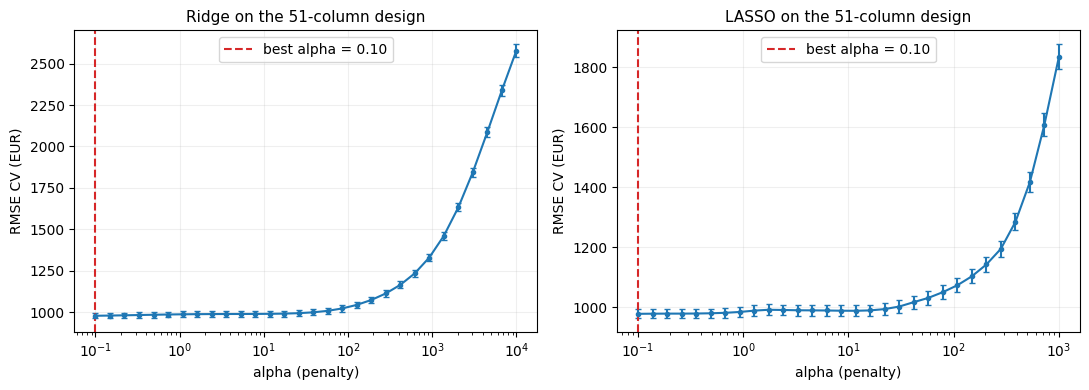

In [139]:
# ============================================================
# The same penalties, on the specification the diagnosis produced
# ============================================================
ridge_grid_f = alpha_curve(lambda a: Ridge(alpha=a), np.logspace(-1, 4, 30),
                           X=X_CHOSEN[COLS_CHOSEN])
lasso_grid_f = alpha_curve(lambda a: Lasso(alpha=a, max_iter=50000), np.logspace(-1, 3, 30),
                           X=X_CHOSEN[COLS_CHOSEN])
best_ridge_f = float(ridge_grid_f.loc[ridge_grid_f["RMSE CV"].idxmin(), "alpha"])
best_lasso_f = float(lasso_grid_f.loc[lasso_grid_f["RMSE CV"].idxmin(), "alpha"])
print(f"best alpha on 45+6 -- Ridge {best_ridge_f:.2f}, LASSO {best_lasso_f:.2f} "
      f"(on the base 45 they were {best_ridge:.2f} and {best_lasso:.2f})")
print(f"LASSO keeps {int(lasso_grid_f.loc[lasso_grid_f['RMSE CV'].idxmin(), 'non-zero coefficients'])} "
      f"of {len(COLS_CHOSEN)} columns at its chosen alpha")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, grid, nm, best in [(ax[0], ridge_grid_f, "Ridge", best_ridge_f),
                          (ax[1], lasso_grid_f, "LASSO", best_lasso_f)]:
    a.errorbar(grid.alpha, grid["RMSE CV"], yerr=grid.SE, marker="o", ms=3, capsize=2)
    a.axvline(best, color="tab:red", ls="--", label=f"best alpha = {best:,.2f}")
    a.set(xscale="log", xlabel="alpha (penalty)", ylabel="RMSE CV (EUR)",
          title=f"{nm} on the 51-column design")
    a.legend(); a.grid(alpha=0.2)
plt.tight_layout(); plt.show()

In [140]:
ridge_f = run_penalised(Ridge(alpha=best_ridge_f), cols=COLS_CHOSEN, X=X_CHOSEN,
                        name="Ridge on 45+6", verbose=False)
lasso_f = run_penalised(Lasso(alpha=best_lasso_f, max_iter=50000), cols=COLS_CHOSEN, X=X_CHOSEN,
                        name="LASSO on 45+6", verbose=False)

show(experiment_table().loc[["forward-selected 6 (45+6)", "Ridge on 45+6", "LASSO on 45+6"],
                            ["k", "RMSE CV", "SE", "MAE CV", "max VIF"]].round(2),
     "Unpenalised against penalised, on the same 51 columns:")

# What the penalty actually did to the collinear cluster, on the standardised scale
COEF_F = pd.DataFrame({
    "OLS":   coef_of(LinearRegression(),                      X_CHOSEN[COLS_CHOSEN], ytr),
    "Ridge": coef_of(Ridge(alpha=best_ridge_f),               X_CHOSEN[COLS_CHOSEN], ytr),
    "LASSO": coef_of(Lasso(alpha=best_lasso_f, max_iter=50000), X_CHOSEN[COLS_CHOSEN], ytr)})
show(COEF_F.reindex(COEF_F.OLS.abs().sort_values(ascending=False).index).head(8).round(1),
     "The largest coefficients under OLS, and what each penalty does to them (EUR per SD):")
print("total absolute coefficient mass:  "
      + "  ".join(f"{c} {COEF_F[c].abs().sum():,.0f}" for c in COEF_F.columns))

Unpenalised against penalised, on the same 51 columns:


,k,RMSE CV,SE,MAE CV,max VIF
run,,,,,
forward-selected 6 (45+6),51,976.240,15.290,752.110,"16,935.780"
Ridge on 45+6,51,980.280,15.890,753.780,"16,935.780"
LASSO on 45+6,51,978.080,15.270,753.170,"16,935.780"


The largest coefficients under OLS, and what each penalty does to them (EUR per SD):


,OLS,Ridge,LASSO
CC,"11,072.800","5,813.200","9,222.400"
log_CC,"-10,317.000","-5,118.800","-8,375.300"
HP,"8,368.600",388.300,"3,521.000"
log_HP,"-8,056.600",-567.200,"-3,525.100"
Fuel_Type_Diesel,"-1,892.300","-1,565.500","-1,855.100"
Age_08_04,"-1,839.900","-1,804.900","-1,832.800"
HP_sq,"-1,315.700",164.000,-429.900
Weight,798.300,732.700,751.800


total absolute coefficient mass:  OLS 48,418  Ridge 20,979  LASSO 34,290


**Finding — neither penalty helps, and cross-validation is blunt about why: it asks for no penalty
at all.**

Both grids bottom out at their smallest value, $\alpha = 0.10$, so the optimum sits **on the
boundary** of the search. On the base 45 predictors it was interior at 11.72, so this is a property
of the richer design and not of the grid. LASSO keeps all 51 columns at that value — at a penalty
that weak it has nothing to remove.

| | k | RMSE CV | MAE CV | max VIF |
|---|---|---|---|---|
| OLS, 45+6 | 51 | **976.2 ± 15.3** | 752.1 | 16,936 |
| LASSO, 45+6 | 51 | 978.1 ± 15.3 | 753.2 | 16,936 |
| Ridge, 45+6 | 51 | 980.3 ± 15.9 | 753.8 | 16,936 |

A 4 € spread against a standard error of 15. On out-of-sample error the three are the same model.

**A5 does not move, exactly as predicted.** Max VIF is 16,936 under all three, because the columns
are identical and a penalty changes only what may be done with them.

**But look at what the penalty does to the coefficients.** Under OLS the design contains pairs that
cancel each other at enormous magnitudes: `CC` at +11,073 € per standard deviation against `log_CC`
at −10,317, and `HP` at +8,369 against `log_HP` at −8,057. Neither pair means anything on its own —
they are two descriptions of one variable, and OLS is free to make them arbitrarily large in
opposite directions because only their sum is identified. Ridge collapses `HP` to 388 and `log_HP`
to −567, and cuts the total absolute coefficient mass from 48,418 € to 20,979 €. LASSO lands between
the two at 34,290 €.

**So what.** Ridge and LASSO do not repair the **diagnostic** — VIF is unchanged — they repair the
**damage**. Two columns cancelling at ±8,000 € become two columns near zero, describing the same
fitted surface with coefficients that a reader could look at without being misled. What
regularisation buys here is not accuracy but the ability to report a number.

**Now what.** All three enter the candidate registry. Under the pre-registered one-SE rule of §1.8,
a penalised model must be *better* than an unpenalised one by more than a standard error to be
preferred, and none of them is — so the rule will favour the simpler OLS unless the holdout says
otherwise. That is tested, not assumed, in the final evaluation.

### 3.9 The candidate registry

Every model built anywhere in this notebook is now scored under a single protocol: the metrics of
§1.8, the paired tests of §3.11, the one-SE rule of §3.12, and a holdout opened once, after the
preferred model has been named.

One record per candidate — the columns it is fitted on, the derived terms it needs, how it is
fitted, and how its coefficients read. Two details matter for correctness:

- **Derived terms are centred on training means everywhere, holdout included.** Centring the holdout
  on its own mean would build a differently-scaled column, and coefficients fitted on the training
  columns would no longer apply to it.
- **The fitters are the same classes §3.1 defined.** A model cannot carry one error in the diagnostic
  table and a different one here, and the OLS-family fits use statsmodels rather than sklearn: on a
  design whose condition number runs into the billions, the two solvers disagree by hundreds of euros.

Three candidates are **not** in the registry, deliberately. The quantile fits at $\tau = 0.1$ and
$\tau = 0.9$ estimate different targets, so ranking them on RMSE against conditional-mean models
would compare answers to different questions. The `CC as 6 engine classes` run was declared in §3.4.4
as evidence about what `CC` measures rather than as a candidate.

In [141]:
# ============================================================
# Final evaluation - infrastructure: the candidate registry and one shared error array
# ============================================================

def design_for(terms, X):
    """Design matrix on any set of rows, with derived terms centred on TRAINING constants.

    `ref=Xtr` is not optional. A square or an interaction is centred on a mean; centring the
    holdout on its own mean would build a differently-scaled column, and the coefficients fitted
    on the training columns would no longer apply to it.
    """
    return X.assign(**build_terms(terms, X, ref=Xtr)) if terms else X


def _candidate_fitter(kind, alpha=None):
    """One calling convention for every estimator: fit(X, y) -> object with .predict in euros.

    The OLS-family, robust and quantile fitters are the classes §3.1 defined, so a model cannot
    carry one error in the diagnostic table and a different one here. Ridge and LASSO go through
    `pipe`, which refits the scaler inside every fold.
    """
    return {"ols":    lambda Xa, ya: _OLSFit(Xa, ya),
            "log":    lambda Xa, ya: _LogOLSFit(Xa, ya),
            "ridge":  lambda Xa, ya: pipe(Ridge(alpha=alpha)).fit(Xa, ya),
            "lasso":  lambda Xa, ya: pipe(Lasso(alpha=alpha, max_iter=50000)).fit(Xa, ya),
            "huber":  lambda Xa, ya: _HuberFit(Xa, ya),
            "median": lambda Xa, ya: _QuantFit(Xa, ya, q=0.5, max_iter=2000)}[kind]


FINALISTS = []


def finalist(name, cols, terms=(), kind="ols", alpha=None, reading=""):
    "Register one candidate: what it is fitted on, how it is fitted, and how its coefficients read."
    FINALISTS.append({"name": name, "cols": list(cols), "terms": list(terms), "kind": kind,
                      "alpha": alpha, "fit": _candidate_fitter(kind, alpha), "k": len(cols),
                      "regularised": kind in ("ridge", "lasso"), "log_target": kind == "log",
                      "reading": reading})


def with_terms(terms, cols=None):
    "Base columns plus the derived columns those terms produce."
    return (list(BASE) if cols is None else list(cols)) + list(build_terms(terms, Xtr))


FINALISTS.clear()
# --- the base design -------------------------------------------------------
finalist("OLS (45)", BASE, reading="EUR per unit, 45 coefficients")
finalist("Ridge (45)", BASE, kind="ridge", alpha=best_ridge,
         reading="EUR per SD, all 45 shrunk, none removed")
finalist("LASSO (45)", BASE, kind="lasso", alpha=best_lasso,
         reading="EUR per SD, 7 set to zero")
finalist(f"forward selection ({len(fwd)})", fwd, reading="EUR per unit, subset chosen on p-values")
finalist(f"backward elimination ({len(bwd)})", bwd, reading="EUR per unit, subset chosen on p-values")
finalist("compact (4)", ["Age_08_04", "KM", "Weight", "HP"],
         reading="four coefficients, all readable")
# --- Remedy 1: the specification -------------------------------------------
finalist(f"forward-selected {len(chosen)} terms (45+{len(chosen)})", with_terms(chosen), terms=chosen,
         reading="squares and interactions: no single coefficient reads alone")
finalist(f"all {len(CANDIDATES)} candidates (45+{len(CANDIDATES)})", with_terms(CANDIDATES),
         terms=CANDIDATES, reading="as above, ten extra terms")
finalist(f"pure powers (45+{len(POLY)})", with_terms(POLY), terms=POLY,
         reading="not interpretable term by term")
finalist(f"VIF-pruned <5 ({len(pi_pruned['_cols'])})", pi_pruned["_cols"], terms=POLY_INT,
         reading="EUR per unit, no collinear cluster, main effects deleted")
# --- Remedy 2: the response ------------------------------------------------
finalist("log(Price) (45)", BASE, kind="log",
         reading="approx. % per unit, euros via Duan smearing")
finalist(f"log(Price) + {len(chosen)} terms (45+{len(chosen)})", with_terms(chosen), terms=chosen,
         kind="log", reading="approx. % per unit, euros via Duan smearing")
# --- Remedy 3: the loss ----------------------------------------------------
finalist("Huber (45)", BASE, kind="huber",
         reading="EUR per unit, badly mispriced cars down-weighted")
finalist(f"Huber (45+{len(chosen)})", with_terms(chosen), terms=chosen, kind="huber",
         reading="as above, on the chosen specification")
finalist(f"Median regression (45+{len(chosen)})", with_terms(chosen), terms=chosen, kind="median",
         reading="EUR per unit, conditional median not mean")
# --- Section 2.5: regularisation on the chosen specification ---------------
finalist(f"Ridge on 45+{len(chosen)}", with_terms(chosen), terms=chosen, kind="ridge",
         alpha=best_ridge_f, reading="EUR per SD, collinear cluster stabilised")
finalist(f"LASSO on 45+{len(chosen)}", with_terms(chosen), terms=chosen, kind="lasso",
         alpha=best_lasso_f, reading="EUR per SD, collinear cluster resolved")

INFO = {f["name"]: f for f in FINALISTS}


def cv_errors(f):
    "Out-of-fold error in euros for every training car, one row per repeat, on the folds of §1.8."
    Xd = design_for(f["terms"], Xtr)[f["cols"]]
    err = np.zeros((3, len(ytr)))
    for k, (a, b) in enumerate(FOLDS):
        m = f["fit"](Xd.iloc[a], ytr.iloc[a])
        err[k // 10, b] = ytr.iloc[b].values - np.asarray(m.predict(Xd.iloc[b]), float)
    return err


def cv_metrics(err):
    "The five metrics of §1.8 from one error array; SE is across the 30 folds."
    fold = np.array([np.sqrt(np.mean(err[k // 10, b] ** 2)) for k, (a, b) in enumerate(FOLDS)])
    return {"RMSE CV": float(np.sqrt(np.mean(err ** 2))),
            "SE": float(fold.std(ddof=1) / np.sqrt(len(FOLDS))),
            "MAE CV": float(np.mean(np.abs(err))),
            "MAPE CV %": float(100 * np.mean(np.abs(err) / ytr.values)),
            "ME CV": float(np.mean(err))}


t0 = time.time()
CV_ERR = {f["name"]: cv_errors(f) for f in FINALISTS}
CV = pd.DataFrame({n: cv_metrics(e) for n, e in CV_ERR.items()}).T
CV.insert(0, "k", [INFO[n]["k"] for n in CV.index])
print(f"{len(FINALISTS)} candidates scored on identical folds in {time.time() - t0:.0f} s")
show(CV.sort_values("RMSE CV").round(2), "Cross-validated metrics, training rows only:")

17 candidates scored on identical folds in 163 s
Cross-validated metrics, training rows only:


,k,RMSE CV,SE,MAE CV,MAPE CV %,ME CV
forward-selected 6 terms (45+6),51,976.240,15.290,752.110,7.570,-0.280
LASSO on 45+6,51,978.080,15.270,753.170,7.580,0.020
Ridge on 45+6,51,980.280,15.890,753.780,7.600,-0.340
all 10 candidates (45+10),55,982.240,15.840,751.170,7.550,-1.340
Huber (45+6),51,983.090,16.450,752.090,7.560,-0.520
log(Price) + 6 terms (45+6),51,"1,042.200",17.720,785.560,7.720,-9.410
backward elimination (21),21,"1,044.040",20.130,781.020,7.930,-0.920
forward selection (18),18,"1,057.910",21.690,781.870,7.910,0.010
LASSO (45),45,"1,061.410",21.060,788.880,8.010,-0.890
Ridge (45),45,"1,064.900",20.620,791.670,8.040,-1.360


### 3.10 Choice of evaluation metrics — their meaning and their limitations

§1.8 fixed RMSE as the primary metric before any model was fitted. The others are reported alongside
it and never decide, but each one answers a question RMSE cannot.

- **RMSE** (primary) — dominated by the largest misses, because errors are squared before averaging.
  That is the right emphasis for a dealer, for whom one car mispriced by 5,000 € matters more than
  ten mispriced by 500. It is the wrong emphasis if a few cars are simply recorded wrong, which is
  why Id 605 gets a sensitivity check of its own.
- **MAE** — every car weighted equally. This is the fair yardstick for median regression, which
  minimises absolute error by construction; scoring it on RMSE alone would judge it on a criterion
  it never optimised.
- **MAPE** — comparable across price levels, and unstable at the cheap end. A 500 € miss is 11% on a
  4,350 € car and 1.5% on a 32,500 € one, so MAPE is pulled around by the cheapest cars in the file.
- **ME** — bias, not accuracy. It should sit near zero, and a large value means the model is
  systematically wrong in one direction, which no accuracy metric would reveal. It is the check that
  caught the missing Duan correction in §3.5.
- **R² on the holdout** — the share of price variation the model accounts for on cars it never saw.
  Readable as a single summary, and the weakest of the five for choosing between models: it is unitless,
  so it cannot say what an error costs, and it rises mechanically with the number of parameters, which
  is precisely the axis the candidates here differ on. Reported in §3.13 and §3.15, never decisive.

All five are computed from the **same** out-of-fold error array per model, so no metric can disagree
with another about which predictions were made.

### 3.11 Paired tests: is the difference real?

The top five candidates are separated by 7 € on a scale where the standard error is 15. A ranking
alone cannot say whether that is a difference or noise, so the models are compared directly.

**Why the test is paired.** Every candidate produced an out-of-fold prediction for the *same* car, so
the two error sets are matched car by car. An unpaired comparison would treat the fact that a
particular car is hard to price for both models as noise; pairing removes that shared variance and
leaves only the difference between the models. Here the between-car spread is far larger than the
between-model spread, so the paired form is much more sensitive.

**Why the pair is the car and not the fold.** Repeated 10-fold CV produces 30 folds that reuse the
same 857 observations. Treating them as 30 independent measurements would understate the standard
error and manufacture significance.

**Why Wilcoxon and not a paired t-test.** Per-car absolute errors are bounded below at zero and
strongly right-skewed, so their differences are not close to normal. The Wilcoxon signed-rank test
ranks the absolute differences and asks whether the median difference is zero. It assumes nothing
about the distribution and loses very little power when normality does hold.

**Why the Holm correction.** Comparing $m$ candidates against one reference means $m$ tests. At
$\alpha = 0.05$ each, the probability of at least one false "significant difference" is
$1 - 0.95^m$ — with sixteen comparisons, about **56%**. Holm sorts the p-values ascending and
compares the $k$-th smallest against $\alpha/(m - k + 1)$, stopping at the first non-rejection,
which holds the probability of *any* false positive at 5% across the whole family — and does so
without assuming the tests are independent, which matters here because the candidates share folds
and overlap in predictors.

**Why Holm rather than Bonferroni or Benjamini–Hochberg.** Holm dominates Bonferroni: it rejects
everything Bonferroni rejects and sometimes more, at the same guarantee, so there is no reason to
prefer the weaker rule. Benjamini–Hochberg controls a different quantity — the expected *share* of
false discoveries — which suits screening hundreds of hypotheses for follow-up. Here the family is
small and the cost of one wrong claim that a model is superior is exactly what must be avoided, so
controlling the family-wise error rate is the right target.

In [142]:
# ============================================================
# Paired Wilcoxon on per-car absolute error, Holm-corrected across the family
# ============================================================
def paired_tests(reference):
    """Wilcoxon signed-rank against one reference model, Holm-corrected across the family.

    The pair is the car, not the fold: each candidate produced an out-of-fold prediction for every
    training car, so the absolute errors of two models are matched observation by observation and
    averaged over the three repeats.
    """
    ref = np.abs(CV_ERR[reference]).mean(axis=0)
    rows = []
    for f in FINALISTS:
        if f["name"] == reference:
            continue
        other = np.abs(CV_ERR[f["name"]]).mean(axis=0)
        rows.append({"model": f["name"],
                     "mean |error| - reference": float(other.mean() - ref.mean()),
                     "cars it predicts better": int((other < ref).sum()),
                     "Wilcoxon p": float(st.wilcoxon(ref, other).pvalue)})
    t = pd.DataFrame(rows)
    t["Holm p"] = holm(t["Wilcoxon p"].values)
    t["verdict"] = np.where(t["Holm p"] < 0.05, "differs", "indistinguishable")
    return t.set_index("model").sort_values("mean |error| - reference")


BEST_CV = CV["RMSE CV"].idxmin()
print(f"reference = lowest CV RMSE: {BEST_CV} ({CV.loc[BEST_CV, 'RMSE CV']:,.1f} EUR), "
      f"n = {len(ytr)} paired cars")
show(paired_tests(BEST_CV).round(4), f"Paired comparison against {BEST_CV}:")

reference = lowest CV RMSE: forward-selected 6 terms (45+6) (976.2 EUR), n = 857 paired cars
Paired comparison against forward-selected 6 terms (45+6):


,mean |error| - reference,cars it predicts better,Wilcoxon p,Holm p,verdict
model,,,,,
all 10 candidates (45+10),-0.940,434,0.380,1.000,indistinguishable
Huber (45+6),-0.020,428,0.589,1.000,indistinguishable
LASSO on 45+6,1.054,414,0.532,1.000,indistinguishable
Ridge on 45+6,1.669,419,0.569,1.000,indistinguishable
backward elimination (21),28.902,403,0.033,0.267,indistinguishable
forward selection (18),29.759,398,0.051,0.309,indistinguishable
log(Price) + 6 terms (45+6),33.447,411,0.038,0.267,indistinguishable
LASSO (45),36.764,403,0.014,0.125,indistinguishable
Huber (45),38.111,383,0.003,0.039,differs


**Finding — the ranking is mostly noise at the top and real at the bottom.**

Against the lowest-CV model, the six nearest candidates are **statistically indistinguishable** after
correction: the ten-term design, Huber on the same specification, LASSO and Ridge on it, backward
elimination and forward selection. So is the log model. Four are separated by under 2 € of mean
absolute error and win on roughly half the cars — 434 of 857 for the ten-term design, 428 for Huber.

**Six candidates do differ**: plain OLS on the 45 base predictors (+43 €), Ridge and Huber on the
same base, pure powers (+65 €), median regression (+88 €), the compact specification (+207 €) and
the VIF-pruned design (+298 €).

**So what — the correction changes the reading.** `backward elimination` has an uncorrected p-value
of 0.033 and `log(Price) + 6 terms` one of 0.038: both would have been called significant at 5% in
isolation. After Holm they are 0.267 — comfortably indistinguishable. Two claims of superiority that
survive as artefacts of running sixteen tests, and the correction is what removes them.

**Now what.** The data cannot separate the top of the table, so the choice cannot be made on error
alone. §3.12 applies the pre-registered rule that was fixed for exactly this situation.

### 3.12 The one-SE rule, and closing the list

§3.11 established that the data cannot separate the top of the table. §1.8 fixed the rule for
exactly this situation, before any model existed: the lowest CV RMSE **plus one standard error**
defines a band of candidates the evidence cannot distinguish, and inside that band a pre-declared
simplicity order decides — fewer estimated parameters first, then no transformation of the target,
then no regularisation.

The rule exists to remove a specific degree of freedom. Without it, an analyst who has seen the
table can always find a defensible reason to prefer whichever model they liked to begin with.

The list is then hashed and closed. Nothing may be added afterwards.

In [143]:
# ============================================================
# The one-SE rule: the simplest candidate within one standard error of the best
# ============================================================
def one_se_choice(tab=None):
    """Apply §1.8 and return (preferred model, the band it was chosen from, the ceiling).

    Lowest CV RMSE plus one standard error of that model's fold-level RMSE defines a band of
    candidates the data cannot separate. Inside it the pre-declared order decides: fewer estimated
    parameters, then no target transformation, then no regularisation, then lowest error.
    """
    tab = CV if tab is None else tab
    best = tab["RMSE CV"].idxmin()
    ceiling = tab.loc[best, "RMSE CV"] + tab.loc[best, "SE"]
    band = tab[tab["RMSE CV"] <= ceiling].copy()
    band["parameters"]  = [INFO[n]["k"] + 1 for n in band.index]
    band["log target"]  = [INFO[n]["log_target"] for n in band.index]
    band["regularised"] = [INFO[n]["regularised"] for n in band.index]
    band = band.sort_values(["parameters", "log target", "regularised", "RMSE CV"])
    return band.index[0], band, ceiling


PREFERRED, BAND, CEILING = one_se_choice()
print(f"best CV RMSE: {CV['RMSE CV'].min():,.1f} EUR ({CV['RMSE CV'].idxmin()}); "
      f"one-SE ceiling: {CEILING:,.1f} EUR -> {len(BAND)} candidates inside the band")
show(BAND[["k", "parameters", "RMSE CV", "SE", "log target", "regularised"]].round(1),
     "Inside one standard error of the best, ordered by the pre-declared simplicity rule:")

LOCK = hashlib.sha256(json.dumps({f["name"]: sorted(f["cols"]) for f in FINALISTS},
                                 sort_keys=True).encode()).hexdigest()[:16]
print(f"\ncandidate list closed: {len(FINALISTS)} models, hash {LOCK}")
print(f"PREFERRED MODEL (named before the holdout is opened): {PREFERRED}")

best CV RMSE: 976.2 EUR (forward-selected 6 terms (45+6)); one-SE ceiling: 991.5 EUR -> 5 candidates inside the band
Inside one standard error of the best, ordered by the pre-declared simplicity rule:


,k,parameters,RMSE CV,SE,log target,regularised
forward-selected 6 terms (45+6),51,52,976.200,15.300,False,False
Huber (45+6),51,52,983.100,16.400,False,False
LASSO on 45+6,51,52,978.100,15.300,False,True
Ridge on 45+6,51,52,980.300,15.900,False,True
all 10 candidates (45+10),55,56,982.200,15.800,False,False



candidate list closed: 17 models, hash 84a7fc4856e76d72
PREFERRED MODEL (named before the holdout is opened): forward-selected 6 terms (45+6)


**Finding.** The ceiling is 991.5 €, and **five candidates** fall inside it: the forward-selected six
terms (976.2), LASSO on the same design (978.1), Ridge on it (980.3), the ten-candidate design
(982.2) and Huber on it (983.1).

The order resolves cleanly. Four of the five estimate 52 parameters and one estimates 56, which
eliminates the ten-term design at the first criterion — even though it is the only specification in
the notebook that satisfies A2 outright. None uses a log target. Ridge and LASSO are regularised and
fall at the third criterion. That leaves the forward-selected six terms and Huber on the same
columns, tied on all three, and the tiebreak of lowest CV error selects the first.

**Preferred model: `forward-selected 6 terms (45+6)`**, named here, with the candidate list hashed
and closed.

### 3.13 The holdout, opened once

572 cars untouched since §1.6. Every candidate is scored, for transparency about what the whole
field does out of sample — but the preferred model was named in the cell above, before this one ran.

**A model that wins here is not re-crowned.** §1.8 fixed that rule, and it is the one that makes the
holdout a measurement rather than a second selection round. Choosing the holdout winner after the
fact would convert 572 protected cars into just another validation set, and there would be nothing
left to measure honestly against.

In [144]:
# ============================================================
# The holdout: 572 cars untouched since 1.6, scored once
# ============================================================
def holdout_scores():
    "Fit each candidate on all training rows and score it once on the held-out cars."
    rows = []
    for f in FINALISTS:
        Xa = design_for(f["terms"], Xtr)[f["cols"]]
        Xb = design_for(f["terms"], Xho)[f["cols"]]
        m = f["fit"](Xa, ytr)
        p = np.asarray(m.predict(Xb), float)
        rows.append({"model": f["name"], "k": f["k"],
                     "RMSE holdout": rmse(yho, p), "MAE holdout": mae(yho, p),
                     "MAPE holdout %": mape(yho, p), "ME holdout": me(yho, p),
                     "R2 holdout": 1 - float(np.sum((yho - p) ** 2) / np.sum((yho - yho.mean()) ** 2))})
    return pd.DataFrame(rows).set_index("model")


HO = holdout_scores()
show(HO.sort_values("RMSE holdout").round(2), f"Holdout, n = {len(yho)}, scored once (hash {LOCK}):")

rank = pd.DataFrame({"RMSE CV": CV["RMSE CV"].round(1),
                     "RMSE holdout": HO["RMSE holdout"].round(1)})
rank["optimism (holdout - CV)"] = (rank["RMSE holdout"] - rank["RMSE CV"]).round(1)
show(rank.sort_values("RMSE CV"), "How much of the cross-validated performance survived:")
print(f"rank correlation CV vs holdout: "
      f"{st.spearmanr(CV['RMSE CV'], HO.loc[CV.index, 'RMSE holdout']).statistic:.3f}")

Holdout, n = 572, scored once (hash 84a7fc4856e76d72):


,k,RMSE holdout,MAE holdout,MAPE holdout %,ME holdout,R2 holdout
model,,,,,,
all 10 candidates (45+10),55,"1,082.130",813.070,8.110,106.660,0.900
Ridge on 45+6,51,"1,086.360",816.750,8.170,100.900,0.900
Huber (45+6),51,"1,086.450",815.120,8.150,105.140,0.900
forward-selected 6 terms (45+6),51,"1,088.640",819.670,8.200,102.710,0.900
LASSO on 45+6,51,"1,088.760",818.590,8.180,101.610,0.900
log(Price) (45),45,"1,091.370",808.460,8.000,89.380,0.900
log(Price) + 6 terms (45+6),51,"1,098.350",811.100,8.030,100.370,0.900
Ridge (45),45,"1,119.430",842.710,8.360,86.260,0.900
LASSO (45),45,"1,120.810",841.380,8.350,84.760,0.900


How much of the cross-validated performance survived:


,RMSE CV,RMSE holdout,optimism (holdout - CV)
forward-selected 6 terms (45+6),976.200,"1,088.600",112.400
LASSO on 45+6,978.100,"1,088.800",110.700
Ridge on 45+6,980.300,"1,086.400",106.100
all 10 candidates (45+10),982.200,"1,082.100",99.900
Huber (45+6),983.100,"1,086.500",103.400
log(Price) + 6 terms (45+6),"1,042.200","1,098.400",56.200
backward elimination (21),"1,044.000","1,128.900",84.900
forward selection (18),"1,057.900","1,135.500",77.600
LASSO (45),"1,061.400","1,120.800",59.400
Ridge (45),"1,064.900","1,119.400",54.500


rank correlation CV vs holdout: 0.850


**Finding — the preferred model comes fourth, by 6 €.**

On the holdout: the ten-candidate design leads at 1,082.1 €, then Ridge on the chosen terms
(1,086.4), Huber on them (1,086.5), the **preferred model at 1,088.6**, and LASSO at 1,088.8. Five
models within 7 € of each other on 572 cars. Under §1.8 that is not a re-crowning — the paired tests
had already called these four indistinguishable, and the gap is a fraction of a standard error. The
preferred model records R² = 0.900, MAE = 819.7 €, MAPE = 8.2%.

**The rank correlation between cross-validation and holdout is 0.850**, so the protocol ranked the
field well even where it could not separate the top of it.

**The optimism is now measured, and it is a cost of selection.** The five specifications whose terms
or columns were *chosen* on the cross-validation folds lose **100–112 €** between CV and holdout.
Models that selected nothing lose far less: plain OLS on the 45 base predictors loses 56 €, Ridge
54 €, and `log(Price)` on the base design only **26 €** — the smallest optimism of any candidate.
That difference is the price of having looked at the folds, quantified rather than asserted, and it
is exactly why §3.4.3 flagged its own numbers as optimistic when they were produced.

**One blemish, and it is systematic.** Every candidate under-prices the holdout: mean error runs
from +81 € to +109 € against near-zero bias in cross-validation. On 572 cars that is roughly two
standard errors, and it appears under every estimator and every specification, so it is a property
of the split rather than of any one model. It is reported as a limitation, not explained away.

### 3.14 Sensitivity checks

§1.8 required that every sensitivity check change real rows and report $n$ before and after. The
three exclusions from Part A are put back: the two suspected-mileage cars, the two suspected-weight
cars, and the five Verso rows.

Each is scored by cross-validation **inside the modified training set** and never on the holdout, so
the holdout stays the single measurement it was declared to be. The `Weight` coefficient is carried
alongside, because §1.3 promised exactly that number as the test of the weight audit.

In [145]:
# ============================================================
# Sensitivity: every check changes real rows and reports n before and after
# ============================================================
def _reprep(rows):
    """"Re-apply the Part A derivations to rows set aside before those columns existed.

    `verso` was copied out in 1.2 and `weight_suspects` in 1.3 - both before the CC correction, the
    Color merge, Trim/Body and the split indicator were created. They cannot simply be concatenated
    back; the same rules have to be applied to them first.
    """
    d = rows.copy()
    d["Model"] = d.Model.astype(str)
    d.loc[d.CC == 16000, "CC"] = 1600
    d["km_suspect"] = ((d.KM <= 1) & (d.Age_08_04 > 24)).astype(int)
    d["weight_suspect"] = 0
    d["Trim"] = d.Model.map(extract_trim)
    d["Body"] = d.Model.map(extract_body)
    d["Color"] = d.Color.replace({"Violet": "Other", "Yellow": "Other", "Beige": "Other"})
    d["split"] = "train"
    return d.drop(columns=[c for c in ("weight_z",) if c in d.columns])


def _cv_fresh(f, Xd, yv):
    "The same protocol on a different number of rows: fresh 10-fold x 3 at the same seed."
    folds = list(RepeatedKFold(n_splits=10, n_repeats=3, random_state=SEED).split(Xd))
    err = np.zeros((3, len(yv)))
    for k, (a, b) in enumerate(folds):
        m = f["fit"](Xd.iloc[a], yv.iloc[a])
        err[k // 10, b] = yv.iloc[b].values - np.asarray(m.predict(Xd.iloc[b]), float)
    return float(np.sqrt(np.mean(err ** 2)))


def sensitivity(name=None):
    "Re-run the three Part A exclusions on the preferred model and report the damage."
    f = INFO[name or PREFERRED]

    def score(frame, label, changed):
        m = (frame.split == "train").values
        Xa = design(frame).reindex(columns=BASE, fill_value=0.0)[m]
        ya = frame.Price.astype(float)[m]
        Xa = design_for(f["terms"], Xa)[f["cols"]]
        w = sm.OLS(ya, add_const(Xa)).fit().params.get("Weight", np.nan)
        return {"check": label, "rows changed": changed, "n train": int(m.sum()),
                "RMSE CV": _cv_fresh(f, Xa, ya), "Weight coef (EUR/kg)": float(w)}

    rows = [score(df, "main analysis", "-"),
            score(df[df.km_suspect == 0], "drop suspected mileage", "Ids 605, 1442 removed"),
            score(pd.concat([df, _reprep(weight_suspects)], ignore_index=True),
                  "re-include suspected weight", "Ids 223, 964 added"),
            score(pd.concat([df, _reprep(verso)], ignore_index=True),
                  "re-include Verso", "5 MPV rows added")]
    t = pd.DataFrame(rows).set_index("check")
    t["RMSE CV vs main"] = (t["RMSE CV"] - t.loc["main analysis", "RMSE CV"]).round(1)
    return t


SENS = sensitivity()
show(SENS.round(2), f"Sensitivity of the preferred model ({PREFERRED}):")

Sensitivity of the preferred model (forward-selected 6 terms (45+6)):


,rows changed,n train,RMSE CV,Weight coef (EUR/kg),RMSE CV vs main
check,,,,,
main analysis,-,857,976.240,17.360,0.000
drop suspected mileage,"Ids 605, 1442 removed",855,967.380,18.800,-8.900
re-include suspected weight,"Ids 223, 964 added",859,"1,078.060",2.970,101.800
re-include Verso,5 MPV rows added,862,978.720,16.740,2.500


**Finding — of the three Part A decisions was load-bearing, and it is the one that was hardest
to justify.**

| Check | n train | RMSE CV | vs main | `Weight` (€/kg) |
|---|---|---|---|---|
| main analysis | 857 | 976.2 | — | 17.36 |
| drop suspected mileage (Ids 605, 1442) | 855 | 967.4 | **−8.9** | 18.80 |
| re-include suspected weight (Ids 223, 964) | 859 | 1,078.1 | **+101.8** | **2.97** |
| re-include Verso (5 rows) | 862 | 978.7 | +2.5 | 16.74 |

**Verso costs 2.5 €.** Excluding five MPV rows changed almost nothing in prediction, which means the
decision in §1.2 was defensible on its own grounds — a population definition — rather than a
convenient improvement. That is the honest reading: the exclusion was right for a reason that has
nothing to do with the number.

**The two suspected-mileage cars are, if anything, worth removing.** Deleting them *improves* error
by 8.9 €. §1.2 kept them because nothing in the record proves them wrong, and that decision costs
under 9 € — a defensible price for not deleting data on suspicion.

**The two suspected-weight records are the finding.** Putting them back costs **102 €**, more than a
tenth of the model's total error, and collapses the `Weight` coefficient from **17.4 € per kg to
2.97** — two records out of 859 nearly erase one of the strongest relationships in the data. The
5 SD rule declared in §1.3, before the result was inspected, is what caught them, and this table is
its vindication. It also shows how fragile a coefficient can be to a pair of data-entry errors, which
is a general point worth more than the specific one.

### 3.15 Every model on one page

Performance in and out of sample, complexity as the number of estimated parameters, and
interpretability as what a coefficient actually says — the three axes the assignment asks models to
be compared on.

In [146]:
FINAL = pd.concat([CV[["k", "RMSE CV", "SE", "MAE CV", "MAPE CV %"]],
                   HO[["RMSE holdout", "MAE holdout", "MAPE holdout %", "ME holdout", "R2 holdout"]]],
                  axis=1)
FINAL.insert(1, "parameters", [INFO[n]["k"] + 1 for n in FINAL.index])
FINAL["how the coefficients read"] = [INFO[n]["reading"] for n in FINAL.index]
show(FINAL.sort_values("RMSE CV").round(2), "Every candidate, in and out of sample:")

Every candidate, in and out of sample:


,k,parameters,RMSE CV,SE,MAE CV,MAPE CV %,RMSE holdout,MAE holdout,MAPE holdout %,ME holdout,R2 holdout,how the coefficients read
forward-selected 6 terms (45+6),51,52,976.240,15.290,752.110,7.570,"1,088.640",819.670,8.200,102.710,0.900,squares and interactions: no single coefficien...
LASSO on 45+6,51,52,978.080,15.270,753.170,7.580,"1,088.760",818.590,8.180,101.610,0.900,"EUR per SD, collinear cluster resolved"
Ridge on 45+6,51,52,980.280,15.890,753.780,7.600,"1,086.360",816.750,8.170,100.900,0.900,"EUR per SD, collinear cluster stabilised"
all 10 candidates (45+10),55,56,982.240,15.840,751.170,7.550,"1,082.130",813.070,8.110,106.660,0.900,"as above, ten extra terms"
Huber (45+6),51,52,983.090,16.450,752.090,7.560,"1,086.450",815.120,8.150,105.140,0.900,"as above, on the chosen specification"
log(Price) + 6 terms (45+6),51,52,"1,042.200",17.720,785.560,7.720,"1,098.350",811.100,8.030,100.370,0.900,"approx. % per unit, euros via Duan smearing"
backward elimination (21),21,22,"1,044.040",20.130,781.020,7.930,"1,128.890",849.740,8.450,84.820,0.900,"EUR per unit, subset chosen on p-values"
forward selection (18),18,19,"1,057.910",21.690,781.870,7.910,"1,135.510",861.740,8.580,82.880,0.900,"EUR per unit, subset chosen on p-values"
LASSO (45),45,46,"1,061.410",21.060,788.880,8.010,"1,120.810",841.380,8.350,84.760,0.900,"EUR per SD, 7 set to zero"
Ridge (45),45,46,"1,064.900",20.620,791.670,8.040,"1,119.430",842.710,8.360,86.260,0.900,"EUR per SD, all 45 shrunk, none removed"


### 3.16 The preferred model, and what it is worth

**Chosen: `forward-selected 6 terms (45+6)`** — the 45 base predictors plus `log_CC`,
`Age×Weight`, `Age×KM`, `log_KM`, `log_HP` and `HP²`, fitted by ordinary least squares. Lowest CV
error at 976.2 ± 15.3 €; the one-SE band held five candidates and the pre-declared order selected
this one. Named before the holdout opened, candidate list hashed.

**Out of sample it achieves RMSE 1,088.6 €, MAE 819.7 €, MAPE 8.2%, R² = 0.900** on 572 cars it had
never seen — placing fourth in a field where the top five are separated by 7 €.

**What it does well.** It predicts a used Corolla's price to within about 8% on average. It is the
only line of attack in the notebook that improved prediction materially: 91 € over the 45-predictor
baseline, roughly four standard errors, achieved by six terms that the diagnosis specifically pointed
to.

**What it cannot do — three limitations, all measured rather than asserted.**

1. **No coefficient reads on its own.** Accuracy was bought with squares and interactions, and max
   VIF is 16,936: `CC` and `log_CC` sit at +11,073 and −10,317 € per standard deviation, cancelling.
   Only the fitted surface is identified, not its parts. §2.5 showed Ridge can restore readable
   coefficients at a cost of 4 €, and that is the model to use if a coefficient must be quoted.
2. **A3 fails, so its standard errors are wrong.** No specification in nineteen made
   Breusch–Pagan stop rejecting. Every statement of significance around this model uses HC3, where
   the correction inflates standard errors by a median of 1.18× and up to 2.43×, and moves four
   coefficients out of significance.
3. **One coefficient, one market.** §3.6.1 showed the age penalty is 120 € per month at the premium
   end of the price distribution against 102 € at the median — a difference of about 2.7 standard
   errors, the only one of the three variables tested that separates. A conditional-mean model
   reports a single number, −104 €, which understates the premium segment by roughly 16%. For a
   dealer pricing well-kept cars, that gap is real money; across the rest of the market the single
   coefficient is accurate.

**The honest summary.** Cross-validation could not separate the top five candidates and the holdout
could not either, so the choice rests on a rule fixed in advance rather than on evidence of
superiority. What the diagnosis bought is not a better model — it is knowing precisely what this
model can and cannot be asked.

**Now what.** Part D changes the question entirely: not what price to predict, but what a single
vehicle characteristic *causes* the price to be — and why nothing in this notebook, including the
model just chosen, licenses that claim.

## Part D — From prediction to causal inference

Parts A–C asked one question: how accurately can the price of a Corolla be predicted? Part D
asks a different one. Suppose the goal were not prediction but the **effect** of a single feature
on price. The feature chosen here is `Automatic_airco` — digital climate control, an option
specified at the factory. It is a clean choice: binary, present in the base design matrix since
1.7, and plausibly something a seller could imagine "adding" to a car.

### 4.1 Why the prediction model does not license a causal reading

**The quantity we would want.** Every car has two potential prices: $Y_i(1)$, its price with the
option, and $Y_i(0)$, its price without it. The effect for that car is $\tau_i = Y_i(1) - Y_i(0)$.
Only one of the two is ever observed — the other is the **counterfactual**, and it is missing by
construction. The target is therefore an average over the cars that actually have the option:

$$ATT = \mathbb{E}\!\left[\,Y_i(1) - Y_i(0) \mid D_i = 1\,\right], \qquad D_i = \texttt{Automatic\_airco}$$

**What the data offers instead.** The observed gap between the two groups decomposes exactly:

$$\underbrace{\mathbb{E}[Y \mid D=1] - \mathbb{E}[Y \mid D=0]}_{\text{what we can compute}}
= \underbrace{\mathbb{E}[Y(1) - Y(0) \mid D=1]}_{ATT}
+ \underbrace{\mathbb{E}[Y(0) \mid D=1] - \mathbb{E}[Y(0) \mid D=0]}_{\text{selection bias}}$$

The second term asks what the cars *with* the option would have been worth *without* it, compared
to the cars that never had it. It vanishes only if the two groups are otherwise alike — the
*ceteris paribus* condition. Random assignment is what makes it vanish. Nothing randomised this
option: it was specified at the factory in 2002, on cars the manufacturer already intended for the
upper end of the range. A randomised trial would settle the question and is not available to us.

**One clarification worth making explicitly.** The split in 1.6 *was* random — cars were allocated
to training and holdout at random, stratified on price deciles. That randomisation makes the two
**evaluation sets** comparable to each other. It says nothing whatever about whether cars **with**
the option are comparable to cars **without** it. The split was randomised; the treatment was not.

**And the model was built to answer a different question.** Every decision in Part C was scored on
out-of-sample RMSE. A column entered a specification because it improved prediction, never because
it closed a confounding path. Under that rule a variable may be kept, dropped, or have its sign
reversed for reasons that have nothing to do with the effect we now want to read off it. The table
below puts that claim to the test on the treatment variable itself.

**Sample.** From here on the full analysis set is used ($n = 1{,}429$), not the training rows. No
model is being selected in Part D, and the holdout was already opened in 3.13 — so restricting the
sample would protect nothing and would only cost precision. Derived terms remain centred on the
training constants, as everywhere else.

In [147]:
# ============================================================
# 4.1  What the treatment coefficient is worth, per specification
#      Same estimator, same data, five defensible column sets - one variable read five ways.
# ============================================================
D  = "Automatic_airco"
XD = design_for(TERMS_CHOSEN, X)          # all rows; derived terms centred on TRAINING constants

n1, n0 = int(df[D].sum()), int((1 - df[D]).sum())
print(f"treated {n1} cars vs {n0} untreated ({df[D].mean():.1%} of {len(df)}); "
      f"median price {df.loc[df[D] == 1, 'Price'].median():,.0f} EUR vs "
      f"{df.loc[df[D] == 0, 'Price'].median():,.0f} EUR")

def treatment_coef(cols, name):
    "OLS with HC3 standard errors; report the treatment coefficient only."
    cols = list(cols)
    if D not in cols:                      # a predictive procedure may simply discard it
        return {"specification": f"{name} - treatment not selected", "k": len(cols),
                "coef (EUR)": np.nan, "HC3 SE": np.nan, "p": np.nan}
    m = sm.OLS(y, add_const(XD[cols])).fit(cov_type="HC3")
    return {"specification": name, "k": len(cols), "coef (EUR)": m.params[D],
            "HC3 SE": m.bse[D], "p": m.pvalues[D]}

TC = [treatment_coef([D],         "raw gap - no controls"),
      treatment_coef(BASE,        "OLS, all 45"),
      treatment_coef(fwd,         f"forward selection ({len(fwd)})"),
      treatment_coef(COLS_CHOSEN, "OLS, 45+6 - the preferred specification")]

# LASSO scales inside the pipeline, so its coefficient is per SD; divide by the column's SD to read euros.
lp   = pipe(Lasso(alpha=best_lasso, max_iter=50000)).fit(XD[BASE], y)
j    = BASE.index(D)
TC.append({"specification": "LASSO (45) - shrunk", "k": int((lp.named_steps["model"].coef_ != 0).sum()),
           "coef (EUR)": lp.named_steps["model"].coef_[j] / lp.named_steps["scale"].scale_[j],
           "HC3 SE": np.nan, "p": np.nan})

show(pd.DataFrame(TC).set_index("specification").round({"coef (EUR)": 0, "HC3 SE": 0, "p": 3}),
     f"What '{D}' is worth, according to each specification (full sample, HC3):")

treated 76 cars vs 1353 untreated (5.3% of 1429); median price 19,225 EUR vs 9,750 EUR
What 'Automatic_airco' is worth, according to each specification (full sample, HC3):


,k,coef (EUR),HC3 SE,p
specification,,,,
raw gap - no controls,1,"8,622.000",396.000,0.000
"OLS, all 45",45,"1,826.000",284.000,0.000
forward selection (18),18,"1,975.000",242.000,0.000
"OLS, 45+6 - the preferred specification",51,"1,210.000",266.000,0.000
LASSO (45) - shrunk,37,"1,881.000",NaN,NaN


**Finding — the controls absorb four-fifths of the gap, and what is left depends on which
controls you pick.** Cars with digital climate control sell for **8,622 €** more than cars
without it. Adding the 45 base predictors removes **6,796 €** of that, or 79%, leaving 1,826 €.
The remainder is not a stable number: forward selection reads it as 1,975 €, LASSO as 1,881 €,
and the specification this notebook selected as its preferred model — the one with the best
cross-validated RMSE — reads it as **1,210 €**. The spread between the highest and lowest
adjusted estimate is 765 €, roughly three times either HC3 standard error. Those standard errors
describe sampling variability *at a fixed specification*; they say nothing about the variation
across the four, which is why the four confidence intervals do not overlap in the way their widths
suggest they should. Every one of the four specifications was defensible on its own terms, and
every one of them was chosen on predictive grounds.

**So What.** The 79% that the controls absorbed is selection bias made visible: it is the part of
the raw gap explained by the fact that cars with this option are systematically different cars —
younger, better equipped, higher trim — not by the option itself. That is exactly the second term
of the decomposition above. The remaining 1,210–1,975 € is *not* thereby the causal effect; it is
whatever association survives after conditioning on one

### 4.2 Possible sources of bias

4.1 left one question open: is any of those adjusted numbers the effect? Reading a regression
coefficient as a causal effect requires two conditions, and neither is a statistical property of
the fit — both are claims about how the world assigned the option.

1. **Conditional ignorability.** Among cars alike on the measured covariates, whether a car has
   digital climate control is as good as random: $\;\{Y_i(1), Y_i(0)\} \perp D_i \mid \mathbf{X}_i$.
2. **Common support (positivity).** In every region of $\mathbf{X}$ that we use, both kinds of car
   actually exist: $\;0 < P(D_i = 1 \mid \mathbf{X}_i) < 1$.

Condition 2 is checkable in the data and is examined first, because if it fails the first condition
never gets its turn. Condition 1 is not checkable at all — but its *failure* leaves a measurable
signature, which is what the balance table and the bias decomposition below are for. Two further
sources of bias are structural and cannot be tested with this file at all; they close the section.

In [148]:
# ============================================================
# 4.2a  Common support: is there anyone to compare with?
# ============================================================
sup = (df.assign(treated=df[D]).groupby("Trim")
         .agg(n=("Price", "size"), treated=("treated", "sum"), rate=("treated", "mean"),
              median_price=("Price", "median"), median_age=("Age_08_04", "median")))
sup.insert(2, "untreated", sup.n - sup.treated)
show(sup.round(3), "Treated and untreated cars, within each trim level:")

dead = sup.loc[sup.treated == 0, "n"].sum()
print(f"cars sitting in a trim stratum that contains no treated car at all: {int(dead)} "
      f"({dead / len(df):.0%} of the sample) - no comparison is possible for them")

Treated and untreated cars, within each trim level:


,n,treated,untreated,rate,median_price,median_age
Trim,,,,,,
LUNA,218,4,214,0.018,"9,900.000",63.000
SOL,143,55,88,0.385,"13,500.000",40.000
TERRA,896,2,894,0.002,"9,000.000",63.000
Unknown,172,15,157,0.087,"10,350.000",58.000


cars sitting in a trim stratum that contains no treated car at all: 0 (0% of the sample) - no comparison is possible for them


**Finding — positivity survives on paper and fails in practice.** No trim stratum is empty: every
level contains at least one treated car, so $0 < P(D=1 \mid \text{Trim}) < 1$ holds everywhere and
the condition is not formally violated. What the counts show instead is concentration. `SOL` is 10%
of the sample and carries **55 of the 76 treated cars — 72%**. Outside `SOL` the entire treated
group is 21 cars: 15 with an unidentified trim, 4 `LUNA`, and **2 `TERRA` out of 896**. The
treatment rate runs from 0.2% to 38.5% across four levels of a single covariate.

**So What.** The estimate is not built from 1,429 comparisons. It is built from a comparison inside
`SOL` — 55 treated against 88 untreated — plus an extrapolation across the remaining 1,286 cars
that rests on 21 treated observations. Where a stratum holds two treated cars, the model is not
comparing; it is projecting a fitted surface into a region that contains almost no evidence, and
the linear form does the work that data should be doing. This is why the coefficient moved by 63%
across specifications in 4.1: in a region this thin, the answer is largely determined by the
functional form chosen, and functional form is exactly what Part C selected on predictive grounds.

**Now What.** Concentration this severe implies the two groups differ on more than trim. 4.2b
measures how far apart they actually are on every covariate we hold.

In [149]:
# ============================================================
# 4.2b  Covariate balance: how different are the two groups before any adjustment
#       SMD = (mean_treated - mean_untreated) / sqrt((var_t + var_u) / 2);  |SMD| > 0.25 is a red flag.
# ============================================================
ROLE = {"Age_08_04": "confounder", "KM": "confounder", "HP": "confounder", "CC": "confounder",
        "Weight": "confounder", "Doors": "confounder", "Gears": "confounder",
        "Quarterly_Tax": "confounder", "Automatic": "confounder", "Fuel_Type_Diesel": "confounder",
        "Trim_LUNA": "confounder", "Trim_SOL": "confounder",
        "Airco": "bundled option", "Boardcomputer": "bundled option",
        "CD_Player": "bundled option", "Powered_Windows": "bundled option"}

t, u = df[D] == 1, df[D] == 0
BAL = pd.DataFrame({"role": pd.Series(ROLE),
                    "treated mean":   [XD.loc[t, c].mean() for c in ROLE],
                    "untreated mean": [XD.loc[u, c].mean() for c in ROLE],
                    "SMD": [(XD.loc[t, c].mean() - XD.loc[u, c].mean()) /
                            np.sqrt((XD.loc[t, c].var(ddof=1) + XD.loc[u, c].var(ddof=1)) / 2)
                            for c in ROLE]}, index=list(ROLE))
BAL["flag"] = np.where(BAL.SMD.abs() > 0.25, "X", np.where(BAL.SMD.abs() > 0.10, "~", ""))
show(BAL.sort_values("SMD", key=np.abs, ascending=False).round(3),
     "Balance before adjustment (X = |SMD| > 0.25, ~ = > 0.10):")

Balance before adjustment (X = |SMD| > 0.25, ~ = > 0.10):


,role,treated mean,untreated mean,SMD,flag
Age_08_04,confounder,24.711,57.889,-2.088,X
Trim_SOL,confounder,0.724,0.065,1.815,X
Weight,confounder,"1,148.605","1,066.211",1.731,X
Airco,bundled option,1.000,0.479,1.475,X
KM,confounder,"30,417.658","70,912.812",-1.361,X
Boardcomputer,bundled option,0.816,0.265,1.323,X
Powered_Windows,bundled option,0.974,0.537,1.177,X
CD_Player,bundled option,0.632,0.193,0.991,X
HP,confounder,116.539,100.609,0.752,X
CC,confounder,"1,660.368","1,560.146",0.599,X


**Finding — the two groups are not comparable on anything.** Twelve of the sixteen covariates
exceed the $|SMD| > 0.25$ threshold, most of them by an order of magnitude. Age is the extreme
case: treated cars average **24.7 months against 57.9** — $SMD = -2.09$, a gap of nearly three
years — and mileage follows at 30,418 km against 70,913 ($SMD = -1.36$). A standardised difference
above 2 means the group means are separated by more than two pooled standard deviations; there is
barely a shared range to compare within.

Two rows deserve separate reading. `Trim_SOL` ($SMD = 1.82$) is the covariate imbalance of 4.2a
restated as a mean difference. And `Airco` is exact rather than merely imbalanced: **every treated
car has it** (mean 1.000) against 48% of untreated cars. The relation is one-directional — digital
climate control implies air conditioning by construction — so the two are not interchangeable
columns, but any specification containing both asks what climate control is worth *given* that the
car already has air conditioning.

**So What.** These numbers describe what "adjustment" is actually being asked to do. A regression
does not compare like with like; it fits a surface and reads a coefficient off it, and it will
return a number regardless of whether comparable cars exist. With $SMD = -2.09$ on age, the
coefficient on the treatment is absorbing whatever the linear age term fails to capture over a
33-month displacement between the groups — and 3.4 already established that the age–price relation
is not linear. The three bundled options with $SMD \approx 1.0$–$1.5$ are the bad-control problem
in numbers: they differ between the groups as sharply as the confounders do, but adjusting for them
removes part of the effect rather than part of the bias.

**Now What.** If imbalance of this size is what the controls are correcting, the correction should
be large and traceable. 4.2c decomposes it exactly and identifies which covariates carry it.

In [150]:
# ============================================================
# 4.2c  Omitted-variable bias, decomposed exactly
#   short:  Price ~ D                    -> gamma        long:  Price ~ D + the other 44 -> beta
#   The algebra is exact for OLS:  gamma - beta = sum_k  beta_k * delta_k,  delta_k from  X_k ~ D
# ============================================================
short_m = sm.OLS(y, add_const(XD[[D]])).fit(cov_type="HC3")
long_m  = sm.OLS(y, add_const(XD[BASE])).fit(cov_type="HC3")
others  = [c for c in BASE if c != D]
delta   = {c: sm.OLS(XD[c], add_const(XD[[D]])).fit().params[D] for c in others}
contrib = pd.Series({c: long_m.params[c] * delta[c] for c in others}).sort_values(key=np.abs, ascending=False)

print(f"raw gap {short_m.params[D]:,.0f} - adjusted {long_m.params[D]:,.0f} = "
      f"{short_m.params[D] - long_m.params[D]:,.0f} EUR of bias; the decomposition sums to {contrib.sum():,.0f} EUR")
show(pd.DataFrame({"beta_k (EUR per unit)": long_m.params[contrib.index[:8]],
                   "delta_k (extra units per treated car)": [delta[c] for c in contrib.index[:8]],
                   "contribution (EUR)": contrib[:8]}).round(3),
     "The eight variables carrying most of the bias:")

# What conditioning on Trim costs, given 4.2a
no_trim = [c for c in BASE if not c.startswith("Trim_")]
def vif_D(cols):
    A = add_const(XD[cols]); return variance_inflation_factor(A.values, list(A.columns).index(D))
m_nt = sm.OLS(y, add_const(XD[no_trim])).fit(cov_type="HC3")
print(f"\nwith Trim    : coef {long_m.params[D]:,.0f}, HC3 SE {long_m.bse[D]:,.0f}, VIF({D}) {vif_D(BASE):.1f}")
print(f"without Trim : coef {m_nt.params[D]:,.0f}, HC3 SE {m_nt.bse[D]:,.0f}, VIF({D}) {vif_D(no_trim):.1f}")

raw gap 8,622 - adjusted 1,826 = 6,797 EUR of bias; the decomposition sums to 6,797 EUR
The eight variables carrying most of the bias:


,beta_k (EUR per unit),delta_k (extra units per treated car),contribution (EUR)
Age_08_04,-100.720,-33.179,"3,341.762"
Weight,19.233,82.395,"1,584.695"
KM,-0.016,"-40,495.154",627.767
HP,33.808,15.930,538.571
CC,-3.317,100.223,-332.428
Body_Unknown,374.483,0.712,266.641
Body_Liftback,-562.863,-0.319,179.383
Airco,302.517,0.521,157.631



with Trim    : coef 1,826, HC3 SE 284, VIF(Automatic_airco) 2.0
without Trim : coef 1,868, HC3 SE 241, VIF(Automatic_airco) 1.8


**Finding — half the bias is age, and the trim adjustment is nearly free.** The decomposition is
exact: the 6,797 € that the controls removed is reproduced to the euro by
$\sum_k \beta_k \delta_k$. It is not spread across 44 variables. **Age alone contributes 3,342 €,
49% of the whole bias** — a treated car is 33.2 months younger, and each month is worth 100.72 €.
Weight adds 1,585 €, mileage 628 €, horsepower 539 €; those four account for 90%. `CC` contributes
**−332 €**, the opposite sign: adjusting for engine size pushes the estimate *up*, so the raw gap
understates the option's value along that one dimension. Bundled `Airco` contributes only 158 €,
not because the groups are alike on it but because its own coefficient is small.

The trim comparison did not behave as expected. Adding the trim dummies moves the coefficient from
1,868 € to **1,826 €** — 42 €, about 2% — and raises the HC3 standard error from 241 € to 284 €,
an 18% cost in precision, with $VIF = 2.0$. The anticipated collinearity collapse did not occur,
and the reason is visible in 4.2a: only 38.5% of `SOL` cars are treated, so trim predicts the
option strongly but nowhere near determines it. Trim is retained as a pre-treatment confounder at
a modest and reportable cost.

**So What.** Read together, the three checks say the same thing from three directions. The bias is
dominated by a single covariate on which the two groups barely overlap, and it is removed by a
*linear* age term that 3.4 already showed to be the wrong functional form — so the correction is
itself model-dependent, which is precisely why the estimate moved across specifications in 4.1.
What survives adjustment is not a residual effect; it is what a particular functional form leaves
over after doing most of its work on 33 months of age difference.

**Now What.** No further adjustment of these 45 columns can fix this: the problem is not that the
model is wrong but that the data cannot answer the question. 4.3 asks what data would.

**Two sources of bias this file cannot test.**

*Bad controls.* `Airco`, `Boardcomputer`, `CD_Player` and `Powered_Windows` are not confounders.
They are not causes of digital climate control; they are fellow members of the same factory
package. Conditioning on them does not close a confounding path — it compares a `SOL` car with the
package to a `SOL` car with most of the package, and removes part of what the buyer is actually
paying for. Any adjustment set is therefore a choice between two errors: omit them and absorb trim
effects into the treatment, include them and strip the treatment of the bundle it belongs to.
Prediction is indifferent to that choice; a causal estimate is not.

*Sample selection and measurement.* Every row here is a car **offered for sale** by one dealer
network in the Netherlands in 2004 — not a car sold, and not a car in the population. Two problems
follow. The listing price is not the transaction price, so the outcome itself is measured with
error that may differ between well-equipped and plainly-equipped cars. And a car that sold quickly
never entered the file: if the option shortens time on the lot, the data retains disproportionately
the cars carrying it that did *not* sell, which makes the selection depend on both the treatment
and the outcome. Neither problem is visible in any diagnostic in this notebook, and no amount of
adjustment on the 45 columns addresses either.

### 4.3 What data would be needed to get closer to a causal answer

The three checks in 4.2 did not find a model that needs fixing. They found a question this file
cannot answer: 76 treated cars, concentrated in one trim level, differing from the comparison group
by 33 months of age. More columns from the same file would not help, because the missing
information is not another characteristic of the cars — it is **how the option came to be on
them**. The additions below are therefore listed by what they would identify, not by what they
would predict.

**1. The assignment mechanism — the option itself.**
The factory build sheet per vehicle (which options were specified, which were standard on that
trim in that model year) and the manufacturer's price list for the option. Today `Automatic_airco`
is a fact about the car with no recorded origin; with a build sheet it becomes a decision with a
date, a price and a decision-maker. This is what distinguishes a car *specified* with climate
control from one on which it was standard equipment — two very different treatments currently
recorded as the same 1. The option's list price also supplies the natural benchmark: an estimate
far above it would signal that the coefficient is still carrying the trim package, not the option.

**2. The confounders we are missing, and a correctly measured outcome.**
- *Transaction price and days on the lot.* The outcome here is an asking price. Both problems in
  4.2 — measurement error in $Y$, and cars that sold before being listed — dissolve once the
  realised price and the time to sale are recorded.
- *Condition and service history.* Currently unobserved and plausibly correlated with equipment
  level, so it sits inside the residual that adjustment cannot reach.
- *The market the car was offered to.* Not the buyer's identity, which is not a property of the
  unit of observation and would change the research question. What matters is regional demand:
  a dealer stocks equipment for the customers it serves, and the same customers set the local price
  level, which makes the region a common cause of both $D$ and $Y$ — a confounder by definition,
  and one entirely absent from this file.

**3. A source of exogenous variation — the part that changes the design, not the covariate list.**
Items 1 and 2 improve adjustment, but adjustment only ever buys conditional ignorability, and 4.2
showed how thin that assumption is here. What would genuinely change the answer is variation in the
option that has nothing to do with the car:
- *A model year in which the package changed* — climate control moved from optional to standard on
  a given trim. Comparing prices across that boundary, before and after, is a **natural experiment**
  analysed by difference-in-differences: cars either side differ by the option and by a few months,
  not by 33.
- *Availability by dealer or region* — if some outlets stocked the option and others did not for
  supply reasons unrelated to local prices, that availability is a candidate **instrument**: it
  moves the probability of having the option without affecting the price through any other channel.
- *An arbitrary threshold* — a tax bracket, an engine-displacement cut-off or a trim boundary above
  which the option was standard — supports a **regression-discontinuity** comparison of cars just
  either side of it, which differ in almost nothing else.

**One caveat on what any of these would deliver.** None returns the effect for every Corolla. A
package change identifies the effect on the cars whose equipment was actually changed by it; an
instrument identifies it for the cars whose specification responded to availability — the
*compliers*. The estimand is a **local average treatment effect**, and given 4.2a that locality is
already visible in this data: the comparison lives inside `SOL`, and 55 of the 76 treated cars are
there. A credible causal answer here would be a well-identified statement about a defined subgroup,
which is worth more than a precise-looking coefficient about all 1,429 cars that no assumption
supports.

---

**Part D in one paragraph.** The gap between cars with and without digital climate control is
8,622 €. Adjustment removes 79% of it, half of that from age alone, and what remains ranges from
1,210 € to 1,975 € depending on which defensible specification is used. That remainder is not the
value of the option: it is a partial association fitted over two groups that barely overlap, using
a functional form chosen to minimise prediction error rather than to remove bias. The prediction
model in Part C answers its own question well. It does not answer this one, and no rearrangement of
these 45 columns will.